Trials: 72
TLX α: 0.760 | CMDQ α: 0.886
TLX: 3.67±1.01
CMDQ: 2.63±1.54
Labels (≥3.50): Low=29 | High=43
Posture: H=23.76, p=0.0000


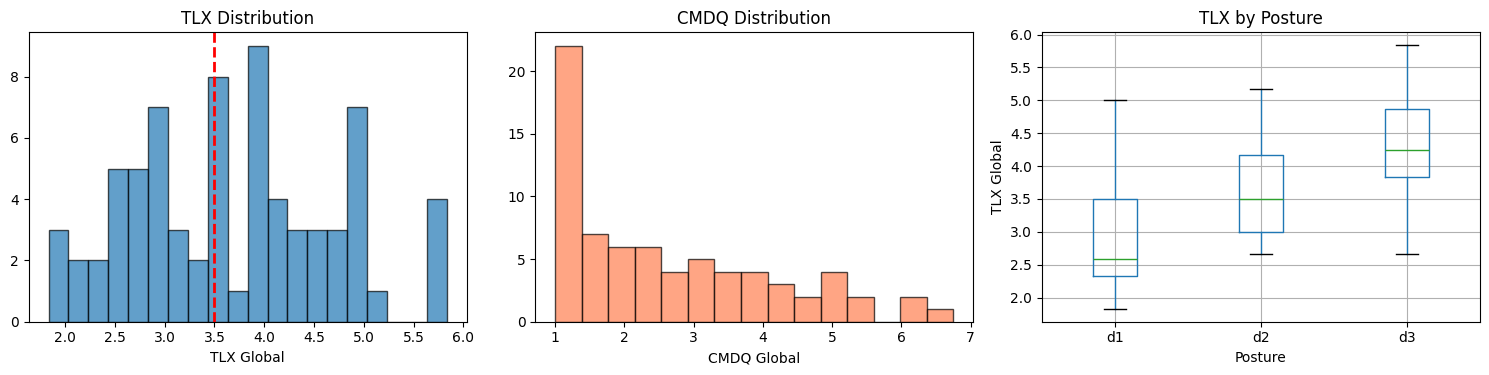


✓ Saved: processed_data.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

FILE_PATH = "~/Desktop/Tech Neck Coding/Final Code_MobileHCI/IRB Task CHI (Responses)).xlsx"

idx_map = {
    'd1': [13, 14, 15, 17, 18, 19, 20, 21, 22, 23],
    'd2': [25, 26, 27, 29, 30, 31, 32, 33, 34, 35],
    'd3': [37, 38, 39, 41, 42, 43, 44, 45, 46, 47]
}

def cronbach_alpha(df_subset):
    n = df_subset.shape[1]
    item_vars = df_subset.var(axis=0, ddof=1).sum()
    total_var = df_subset.sum(axis=1).var(ddof=1)
    return (n / (n - 1)) * (1 - item_vars / total_var)

df_raw = pd.read_excel(FILE_PATH)

data = []
for i, row in df_raw.iterrows():
    participant_name = row['Participant Name'] if 'Participant Name' in df_raw.columns else f"P{i+1:02d}"
    
    for posture in ['d1', 'd2', 'd3']:
        idx = idx_map[posture]
        data.append({
            'Participant': participant_name,
            'Posture': posture,
            'Mental': row.iloc[idx[0]],
            'Physical': row.iloc[idx[1]],
            'Temporal': row.iloc[idx[2]],
            'Success': row.iloc[idx[3]],
            'Effort': row.iloc[idx[4]],
            'Frustration': row.iloc[idx[5]],
            'Neck': row.iloc[idx[6]],
            'Back': row.iloc[idx[7]],
            'Arms': row.iloc[idx[8]],
            'Eyes': row.iloc[idx[9]]
        })

df = pd.DataFrame(data).dropna()

df['Success_Inv'] = 8 - df['Success']
df['TLX_Global'] = df[['Mental', 'Physical', 'Temporal', 'Success_Inv', 'Effort', 'Frustration']].mean(axis=1)
df['CMDQ_Global'] = df[['Neck', 'Back', 'Arms', 'Eyes']].mean(axis=1)

threshold = df['TLX_Global'].median()
df['Label'] = (df['TLX_Global'] >= threshold).astype(int)

alpha_tlx = cronbach_alpha(df[['Mental', 'Physical', 'Temporal', 'Success_Inv', 'Effort', 'Frustration']])
alpha_cmdq = cronbach_alpha(df[['Neck', 'Back', 'Arms', 'Eyes']])

print(f"Trials: {len(df)}")
print(f"TLX α: {alpha_tlx:.3f} | CMDQ α: {alpha_cmdq:.3f}")
print(f"TLX: {df['TLX_Global'].mean():.2f}±{df['TLX_Global'].std():.2f}")
print(f"CMDQ: {df['CMDQ_Global'].mean():.2f}±{df['CMDQ_Global'].std():.2f}")
print(f"Labels (≥{threshold:.2f}): Low={((df['Label']==0).sum())} | High={((df['Label']==1).sum())}")

h, p = stats.kruskal(*[df[df['Posture']==pos]['TLX_Global'].values for pos in ['d1','d2','d3']])
print(f"Posture: H={h:.2f}, p={p:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['TLX_Global'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('TLX Global')
axes[0].set_title('TLX Distribution')

axes[1].hist(df['CMDQ_Global'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('CMDQ Global')
axes[1].set_title('CMDQ Distribution')

df.boxplot(column='TLX_Global', by='Posture', ax=axes[2])
axes[2].set_xlabel('Posture')
axes[2].set_ylabel('TLX Global')
axes[2].set_title('TLX by Posture')
plt.suptitle('')

plt.tight_layout()
plt.show()

df.to_csv('processed_data.csv', index=False)
print(f"\n✓ Saved: processed_data.csv")

<h1> Multimodal classifier </h1>

✅ Merged dataset: 57 trials
   Label distribution: Low=25, High=32

1. EVALUATION: 80-20 RANDOM SPLIT (NESTED) - Random Forest
Best Params Found: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 500}
Accuracy: 0.750, F1: 0.824


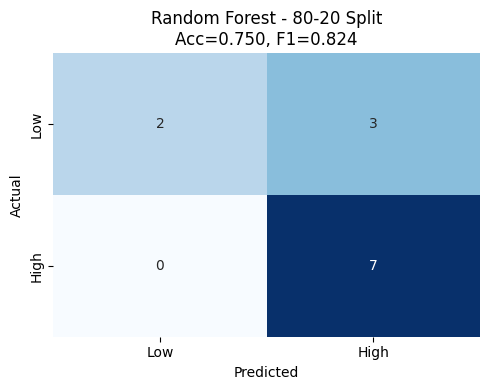


DEPLOYMENT METRICS: 80-20 SPLIT - Random Forest
Model Size:        719.75 KB
Mean Latency:      14.258 ms
95th Percentile:   14.276 ms
Throughput:          70.1 fps
Number of Trees:      500
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   LF-FpZ_tbr_min, OTE_L-FpZ_theta_rel_mean, OTE_L-FpZ_tbr_std, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_tbr_std, RF-FpZ_tbr_min, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_max, pitch_mean_corr

1. EVALUATION: 80-20 RANDOM SPLIT (NESTED) - SVM
Best Params Found: {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}
Accuracy: 0.583, F1: 0.737


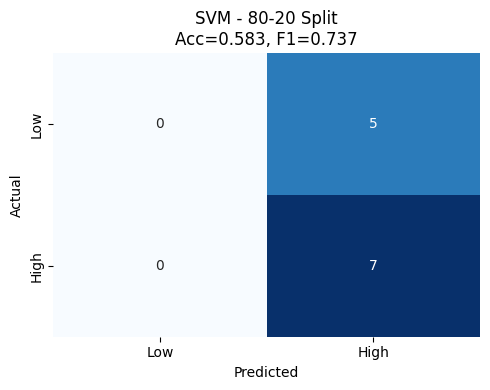


DEPLOYMENT METRICS: 80-20 SPLIT - SVM
Model Size:          5.58 KB
Mean Latency:       0.027 ms
95th Percentile:    0.030 ms
Throughput:       36385.1 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   OTE_L-FpZ_theta_rel_mean, OTE_L-FpZ_tbr_std, OTE_L-FpZ_hjorth_mobility_max, OTE_L-FpZ_skewness_max, OTE_L-FpZ_kurtosis_min, RF-FpZ_tbr_std, RF-FpZ_tbr_min, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_max, pitch_mean_corr

1. EVALUATION: 80-20 RANDOM SPLIT (NESTED) - Gradient Boosting
Best Params Found: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 1.0}
Accuracy: 0.750, F1: 0.824


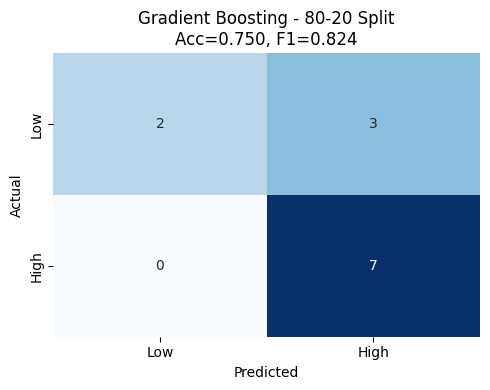


DEPLOYMENT METRICS: 80-20 SPLIT - Gradient Boosting
Model Size:        165.06 KB
Mean Latency:       0.058 ms
95th Percentile:    0.060 ms
Throughput:       17326.1 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   LF-FpZ_tbr_min, OTE_L-FpZ_theta_rel_mean, OTE_L-FpZ_tbr_std, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_tbr_std, RF-FpZ_tbr_min, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_max, pitch_mean_corr

2. EVALUATION: LOSO (NESTED PER FOLD) - Random Forest
Fold 1 (Abhay) Best Depth: 8
Fold 2 (Ankur) Best Depth: 8
Fold 3 (Arghya) Best Depth: 8
Fold 4 (Arindam) Best Depth: 8
Fold 5 (Ario) Best Depth: 8
Fold 6 (Bhawana) Best Depth: 8
Fold 7 (Dip) Best Depth: 8
Fold 8 (Ishita) Best Depth: 8
Fold 9 (Krishna) Best Depth: 8
Fold 10 (Moly) Best Depth: 8
Fold 11 (Orchi) Best Depth: 8
Fold 12 (Postdoc) Best Depth: 8
Fold 13 (Prasun) Best Depth: 8
Fold 14 (Pritam) Best Depth: 8
Fold 15 (Riddho) Best Depth: 8
Fold 16

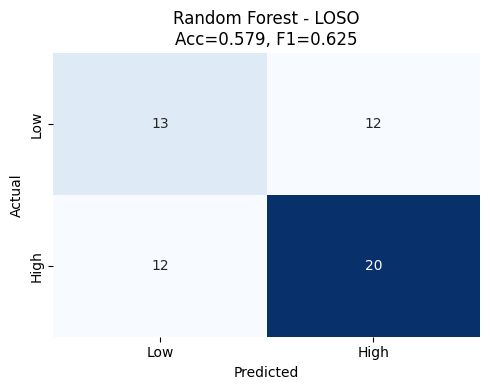


DEPLOYMENT METRICS: LOSO - Random Forest
Model Size:        143.55 KB
Mean Latency:      14.307 ms
95th Percentile:   15.988 ms
Throughput:          69.9 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   OTE_L-FpZ_kurtosis_mean, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_skewness_std, OTE_R-FpZ_tbr_std, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_mean, OTE_R-FpZ_hjorth_complexity_max, coh_OTE_LR_alpha_mean, pitch_mean_corr

2. EVALUATION: LOSO (NESTED PER FOLD) - SVM
Fold 1 (Abhay) Best C: 1.0
Fold 2 (Ankur) Best C: 1.0
Fold 3 (Arghya) Best C: 1.0
Fold 4 (Arindam) Best C: 1.0
Fold 5 (Ario) Best C: 0.1
Fold 6 (Bhawana) Best C: 1.0
Fold 7 (Dip) Best C: 1.0
Fold 8 (Ishita) Best C: 10.0
Fold 9 (Krishna) Best C: 10.0
Fold 10 (Moly) Best C: 1.0
Fold 11 (Orchi) Best C: 1.0
Fold 12 (Postdoc) Best C: 10.0
Fold 13 (Prasun) Best C: 10.0
Fold 14 (Pritam) Best C: 10.0
Fold 15 (Riddho) Best C: 1.0
Fold 16 (Sadia) Best C: 

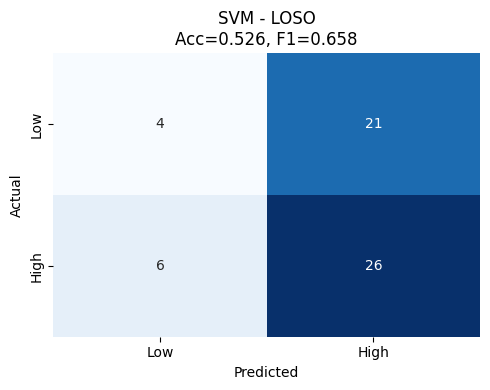


DEPLOYMENT METRICS: LOSO - SVM
Model Size:          5.87 KB
Mean Latency:       0.027 ms
95th Percentile:    0.029 ms
Throughput:       37413.4 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   OTE_L-FpZ_kurtosis_mean, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_skewness_std, RF-FpZ_kurtosis_mean, OTE_R-FpZ_tbr_std, OTE_R-FpZ_hjorth_complexity_mean, OTE_R-FpZ_hjorth_complexity_max, coh_OTE_LR_alpha_mean, pitch_mean_corr

2. EVALUATION: LOSO (NESTED PER FOLD) - Gradient Boosting
Fold 1 (Abhay) Best LR: 0.2
Fold 2 (Ankur) Best LR: 0.01
Fold 3 (Arghya) Best LR: 0.2
Fold 4 (Arindam) Best LR: 0.2
Fold 5 (Ario) Best LR: 0.2
Fold 6 (Bhawana) Best LR: 0.1
Fold 7 (Dip) Best LR: 0.1
Fold 8 (Ishita) Best LR: 0.2
Fold 9 (Krishna) Best LR: 0.2
Fold 10 (Moly) Best LR: 0.2
Fold 11 (Orchi) Best LR: 0.2
Fold 12 (Postdoc) Best LR: 0.2
Fold 13 (Prasun) Best LR: 0.1
Fold 14 (Pritam) Best LR: 0.1
Fold 15 (Riddho) Best LR: 0.2
Fold 16 (Sadia) Be

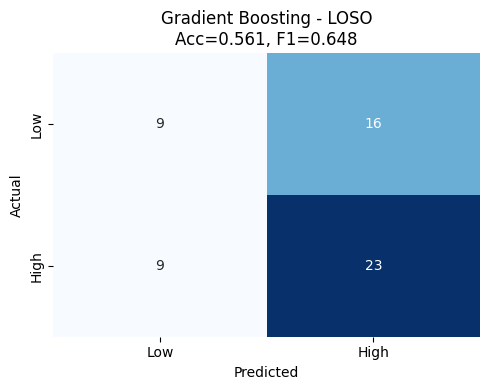


DEPLOYMENT METRICS: LOSO - Gradient Boosting
Model Size:        344.13 KB
Mean Latency:       0.095 ms
95th Percentile:    0.096 ms
Throughput:       10570.8 fps
Number of Trees:      300
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   OTE_L-FpZ_kurtosis_mean, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_skewness_std, OTE_R-FpZ_tbr_std, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_mean, OTE_R-FpZ_hjorth_complexity_max, coh_OTE_LR_alpha_mean, pitch_mean_corr

FINAL SUMMARY TABLE
       Classifier      Method  Accuracy  F1 Score
    Random Forest 80-20 Split  0.750000  0.823529
    Random Forest        LOSO  0.578947  0.625000
              SVM 80-20 Split  0.583333  0.736842
              SVM        LOSO  0.526316  0.658228
Gradient Boosting 80-20 Split  0.750000  0.823529
Gradient Boosting        LOSO  0.561404  0.647887

💾 Saved predictions to 'final_discomfort_predictions.csv'


In [15]:
"""
FINAL DISCOMFORT CLASSIFICATION PIPELINE - MULTI-CLASSIFIER
- Nested CV for hyperparameter tuning (RF, SVM, GB)
- 80-20 random split + LOSO
- Deployment metrics: latency, model size, throughput
- Robust feature set: spectral EEG + baseline-corrected IMU
"""

import pandas as pd
import numpy as np
import pickle
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, LeaveOneGroupOut, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================
CORR_THRESHOLD = 0.9
N_TOP_FEATURES = 10
VARIANCE_THRESHOLD = 0.01
RANDOM_STATE = 42

# Classifier names
CLF_NAMES = {'rf': 'Random Forest', 'svm': 'SVM', 'gb': 'Gradient Boosting'}

# =============================================================================
# LOAD DATA
# =============================================================================
df_labels = pd.read_csv("processed_data.csv")
df_features = pd.read_csv("final_features_refined.csv")

df = pd.merge(df_features, df_labels[["Participant", "Posture", "Label"]], 
              on=["Participant", "Posture"], how="inner")

print(f"✅ Merged dataset: {len(df)} trials")
print(f"   Label distribution: Low={sum(df['Label']==0)}, High={sum(df['Label']==1)}")

# =============================================================================
# PREPROCESSING
# =============================================================================
meta_cols = ["Participant", "Posture", "Label"]
feature_cols = [col for col in df.columns if col not in meta_cols]

X_raw = df[feature_cols]
y = df["Label"].values
groups = df["Participant"].values

# Impute with median
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

# Remove near-zero variance
var_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_var = pd.DataFrame(var_selector.fit_transform(X_imp), 
                     columns=X_imp.columns[var_selector.get_support()])

# Remove high correlation
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
X_clean = X_var.drop(columns=to_drop)

# Adjust feature count
actual_k = min(N_TOP_FEATURES, X_clean.shape[1], len(df) // 3)
if actual_k < N_TOP_FEATURES:
    print(f"⚠️ Using {actual_k} features (limited by data size)")
    N_TOP_FEATURES = actual_k

# =============================================================================
# DEPLOYMENT METRICS
# =============================================================================
def measure_latency(clf, X_sample, n_runs=100):
    """Measure inference latency."""
    for _ in range(10): _ = clf.predict(X_sample)  # warmup
    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return np.mean(latencies), np.percentile(latencies, 95)

def get_deployment_metrics(clf, X_test, top_features):
    """Calculate deployment metrics."""
    model_size_kb = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput = 1000 / mean_lat
    n_trees = clf.n_estimators if hasattr(clf, 'n_estimators') else 'N/A'
    rt_status = "✓ EXCELLENT" if mean_lat < 50 else "✓ GOOD" if mean_lat < 100 else "⚠ ACCEPTABLE" if mean_lat < 200 else "✗ SLOW"
    return {
        'model_size_kb': model_size_kb,
        'mean_latency_ms': mean_lat,
        'p95_latency_ms': p95_lat,
        'throughput_fps': throughput,
        'n_features': len(top_features),
        'n_trees': n_trees,
        'features': top_features,
        'rt_status': rt_status
    }

def print_deployment_metrics(metrics, title):
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Model Size:      {metrics['model_size_kb']:>8.2f} KB")
    print(f"Mean Latency:    {metrics['mean_latency_ms']:>8.3f} ms")
    print(f"95th Percentile: {metrics['p95_latency_ms']:>8.3f} ms")
    print(f"Throughput:      {metrics['throughput_fps']:>8.1f} fps")
    print(f"Number of Trees: {metrics['n_trees']:>8}")
    print(f"Features Used:   {metrics['n_features']:>8}")
    print(f"RT Status:       {metrics['rt_status']}")
    print(f"Feature Names:   {', '.join(metrics['features'])}")

# =============================================================================
# HELPER: PLOT CONFUSION MATRIX
# =============================================================================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"])
    plt.title(f"{title}\nAcc={accuracy_score(y_true, y_pred):.3f}, F1={f1_score(y_true, y_pred):.3f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# =============================================================================
# NESTED CV FOR HYPERPARAMETER TUNING
# =============================================================================
def tune_rf_nested(X_train, y_train, random_state=RANDOM_STATE):
    """Tune RF using nested CV."""
    param_grid = {
        'n_estimators': [100, 500],
        'max_depth': [8, 12, None],
        'min_samples_leaf': [2, 3],
        'min_samples_split': [4, 6],
        'max_features': ['sqrt']
    }
    
    rf = RandomForestClassifier(
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1
    )
    
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    grid = GridSearchCV(rf, param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

def tune_svm_nested(X_train, y_train, random_state=RANDOM_STATE):
    """Tune SVM using nested CV."""
    param_grid = {
        'C': [0.1, 1.0, 10.0],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'kernel': ['rbf']
    }
    
    svm = SVC(
        class_weight="balanced",
        random_state=random_state
    )
    
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    grid = GridSearchCV(svm, param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

def tune_gb_nested(X_train, y_train, random_state=RANDOM_STATE):
    """Tune GB using nested CV with balanced sample weights."""
    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [2, 3],
        'subsample': [0.8, 1.0]
    }
    
    gb = GradientBoostingClassifier(random_state=random_state)
    
    # Compute sample weights for balancing
    sample_weights = compute_sample_weight('balanced', y_train)
    
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    grid = GridSearchCV(gb, param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train, sample_weight=sample_weights)
    return grid.best_estimator_, grid.best_params_

# =============================================================================
# 1. 80-20 RANDOM SPLIT
# =============================================================================

classifiers = ['rf', 'svm', 'gb']
all_results_8020 = {}

for clf_type in classifiers:
    print("\n" + "="*60)
    print(f"1. EVALUATION: 80-20 RANDOM SPLIT (NESTED) - {CLF_NAMES[clf_type]}")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    # Feature selection
    selector = SelectKBest(mutual_info_classif, k=N_TOP_FEATURES)
    X_tr_sel = selector.fit_transform(X_train, y_train)
    X_te_sel = selector.transform(X_test)

    # Scale
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_sel)
    X_te_scaled = scaler.transform(X_te_sel)

    # Tune and train
    if clf_type == 'rf':
        clf_8020, best_params = tune_rf_nested(X_tr_scaled, y_train)
    elif clf_type == 'svm':
        clf_8020, best_params = tune_svm_nested(X_tr_scaled, y_train)
    elif clf_type == 'gb':
        clf_8020, best_params = tune_gb_nested(X_tr_scaled, y_train)
    
    print(f"Best Params Found: {best_params}")
    y_pred_8020 = clf_8020.predict(X_te_scaled)

    acc_8020 = accuracy_score(y_test, y_pred_8020)
    f1_8020 = f1_score(y_test, y_pred_8020)
    print(f"Accuracy: {acc_8020:.3f}, F1: {f1_8020:.3f}")

    plot_cm(y_test, y_pred_8020, f"{CLF_NAMES[clf_type]} - 80-20 Split")

    # Deployment metrics
    selected_features = X_train.columns[selector.get_support()]
    metrics_8020 = get_deployment_metrics(clf_8020, X_te_scaled, selected_features)
    print_deployment_metrics(metrics_8020, f"DEPLOYMENT METRICS: 80-20 SPLIT - {CLF_NAMES[clf_type]}")
    
    all_results_8020[clf_type] = {
        'acc': acc_8020,
        'f1': f1_8020,
        'metrics': metrics_8020
    }

# =============================================================================
# 2. LEAVE-ONE-SUBJECT-OUT (LOSO)
# =============================================================================

all_results_loso = {}

for clf_type in classifiers:
    print("\n" + "="*60)
    print(f"2. EVALUATION: LOSO (NESTED PER FOLD) - {CLF_NAMES[clf_type]}")
    print("="*60)

    logo = LeaveOneGroupOut()
    y_true_loso, y_pred_loso = [], []
    last_clf, last_X_test = None, None

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_clean, y, groups), start=1):
        X_tr, X_te = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # Feature selection
        selector_fold = SelectKBest(mutual_info_classif, k=N_TOP_FEATURES)
        X_tr_sel = selector_fold.fit_transform(X_tr, y_tr)
        X_te_sel = selector_fold.transform(X_te)
        
        # Scale
        scaler_fold = StandardScaler()
        X_tr_scaled = scaler_fold.fit_transform(X_tr_sel)
        X_te_scaled = scaler_fold.transform(X_te_sel)
        
        # Tune and train
        if clf_type == 'rf':
            clf_fold, best_params_fold = tune_rf_nested(X_tr_scaled, y_tr)
        elif clf_type == 'svm':
            clf_fold, best_params_fold = tune_svm_nested(X_tr_scaled, y_tr)
        elif clf_type == 'gb':
            clf_fold, best_params_fold = tune_gb_nested(X_tr_scaled, y_tr)
        
        y_pred = clf_fold.predict(X_te_scaled)
        
        y_pred_loso.extend(y_pred)
        y_true_loso.extend(y_te)
        last_clf, last_X_test = clf_fold, X_te_scaled
        
        if clf_type == 'rf':
            best_depth = best_params_fold.get('max_depth', 'None')
            print(f"Fold {fold} ({groups[test_idx][0]}) Best Depth: {best_depth}")
        elif clf_type == 'svm':
            best_C = best_params_fold.get('C', 'N/A')
            print(f"Fold {fold} ({groups[test_idx][0]}) Best C: {best_C}")
        elif clf_type == 'gb':
            best_lr = best_params_fold.get('learning_rate', 'N/A')
            print(f"Fold {fold} ({groups[test_idx][0]}) Best LR: {best_lr}")

    y_true_loso = np.array(y_true_loso)
    y_pred_loso = np.array(y_pred_loso)

    acc_loso = accuracy_score(y_true_loso, y_pred_loso)
    f1_loso = f1_score(y_true_loso, y_pred_loso)
    print(f"\nFINAL LOSO RESULTS -> Accuracy: {acc_loso:.3f}, F1: {f1_loso:.3f}")

    plot_cm(y_true_loso, y_pred_loso, f"{CLF_NAMES[clf_type]} - LOSO")

    # Deployment metrics (last fold)
    if last_clf is not None:
        loso_features = X_clean.columns[selector_fold.get_support()]
        metrics_loso = get_deployment_metrics(last_clf, last_X_test, loso_features)
        print_deployment_metrics(metrics_loso, f"DEPLOYMENT METRICS: LOSO - {CLF_NAMES[clf_type]}")
    
    all_results_loso[clf_type] = {
        'acc': acc_loso,
        'f1': f1_loso,
        'metrics': metrics_loso,
        'y_true': y_true_loso,
        'y_pred': y_pred_loso
    }

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("FINAL SUMMARY TABLE")
print("="*60)

summary_data = []
for clf_type in classifiers:
    summary_data.append({
        'Classifier': CLF_NAMES[clf_type],
        'Method': '80-20 Split',
        'Accuracy': all_results_8020[clf_type]['acc'],
        'F1 Score': all_results_8020[clf_type]['f1']
    })
    summary_data.append({
        'Classifier': CLF_NAMES[clf_type],
        'Method': 'LOSO',
        'Accuracy': all_results_loso[clf_type]['acc'],
        'F1 Score': all_results_loso[clf_type]['f1']
    })

summary = pd.DataFrame(summary_data)
print(summary.to_string(index=False))

# Save predictions (using RF LOSO as default)
results_df = pd.DataFrame({
    'Participant': groups,
    'True_Label': all_results_loso['rf']['y_true'],
    'Predicted_Label': all_results_loso['rf']['y_pred'],
    'Correct': all_results_loso['rf']['y_true'] == all_results_loso['rf']['y_pred']
})
results_df.to_csv('final_discomfort_predictions.csv', index=False)
print("\n💾 Saved predictions to 'final_discomfort_predictions.csv'")

In [16]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance

# -----------------------------------------------------------------------------
# DEFINITIONS (explicit to avoid NameError)
# -----------------------------------------------------------------------------
CLF_NAMES = {
    "rf": "Random Forest",
    "svm": "SVM",
    "gb": "Gradient Boosting"
}

classifiers = ["rf", "svm", "gb"]

TOPK_PRINT = 10
N_PERM = 20
PERM_SCORING = "f1"
RANDOM_STATE = 42

# =============================================================================
# INTERNAL HELPERS
# =============================================================================

def _get_importances(model, X_test_scaled, y_test, feat_names, clf_type):
    """
    RF / GB: native feature_importances_
    SVM (RBF): permutation importance
    """
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_

    # SVM fallback
    pi = permutation_importance(
        model,
        X_test_scaled,
        y_test,
        scoring=PERM_SCORING,
        n_repeats=N_PERM,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    return pi.importances_mean


def _topk_series(importances, feature_names, k):
    s = pd.Series(importances, index=feature_names)
    return s.sort_values(ascending=False).head(k)


def _print_block(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def _print_features(model_key, series, note=None):
    header = f"{CLF_NAMES[model_key]}"
    if note is not None:
        header += f" ({note})"
    print(f"\n{header}")
    for f, v in series.items():
        print(f"  {f:<40s} {v:.4f}")

# =============================================================================
# 1) 80-20 RANDOM SPLIT
# =============================================================================

def report_top_features_8020(X_clean, y):
    _print_block("TOP FEATURES | 80/20 RANDOM SPLIT")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_clean, y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE
    )

    results = {}

    for clf_type in classifiers:
        selector = SelectKBest(mutual_info_classif, k=N_TOP_FEATURES)
        X_tr_sel = selector.fit_transform(X_tr, y_tr)
        X_te_sel = selector.transform(X_te)

        feat_names = X_tr.columns[selector.get_support()]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_sel)
        X_te_sc = scaler.transform(X_te_sel)

        if clf_type == "rf":
            model, _ = tune_rf_nested(X_tr_sc, y_tr)
        elif clf_type == "svm":
            model, _ = tune_svm_nested(X_tr_sc, y_tr)
        elif clf_type == "gb":
            model, _ = tune_gb_nested(X_tr_sc, y_tr)

        model.fit(X_tr_sc, y_tr)

        imp = _get_importances(model, X_te_sc, y_te, feat_names, clf_type)
        topk = _topk_series(imp, feat_names, TOPK_PRINT)

        note = "permutation" if clf_type == "svm" else None
        _print_features(clf_type, topk, note)

        results[clf_type] = topk

    return results

# =============================================================================
# 2) LOSO (AVERAGED ACROSS SUBJECTS)
# =============================================================================

def report_top_features_loso(X_clean, y, groups):
    _print_block("TOP FEATURES | LOSO (AVERAGED ACROSS SUBJECTS)")

    logo = LeaveOneGroupOut()
    results = {}

    for clf_type in classifiers:
        agg_imp = {}
        agg_cnt = {}

        for train_idx, test_idx in logo.split(X_clean, y, groups):
            X_tr, X_te = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            selector = SelectKBest(mutual_info_classif, k=N_TOP_FEATURES)
            X_tr_sel = selector.fit_transform(X_tr, y_tr)
            X_te_sel = selector.transform(X_te)

            feat_names = X_tr.columns[selector.get_support()]

            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr_sel)
            X_te_sc = scaler.transform(X_te_sel)

            if clf_type == "rf":
                model, _ = tune_rf_nested(X_tr_sc, y_tr)
            elif clf_type == "svm":
                model, _ = tune_svm_nested(X_tr_sc, y_tr)
            elif clf_type == "gb":
                model, _ = tune_gb_nested(X_tr_sc, y_tr)

            model.fit(X_tr_sc, y_tr)

            imp = _get_importances(model, X_te_sc, y_te, feat_names, clf_type)

            for f, v in zip(feat_names, imp):
                agg_imp[f] = agg_imp.get(f, 0.0) + v
                agg_cnt[f] = agg_cnt.get(f, 0) + 1

        avg_imp = {f: agg_imp[f] / agg_cnt[f] for f in agg_imp}
        topk = pd.Series(avg_imp).sort_values(ascending=False).head(TOPK_PRINT)

        note = "permutation" if clf_type == "svm" else None
        _print_features(clf_type, topk, note)

        results[clf_type] = topk

    return results


topfeat_8020 = report_top_features_8020(X_clean, y)
topfeat_loso = report_top_features_loso(X_clean, y, groups)



TOP FEATURES | 80/20 RANDOM SPLIT

Random Forest
  OTE_L-FpZ_theta_rel_mean                 0.1740
  RF-FpZ_tbr_min                           0.1386
  OTE_L-FpZ_kurtosis_min                   0.1376
  OTE_R-FpZ_hjorth_complexity_max          0.1047
  RF-FpZ_tbr_std                           0.0839
  OTE_R-FpZ_hjorth_mobility_max            0.0808
  RF-FpZ_theta_rel_mean                    0.0739
  LF-FpZ_tbr_min                           0.0698
  OTE_L-FpZ_hjorth_mobility_max            0.0687
  OTE_L-FpZ_tbr_std                        0.0679

SVM (permutation)
  OTE_L-FpZ_theta_rel_mean                 0.0124
  OTE_R-FpZ_hjorth_mobility_max            0.0051
  OTE_R-FpZ_hjorth_complexity_max          0.0051
  pitch_mean_corr                          0.0030
  RF-FpZ_tbr_min                           0.0000
  OTE_L-FpZ_skewness_max                   -0.0053
  RF-FpZ_tbr_std                           -0.0061
  OTE_L-FpZ_tbr_std                        -0.0095
  LF-FpZ_tbr_min            

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packa


SVM (permutation)
  OTE_R-FpZ_theta_rel_mean                 0.0583
  RF-FpZ_skewness_std                      0.0238
  OTE_L-FpZ_theta_rel_mean                 0.0181
  OTE_L-FpZ_kurtosis_mean                  0.0127
  RF-FpZ_kurtosis_mean                     0.0125
  OTE_L-FpZ_kurtosis_min                   0.0104
  coh_OTE_LR_alpha_mean                    0.0100
  OTE_R-FpZ_hjorth_complexity_mean         0.0089
  OTE_R-FpZ_abr_min                        0.0075
  LF-FpZ_hjorth_complexity_std             0.0000

Gradient Boosting
  pitch_mean_corr                          0.2991
  OTE_L-FpZ_theta_rel_mean                 0.2501
  LF-FpZ_skewness_max                      0.1704
  RF-FpZ_skewness_std                      0.1629
  OTE_L-FpZ_abr_min                        0.1591
  OTE_L-FpZ_skewness_max                   0.1386
  OTE_L-FpZ_kurtosis_mean                  0.1143
  OTE_R-FpZ_hjorth_complexity_max          0.1054
  LF-FpZ_theta_mean                        0.1050
  OTE_L-FpZ_

<h1>Linear Kernal SVM MULTIMODAL </h1>

In [12]:
import pandas as pd
import numpy as np
import pickle
import time
import warnings
from collections import Counter
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, LeaveOneGroupOut,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, VarianceThreshold
)

warnings.filterwarnings("ignore")

# ================= CONFIG =================
CORR_THRESHOLD     = 0.9
N_TOP_FEATURES     = 10
VARIANCE_THRESHOLD = 0.01
RANDOM_STATE       = 42

# ================= LOAD DATA =================
print("="*70)
print("LOADING DATA")
print("="*70)

df_labels   = pd.read_csv("processed_data.csv")
df_features = pd.read_csv("final_features_refined.csv")

df = pd.merge(
    df_features,
    df_labels[["Participant", "Posture", "Label"]],
    on=["Participant", "Posture"],
    how="inner"
)

print(f"Merged dataset : {len(df)} trials")
print(f"Label dist     : Low={sum(df['Label']==0)}  "
      f"High={sum(df['Label']==1)}")

# ================= PREPROCESSING =================
meta_cols    = ["Participant", "Posture", "Label"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X_raw  = df[feature_cols]
y      = df["Label"].values
groups = df["Participant"].values

imputer = SimpleImputer(strategy="median")
X_imp   = pd.DataFrame(
    imputer.fit_transform(X_raw), columns=feature_cols
)

var_sel = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_var   = pd.DataFrame(
    var_sel.fit_transform(X_imp),
    columns=X_imp.columns[var_sel.get_support()]
)

corr_matrix = X_var.corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [
    col for col in upper.columns
    if any(upper[col] > CORR_THRESHOLD)
]
X_clean = X_var.drop(columns=to_drop)

actual_k = min(N_TOP_FEATURES, X_clean.shape[1], len(df) // 3)
if actual_k < N_TOP_FEATURES:
    print(f"Using {actual_k} features (limited by data size)")
    N_TOP_FEATURES = actual_k

print(f"Features after preprocessing : {X_clean.shape[1]}")
print(f"Top-K selected               : {N_TOP_FEATURES}")

# ================= HELPERS =================

def get_linear_svm_importance(model):
    """
    Normalized absolute linear SVM coefficients.
    For binary: coef_ shape (1, n_features)
    Normalize to [0, 1] for readability.
    """
    coef = np.abs(model.coef_).ravel()
    if np.max(coef) > 0:
        coef = coef / np.max(coef)
    return coef


def print_per_class_metrics(all_true, all_pred, title, split):
    print(f"\n{'='*70}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*70}")
    print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*52}")

    prec    = precision_score(all_true, all_pred, average=None,
                              zero_division=0)
    rec     = recall_score(all_true, all_pred, average=None,
                           zero_division=0)
    f1      = f1_score(all_true, all_pred, average=None,
                       zero_division=0)
    support = Counter(all_true)

    for i, lab in enumerate(sorted(set(all_true))):
        lname = "Low" if lab == 0 else "High"
        print(f"  {lname:<10} {prec[i]:>10.3f} {rec[i]:>10.3f} "
              f"{f1[i]:>10.3f} {support[lab]:>10d}")

    print(f"  {'-'*52}")
    macro_p = precision_score(all_true, all_pred, average="macro",
                              zero_division=0)
    macro_r = recall_score(all_true, all_pred, average="macro",
                           zero_division=0)
    macro_f = f1_score(all_true, all_pred, average="macro",
                       zero_division=0)
    acc     = accuracy_score(all_true, all_pred)
    print(f"  {'Macro Avg':<10} {macro_p:>10.3f} {macro_r:>10.3f} "
          f"{macro_f:>10.3f}")
    print(f"  {'Accuracy':<10} {'':>10} {'':>10} {acc:>10.3f}")


def print_all_importance(importances, feat_names, title, split):
    if importances is None:
        return
    print(f"\n{'='*70}")
    print(f"NORMALIZED ABS COEFFICIENTS – {title} – {split}")
    print(f"{'='*70}")
    s = pd.Series(importances,
                  index=feat_names).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<55s} {v:.6f}")


def print_top5_importance(importances, feat_names, title, split):
    if importances is None:
        return
    s = pd.Series(importances,
                  index=feat_names).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<55s} {v:.6f}")


def measure_latency(clf, X_sample, n_runs=100):
    for _ in range(10):
        clf.predict(X_sample)
    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return float(np.mean(latencies)), \
           float(np.percentile(latencies, 95))


def print_deployment_metrics(clf, X_test, feat_names,
                              title, split):
    model_size_kb     = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput        = 1000 / mean_lat
    rt_status = (
        "EXCELLENT"  if mean_lat < 50  else
        "GOOD"       if mean_lat < 100 else
        "ACCEPTABLE" if mean_lat < 200 else
        "SLOW"
    )
    print(f"\n{'='*70}")
    print(f"DEPLOYMENT METRICS – {title} – {split}")
    print(f"{'='*70}")
    print(f"  Model Size    : {model_size_kb:.2f} KB")
    print(f"  Mean Latency  : {mean_lat:.3f} ms")
    print(f"  P95 Latency   : {p95_lat:.3f} ms")
    print(f"  Throughput    : {throughput:.1f} fps")
    print(f"  Features Used : {len(feat_names)}")
    print(f"  RT Status     : {rt_status}")
    print(f"  Top Features  : {', '.join(list(feat_names)[:5])}")


# ================= HYPERPARAMETER TUNING =================

def tune_linear_svm(X_train, y_train,
                    random_state=RANDOM_STATE):
    param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}
    svm = SVC(
        kernel="linear",
        class_weight="balanced",
        random_state=random_state
    )
    inner_cv = StratifiedKFold(
        n_splits=3, shuffle=True,
        random_state=random_state
    )
    grid = GridSearchCV(
        svm, param_grid,
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_


# ================= 80/20 LINEAR SVM =================

def linear_svm_multimodal_8020(X_clean, y,
                                title="Multimodal Discomfort"):
    print(f"\n{'='*70}")
    print(f"LINEAR SVM – {title} – 80/20 (Nested CV Tuning)")
    print(f"{'='*70}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE
    )

    selector    = SelectKBest(mutual_info_classif, k=N_TOP_FEATURES)
    X_tr_sel    = selector.fit_transform(X_train, y_train)
    X_te_sel    = selector.transform(X_test)

    scaler      = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_sel)
    X_te_scaled = scaler.transform(X_te_sel)

    clf, best_params = tune_linear_svm(X_tr_scaled, y_train)
    print(f"\nBest C found : {best_params}")

    y_pred = clf.predict(X_te_scaled)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro",
                        zero_division=0)

    feat_names = list(X_clean.columns[selector.get_support()])

    print(f"\nSelected features : {', '.join(feat_names)}")
    print(f"\nAccuracy  : {acc:.3f}")
    print(f"Macro F1  : {macro_f1:.3f}")

    print_per_class_metrics(
        list(y_test), list(y_pred), title, "80/20"
    )

    # use normalized absolute coefficients instead of
    # permutation importance — stable for small test sets
    coef_imp = get_linear_svm_importance(clf)
    print_all_importance(coef_imp, feat_names, title, "80/20")
    print_top5_importance(coef_imp, feat_names, title, "80/20")

    print_deployment_metrics(
        clf, X_te_scaled, feat_names, title, "80/20"
    )

    return acc, macro_f1, coef_imp, feat_names, clf


# ================= LOSO LINEAR SVM =================

def linear_svm_multimodal_loso(X_clean, y, groups,
                                title="Multimodal Discomfort"):
    print(f"\n{'='*70}")
    print(f"LINEAR SVM – {title} – LOSO (Nested CV per fold)")
    print(f"{'='*70}")

    logo = LeaveOneGroupOut()

    all_true, all_pred = [], []
    fold_importances   = []
    feat_freq          = {}
    last_clf           = None
    last_X_te_scaled   = None
    last_feat_names    = None

    for fold, (train_idx, test_idx) in enumerate(
        logo.split(X_clean, y, groups), start=1
    ):
        X_tr = X_clean.iloc[train_idx]
        X_te = X_clean.iloc[test_idx]
        y_tr = y[train_idx]
        y_te = y[test_idx]

        selector_fold = SelectKBest(
            mutual_info_classif, k=N_TOP_FEATURES
        )
        X_tr_sel = selector_fold.fit_transform(X_tr, y_tr)
        X_te_sel = selector_fold.transform(X_te)

        scaler_fold = StandardScaler()
        X_tr_scaled = scaler_fold.fit_transform(X_tr_sel)
        X_te_scaled = scaler_fold.transform(X_te_sel)

        clf_fold, best_params_fold = tune_linear_svm(
            X_tr_scaled, y_tr
        )

        y_hat = clf_fold.predict(X_te_scaled)
        all_true.extend(y_te.tolist())
        all_pred.extend(y_hat.tolist())

        feat_names_fold = list(
            X_clean.columns[selector_fold.get_support()]
        )

        # use normalized absolute coefficients per fold
        coef_imp = get_linear_svm_importance(clf_fold)
        fold_importances.append(coef_imp)

        for n in feat_names_fold:
            feat_freq[n] = feat_freq.get(n, 0) + 1

        last_clf         = clf_fold
        last_X_te_scaled = X_te_scaled
        last_feat_names  = feat_names_fold

        print(f"  Fold {fold:2d} "
              f"({groups[test_idx][0]:15s}) "
              f"Best C: {best_params_fold.get('C','N/A')}")

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, []

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro",
                        zero_division=0)

    print(f"\nAccuracy  : {acc:.3f}")
    print(f"Macro F1  : {macro_f1:.3f}")

    print_per_class_metrics(
        list(all_true), list(all_pred), title, "LOSO"
    )

    # average normalized coefficients across folds
    avg_imp = (
        np.mean(np.vstack(fold_importances), axis=0)
        if fold_importances else None
    )

    freq_items       = sorted(feat_freq.items(),
                              key=lambda x: (-x[1], x[0]))
    top_global_names = [n for n, _ in freq_items[:N_TOP_FEATURES]]

    print_all_importance(avg_imp, last_feat_names, title, "LOSO")
    print_top5_importance(avg_imp, last_feat_names, title, "LOSO")

    if last_clf is not None and last_X_te_scaled is not None:
        print_deployment_metrics(
            last_clf, last_X_te_scaled,
            top_global_names, title, "LOSO"
        )

    return acc, macro_f1, avg_imp, top_global_names


# ================= SAVE CSV =================

def save_importance_csv(imp_8020, imp_loso,
                        feat_cols_8020, feat_cols_loso,
                        filename):
    n = max(len(feat_cols_8020), len(feat_cols_loso))

    def pad(lst, length):
        return list(lst) + [np.nan] * (length - len(lst))

    df_out = pd.DataFrame({
        "feature_8020":
            pad(feat_cols_8020, n),
        "norm_abs_coef_8020":
            pad(imp_8020 if imp_8020 is not None else [], n),
        "feature_loso":
            pad(feat_cols_loso, n),
        "norm_abs_coef_loso":
            pad(imp_loso if imp_loso is not None else [], n),
    })
    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")


# ================= RUN =================

print("\n" + "="*70)
print("LINEAR SVM — MULTIMODAL DISCOMFORT CLASSIFICATION")
print("Feature importance: normalized absolute coefficients")
print("="*70)

acc_8020, f1_8020, imp_8020, cols_8020, clf_8020 = \
    linear_svm_multimodal_8020(
        X_clean, y,
        title="Multimodal Discomfort"
    )

acc_loso, f1_loso, imp_loso, cols_loso = \
    linear_svm_multimodal_loso(
        X_clean, y, groups,
        title="Multimodal Discomfort"
    )

save_importance_csv(
    imp_8020, imp_loso,
    cols_8020, cols_loso,
    "linear_svm_multimodal_discomfort_importance.csv"
)

# ================= SUMMARY =================
print("\n" + "="*70)
print("SUMMARY FOR PAPER")
print("="*70)
print(f"Multimodal Linear SVM  |  80/20 Acc: {acc_8020:.3f}  "
      f"Macro F1: {f1_8020:.3f}")
print(f"Multimodal Linear SVM  |  LOSO  Acc: {acc_loso:.3f}  "
      f"Macro F1: {f1_loso:.3f}")
print("\nFeature importance: normalized absolute SVM coefficients.")
print("80/20: coefficients from single split model.")
print("LOSO : averaged normalized coefficients across all folds.")

LOADING DATA
Merged dataset : 57 trials
Label dist     : Low=25  High=32
Features after preprocessing : 101
Top-K selected               : 10

LINEAR SVM — MULTIMODAL DISCOMFORT CLASSIFICATION
Feature importance: normalized absolute coefficients

LINEAR SVM – Multimodal Discomfort – 80/20 (Nested CV Tuning)

Best C found : {'C': 1.0}

Selected features : OTE_L-FpZ_theta_rel_mean, OTE_L-FpZ_tbr_std, OTE_L-FpZ_hjorth_mobility_max, OTE_L-FpZ_kurtosis_min, RF-FpZ_theta_rel_mean, RF-FpZ_tbr_std, RF-FpZ_tbr_min, OTE_R-FpZ_hjorth_mobility_max, OTE_R-FpZ_hjorth_complexity_max, pitch_mean_corr

Accuracy  : 0.667
Macro F1  : 0.657

PER-CLASS METRICS – Multimodal Discomfort – 80/20
  Class       Precision     Recall         F1    Support
  ----------------------------------------------------
  Low             0.600      0.600      0.600          5
  High            0.714      0.714      0.714          7
  ----------------------------------------------------
  Macro Avg       0.657      0.657     

<h1>Unimodal Discomfort analysis </h1>


Computing IMU baseline corrections (d1=baseline, d3=polarity)...
Postdoc         | P_base =   -3.41° | Polarity: NEGATIVE (-1)
Monon           | P_base =   +8.95° | Polarity: NEGATIVE (-1)
Manzz           | P_base =   +9.12° | Polarity: NEGATIVE (-1)
Ario            | P_base =   +6.80° | Polarity: NEGATIVE (-1)
Walid           | P_base =  +16.20° | Polarity: NEGATIVE (-1)
Riddho          | P_base =  +21.77° | Polarity: NEGATIVE (-1)
Prasun          | P_base =   -5.79° | Polarity: NEGATIVE (-1)
Pritam          | P_base =   -7.11° | Polarity: NEGATIVE (-1)
Orchi           | P_base =   -6.94° | Polarity: NEGATIVE (-1)
Saekh           | No d1 data found → baseline correction DISABLED
Ishita          | P_base =  +60.37° | Polarity: NEGATIVE (-1)
koushik         | P_base =  -66.11° | Polarity: NEGATIVE (-1)
Aziz            | P_base =  -62.25° | Polarity: POSITIVE (+1)
Abhay           | P_base =  +51.45° | Polarity: NEGATIVE (-1)
Krishna         | P_base =  +65.21° | Polarity: NEGATIVE (-1)


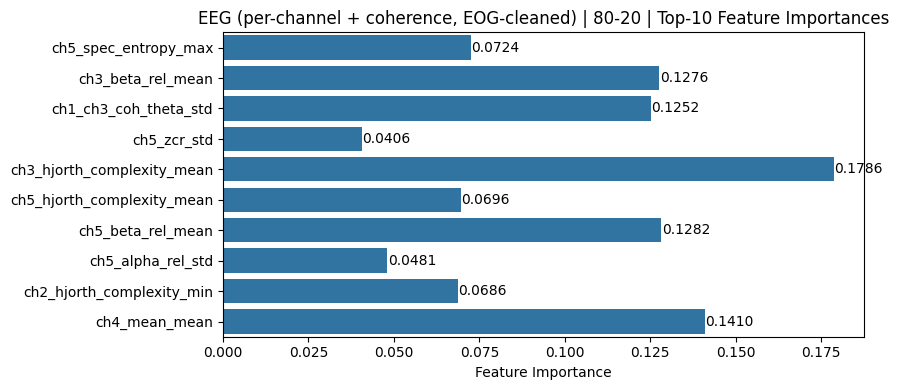

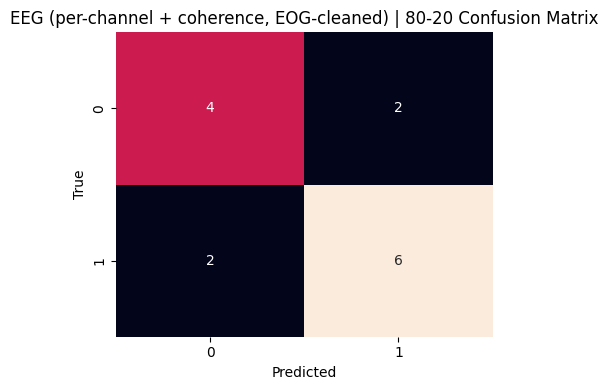


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - 80/20 Split
Model Size:         66.45 KB
Mean Latency:      14.264 ms
95th Percentile:   15.551 ms
Throughput:          70.1 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_hjorth_complexity_min, ch4_mean_mean

EEG (per-channel + coherence, EOG-cleaned) | Random Forest | LOSO | Top-10 Features per fold
Accuracy=0.638  Precision=0.750  Recall=0.585  F1=0.658
              precision    recall  f1-score   support

           0      0.541     0.714     0.615        28
           1      0.750     0.585     0.658        41

    accuracy                          0.638        69
   macro avg      0.645     0.650     0.636        69
weighted avg      0.665     0.638     0.640        69



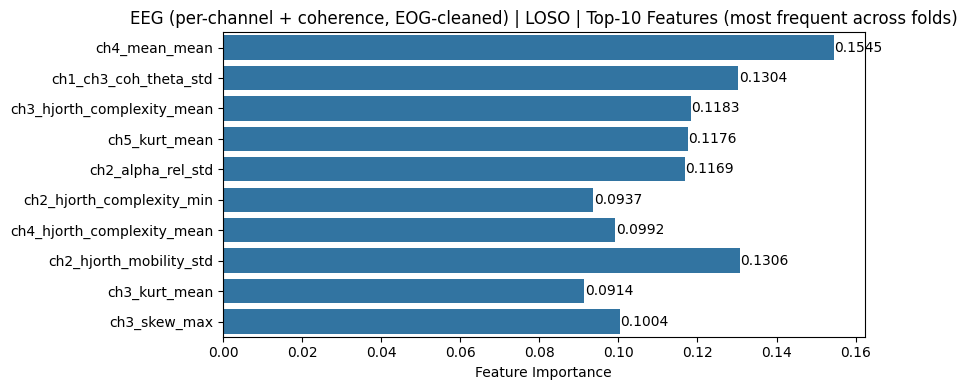

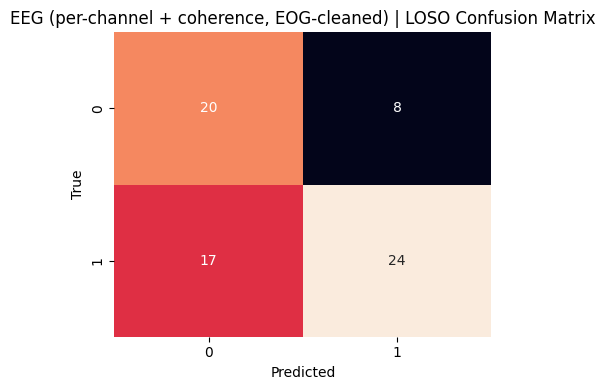


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - LOSO
Model Size:        516.03 KB
Mean Latency:      13.044 ms
95th Percentile:   13.791 ms
Throughput:          76.7 fps
Number of Trees:      500
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch4_mean_mean, ch1_ch3_coh_theta_std, ch3_hjorth_complexity_mean, ch5_kurt_mean, ch2_alpha_rel_std, ch2_hjorth_complexity_min, ch4_hjorth_complexity_mean, ch2_hjorth_mobility_std, ch3_kurt_mean, ch3_skew_max

IMU: 69 trials | 27 features (with baseline correction)

IMU (Enhanced Pitch Features) | Random Forest | 80-20 Split | Top-10 Features
Top-10 features used: pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean
Accuracy=0.786  Precision=0.857  Recall=0.750  F1=0.800
              precision    recall  f1-score   support

           0      0.714     0.833     0.769         6
           1      0.8

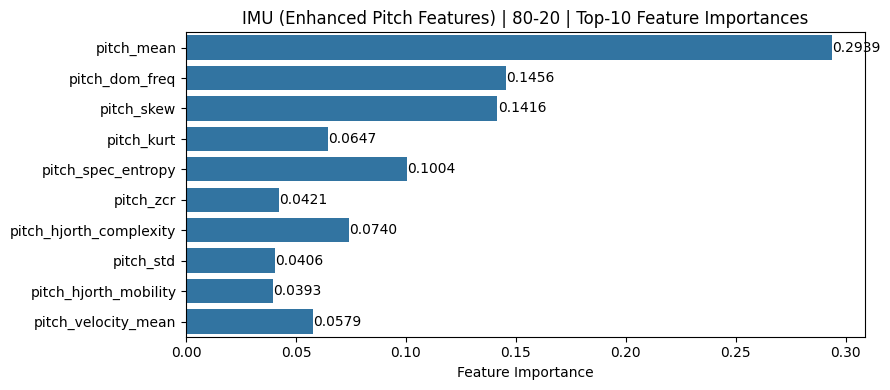

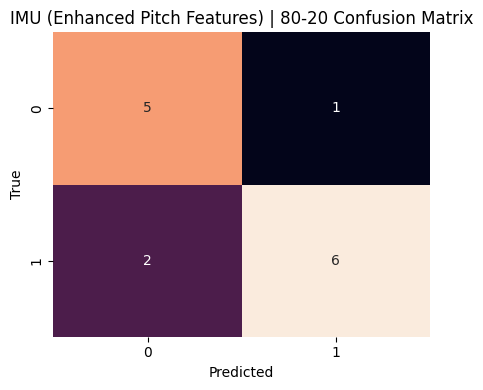


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - 80/20 Split
Model Size:         67.08 KB
Mean Latency:      15.487 ms
95th Percentile:   15.357 ms
Throughput:          64.6 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean

IMU (Enhanced Pitch Features) | Random Forest | LOSO | Top-10 Features per fold
Accuracy=0.652  Precision=0.743  Recall=0.634  F1=0.684
              precision    recall  f1-score   support

           0      0.559     0.679     0.613        28
           1      0.743     0.634     0.684        41

    accuracy                          0.652        69
   macro avg      0.651     0.656     0.649        69
weighted avg      0.668     0.652     0.655        69



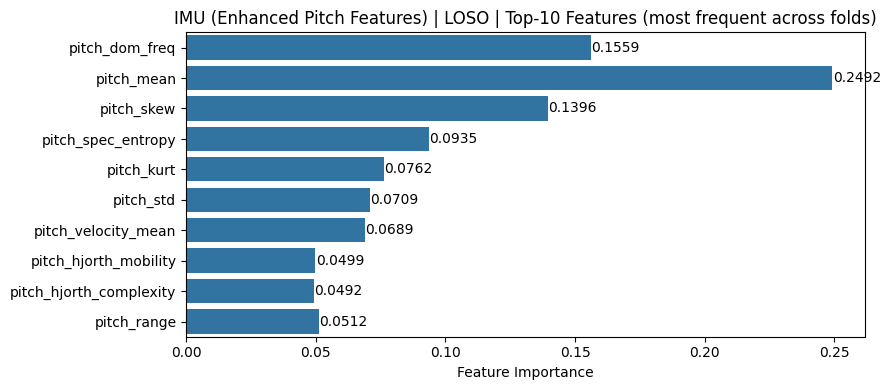

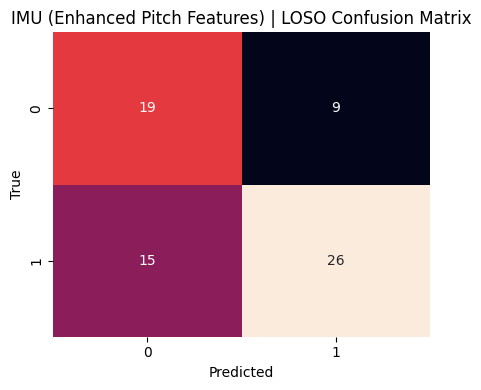


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - LOSO
Model Size:        523.53 KB
Mean Latency:      13.057 ms
95th Percentile:   13.877 ms
Throughput:          76.6 fps
Number of Trees:      500
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_dom_freq, pitch_mean, pitch_skew, pitch_spec_entropy, pitch_kurt, pitch_std, pitch_velocity_mean, pitch_hjorth_mobility, pitch_hjorth_complexity, pitch_range


########################################################################################################################
# DEPLOYMENT METRICS SUMMARY (for Raspberry Pi / Edge Device)
########################################################################################################################

Model                               Size (KB)    Latency (ms)    p95 (ms)     Throughput      Trees    Features   RT Status      
------------------------------------------------------------------------------------------------------------------------
EEG 8

In [90]:
"""
Discomfort Classification using EEG/IMU with Baseline Correction

KEY FEATURES:
- Excludes ALL rest data
- Uses d1/d2/d3 from Posture column as sessions
- Per-participant baseline correction: d1=baseline, d3=polarity
- Top-10 features only
- Enhanced IMU features
- Balanced training
- Deployment metrics for Raspberry Pi
- EEG: 1–30 Hz band-pass + 1–4 Hz EOG regression before feature extraction
"""

import os, glob, warnings, time, pickle
import numpy as np
import pandas as pd
from difflib import get_close_matches

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# CONFIG
BASE_PATH = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
LABEL_FILE = "processed_data.csv"
FS_EEG, FS_IMU = 125, 50
WIN_LEN_SEC, OVERLAP_FRAC, TRIM_SEC = 5, 0.5, 10
CORR_THRESHOLD, TOP_K, RANDOM_STATE = 0.90, 10, 42
FREQ_RANGE, THETA_BAND, ALPHA_BAND, BETA_BAND = (2, 40), (4, 8), (8, 13), (13, 30)
MAX_EEG_CHANNELS = None

# EEG filtering (for EOG cleaning)
EEG_LOW = 1.0
EEG_HIGH = 30.0

# =============================================================================
# UTILITIES
# =============================================================================

def safe_np(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def bandpower(freqs, psd, band):
    lo, hi = band
    m = (freqs >= lo) & (freqs <= hi)
    return float(simps(psd[m], freqs[m])) if np.sum(m) >= 2 else 0.0

def spectral_entropy(psd):
    psd = safe_np(psd)
    if len(psd) == 0:
        return 0.0
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

def hjorth_params(x):
    x = safe_np(x)
    if len(x) < 5:
        return {
            "hjorth_activity": 0.0,
            "hjorth_mobility": 0.0,
            "hjorth_complexity": 0.0,
        }
    dx, ddx = np.diff(x), np.diff(np.diff(x))
    var_x, var_dx, var_ddx = np.var(x), np.var(dx), np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt((var_ddx / (var_dx + 1e-12)) /
                         (var_dx / (var_x + 1e-12) + 1e-12))
    return {
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }

def zcr(x):
    x = safe_np(x)
    if len(x) < 2:
        return 0.0
    s = np.sign(x - np.mean(x))
    return float(np.mean(np.diff(s) != 0))

def line_length(x):
    x = safe_np(x)
    return float(np.sum(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

def summarize_window_dicts(dicts):
    if not dicts:
        return None
    keys = sorted(dicts[0].keys())
    out = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        out[f"{k}_mean"] = float(np.mean(vals))
        out[f"{k}_std"] = float(np.std(vals))
        out[f"{k}_min"] = float(np.min(vals))
        out[f"{k}_max"] = float(np.max(vals))
        out[f"{k}_range"] = float(np.ptp(vals))
    return out

# =============================================================================
# FILE RESOLUTION
# =============================================================================

def resolve_participant_folder(participant):
    participant = str(participant).strip()
    if not os.path.isdir(BASE_PATH):
        return None
    candidates = [
        d for d in os.listdir(BASE_PATH)
        if os.path.isdir(os.path.join(BASE_PATH, d))
    ]
    for d in candidates:
        if d.lower() == participant.lower():
            return os.path.join(BASE_PATH, d)
    match = get_close_matches(participant, candidates, n=1, cutoff=0.60)
    return os.path.join(BASE_PATH, match[0]) if match else None

def find_first_file(participant, session, modality):
    """Find file for participant/session/modality, EXCLUDING rest folders."""
    p_dir = resolve_participant_folder(participant)
    if p_dir is None:
        return None
    session = str(session).lower().strip()
    pattern = os.path.join(p_dir, modality, "**", f"*{session}*.csv")
    files = glob.glob(pattern, recursive=True)
    files = [f for f in files if "rest" not in f.lower()]
    return files[0] if files else None

# =============================================================================
# IMU BASELINE (D1 = NEUTRAL, D3 = POLARITY)
# =============================================================================

def compute_participant_baseline(participant, label_df):
    """Compute P_base from d1, polarity from d3."""
    participant = str(participant).strip()

    # D1 baseline
    d1_mask = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd1'
    )
    d1_rows = label_df[d1_mask]
    if len(d1_rows) == 0:
        return None, None

    d1_pitches = []
    for _, _row in d1_rows.iterrows():
        imu_file = find_first_file(participant, 'd1', 'imu')
        if imu_file:
            try:
                df_imu = pd.read_csv(imu_file)
                if 'Pitch' in df_imu.columns:
                    pitch_data = pd.to_numeric(
                        df_imu['Pitch'], errors='coerce'
                    ).dropna().values
                    if len(pitch_data) > 0:
                        d1_pitches.extend(pitch_data)
            except Exception:
                continue

    if len(d1_pitches) == 0:
        return None, None

    P_base = float(np.median(d1_pitches))

    # D3 polarity
    d3_mask = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd3'
    )
    d3_rows = label_df[d3_mask]
    if len(d3_rows) == 0:
        s = 1.0
    else:
        d3_pitches = []
        for _, _row in d3_rows.iterrows():
            imu_file = find_first_file(participant, 'd3', 'imu')
            if imu_file:
                try:
                    df_imu = pd.read_csv(imu_file)
                    if 'Pitch' in df_imu.columns:
                        pitch_data = pd.to_numeric(
                            df_imu['Pitch'], errors='coerce'
                        ).dropna().values
                        if len(pitch_data) > 0:
                            d3_pitches.extend(pitch_data)
                except Exception:
                    continue
        if len(d3_pitches) == 0:
            s = 1.0
        else:
            d3_median = float(np.median(d3_pitches))
            s = np.sign(d3_median - P_base)
            if s == 0:
                s = 1.0

    return P_base, s

def apply_baseline_correction(pitch_raw, P_base, s):
    """Apply: flex(t) = s × (pitch_raw(t) - P_base)."""
    if P_base is None or s is None:
        return pitch_raw
    return s * (pitch_raw - P_base)

# =============================================================================
# EEG FILTERING + EOG REGRESSION
# =============================================================================

def eeg_bandpass(data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG, order=4):
    """Band-pass filter EEG data (channels in columns)."""
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, data, axis=0)

def eog_bandpass(eog, fs=FS_EEG, low=1.0, high=4.0, order=4):
    """Band-pass EOG to 1–4 Hz to isolate eye-movement components."""
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS_EEG):
    """
    Basic EOG regression: band-pass EOG to 1–4 Hz, then for each EEG
    channel subtract beta * eog_filt (simple linear regression).[web:129]
    """
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data

    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a, b = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)
            eeg_clean[:, ch] = eeg_clean[:, ch] - a * eog_filt
        except Exception:
            continue
    return eeg_clean

# =============================================================================
# EEG FEATURES
# =============================================================================

def eeg_channel_features(sig, fs):
    sig = safe_np(sig)
    if len(sig) < int(WIN_LEN_SEC * fs):
        return None

    win = int(WIN_LEN_SEC * fs)
    noverlap = int(WIN_LEN_SEC * fs * OVERLAP_FRAC)
    freqs, psd = welch(sig, fs=fs, nperseg=win, noverlap=noverlap)

    t = bandpower(freqs, psd, THETA_BAND)
    a = bandpower(freqs, psd, ALPHA_BAND)
    b = bandpower(freqs, psd, BETA_BAND)

    m_total = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
    tot = float(simps(psd[m_total], freqs[m_total])) if np.sum(m_total) >= 2 else (t + a + b)

    denom = tot + 1e-12
    t_rel, a_rel, b_rel = t / denom, a / denom, b / denom

    tbr = t / (b + 1e-12)
    engagement = b / (a + t + 1e-12)

    se = spectral_entropy(psd[m_total]) if np.sum(m_total) >= 4 else spectral_entropy(psd)

    feats_time = {
        "mean": float(np.mean(sig)),
        "std": float(np.std(sig)),
        "rms": float(np.sqrt(np.mean(sig**2))),
        "skew": float(skew(sig)) if len(sig) > 10 else 0.0,
        "kurt": float(kurtosis(sig)) if len(sig) > 10 else 0.0,
        "zcr": zcr(sig),
        "line_length": line_length(sig),
    }
    feats_time.update(hjorth_params(sig))

    return {
        "theta": t,
        "alpha": a,
        "beta": b,
        "total": tot,
        "theta_rel": t_rel,
        "alpha_rel": a_rel,
        "beta_rel": b_rel,
        "tbr": float(tbr),
        "engagement": float(engagement),
        "spec_entropy": float(se),
        **feats_time,
    }

def coherence_band_means(sig_i, sig_j, fs):
    sig_i, sig_j = safe_np(sig_i), safe_np(sig_j)
    win = int(WIN_LEN_SEC * fs)
    if len(sig_i) < win or len(sig_j) < win:
        return None
    f, cxy = coherence(sig_i, sig_j, fs=fs, nperseg=win)
    out = {}
    for name, band in [("theta", THETA_BAND), ("alpha", ALPHA_BAND), ("beta", BETA_BAND)]:
        lo, hi = band
        m = (f >= lo) & (f <= hi)
        out[f"coh_{name}"] = float(np.mean(cxy[m])) if np.sum(m) >= 2 else 0.0
    return out

def extract_eeg_trial_features(data, fs=FS_EEG):
    if data is None or len(data.shape) != 2:
        return None

    trim = int(TRIM_SEC * fs)
    if data.shape[0] <= 2 * trim:
        return None

    seg = data[trim:-trim, :]

    win = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win
    if seg.shape[0] < win:
        return None

    C = seg.shape[1]
    ch_idxs = list(range(C))
    if MAX_EEG_CHANNELS is not None:
        ch_idxs = ch_idxs[:min(MAX_EEG_CHANNELS, C)]

    pairs = [
        (ch_idxs[i], ch_idxs[j])
        for i in range(len(ch_idxs))
        for j in range(i + 1, len(ch_idxs))
    ]

    win_dicts, coh_dicts = [], []

    for start in range(0, seg.shape[0] - win + 1, step):
        wseg = seg[start:start + win, :]

        d = {}
        for ci in ch_idxs:
            feats = eeg_channel_features(wseg[:, ci], fs)
            if feats is None:
                continue
            for k, v in feats.items():
                d[f"ch{ci+1}_{k}"] = v
        if len(d) > 0:
            win_dicts.append(d)

        cd = {}
        for (i, j) in pairs:
            cfeats = coherence_band_means(wseg[:, i], wseg[:, j], fs)
            if cfeats is None:
                continue
            for k, v in cfeats.items():
                cd[f"ch{i+1}_ch{j+1}_{k}"] = v
        if len(cd) > 0:
            coh_dicts.append(cd)

    if not win_dicts:
        return None

    out = summarize_window_dicts(win_dicts)
    out_coh = summarize_window_dicts(coh_dicts) if coh_dicts else {}
    out.update(out_coh)
    return out

# =============================================================================
# ENHANCED IMU FEATURES
# =============================================================================

def extract_enhanced_imu_features(pitch, fs=FS_IMU, P_base=None, s=None):
    pitch = pd.to_numeric(pd.Series(pitch), errors="coerce").dropna().values
    pitch = safe_np(pitch)
    if len(pitch) == 0:
        return None

    trim = int(TRIM_SEC * fs)
    if len(pitch) <= 2 * trim:
        return None

    seg = pitch[trim:-trim]
    seg = safe_np(seg)
    if len(seg) < 10:
        return None

    if P_base is not None and s is not None:
        seg = apply_baseline_correction(seg, P_base, s)
        seg = safe_np(seg)
        if len(seg) < 10:
            return None

    features = {}
    features["pitch_mean"] = float(np.mean(seg))
    features["pitch_std"] = float(np.std(seg))
    features["pitch_rms"] = float(np.sqrt(np.mean(seg**2)))
    features["pitch_range"] = float(np.ptp(seg))
    features["pitch_median"] = float(np.median(seg))
    features["pitch_p25"] = float(np.percentile(seg, 25))
    features["pitch_p75"] = float(np.percentile(seg, 75))
    features["pitch_iqr"] = float(np.percentile(seg, 75) - np.percentile(seg, 25))
    features["pitch_skew"] = float(skew(seg)) if len(seg) > 10 else 0.0
    features["pitch_kurt"] = float(kurtosis(seg)) if len(seg) > 10 else 0.0

    velocity = np.diff(seg) * fs
    acceleration = np.diff(np.diff(seg) * fs) * fs

    features["pitch_velocity_mean"] = float(np.mean(np.abs(velocity)))
    features["pitch_velocity_std"] = float(np.std(velocity))
    features["pitch_velocity_max"] = float(np.max(np.abs(velocity)))

    features["pitch_accel_mean"] = float(np.mean(np.abs(acceleration)))
    features["pitch_accel_std"] = float(np.std(acceleration))
    features["pitch_accel_max"] = float(np.max(np.abs(acceleration)))

    features["pitch_zcr"] = zcr(seg)
    features["pitch_line_length"] = line_length(seg)

    hjorth = hjorth_params(seg)
    features["pitch_hjorth_activity"] = hjorth["hjorth_activity"]
    features["pitch_hjorth_mobility"] = hjorth["hjorth_mobility"]
    features["pitch_hjorth_complexity"] = hjorth["hjorth_complexity"]

    n = len(seg)
    if n >= 64:
        yf = fft(seg - np.mean(seg))
        xf = fftfreq(n, 1 / fs)[: n // 2]
        power = np.abs(yf[: n // 2]) ** 2

        if len(power) > 0 and np.max(power) > 0:
            dom_idx = np.argmax(power)
            features["pitch_dom_freq"] = float(xf[dom_idx])
        else:
            features["pitch_dom_freq"] = 0.0

        features["pitch_spec_entropy"] = spectral_entropy(power)

        low_mask = xf < 1.0
        high_mask = xf >= 1.0
        low_power = np.sum(power[low_mask]) if np.sum(low_mask) > 0 else 0.0
        high_power = np.sum(power[high_mask]) if np.sum(high_mask) > 0 else 0.0
        total_power = low_power + high_power + 1e-12

        features["pitch_low_freq_power"] = float(low_power)
        features["pitch_high_freq_power"] = float(high_power)
        features["pitch_low_freq_ratio"] = float(low_power / total_power)
        features["pitch_high_freq_ratio"] = float(high_power / total_power)
    else:
        for k in [
            "pitch_dom_freq", "pitch_spec_entropy",
            "pitch_low_freq_power", "pitch_high_freq_power",
            "pitch_low_freq_ratio", "pitch_high_freq_ratio",
        ]:
            features[k] = 0.0

    return features

# =============================================================================
# PREPROCESSING
# =============================================================================

def corr_filter_fit(X_train_df, threshold=CORR_THRESHOLD):
    corr = X_train_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in X_train_df.columns if c not in drop_cols]

def corr_filter_apply(X_df, keep_cols):
    keep_cols = [c for c in keep_cols if c in X_df.columns]
    return X_df[keep_cols].copy()

def balance_undersample(X, y, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y = np.asarray(y).astype(int)
    idx0, idx1 = np.where(y == 0)[0], np.where(y == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        return X, y
    n = min(len(idx0), len(idx1))
    idx0_s = rng.choice(idx0, size=n, replace=False)
    idx1_s = rng.choice(idx1, size=n, replace=False)
    keep = np.concatenate([idx0_s, idx1_s])
    rng.shuffle(keep)
    if isinstance(X, pd.DataFrame):
        return X.iloc[keep].reset_index(drop=True), y[keep]
    else:
        return X[keep], y[keep]

def topk_by_rf_importance(X_train_sc, y_train, feature_names, k=TOP_K):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train_sc, y_train)
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:min(k, len(imp))]
    return idx, [feature_names[i] for i in idx], imp

# =============================================================================
# PLOTTING
# =============================================================================

def plot_top_features(names, values, title):
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(x=values, y=names)
    plt.title(title)
    plt.xlabel("Feature Importance")
    plt.ylabel("")
    for p, v in zip(ax.patches, values):
        ax.text(
            p.get_width() + 1e-4,
            p.get_y() + p.get_height() / 2,
            f"{v:.4f}",
            va="center",
        )
    plt.tight_layout()
    plt.show()

def plot_confusion(cm, title):
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# =============================================================================
# BUILD X/y/groups
# =============================================================================

def build_X_y_groups(df):
    y = df["Label"].values.astype(int)
    groups = df["Participant"].astype(str).values
    X = df.drop(columns=["Participant", "Label", "Posture"], errors="ignore")
    X = X.loc[:, ~X.columns.str.contains("posture", case=False, regex=True)]
    return X, y, groups

# =============================================================================
# DEPLOYMENT METRICS
# =============================================================================

def measure_latency(clf, X_sample, n_runs=100):
    latencies = []
    for _ in range(10):
        _ = clf.predict(X_sample)  # Warmup
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return np.mean(latencies), np.percentile(latencies, 95)

def get_deployment_metrics(clf, X_test, top_features):
    model_size_kb = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput = 1000 / mean_lat
    n_trees = clf.n_estimators if hasattr(clf, 'n_estimators') else 'N/A'
    rt_status = (
        "✓ EXCELLENT" if mean_lat < 50 else
        "✓ GOOD" if mean_lat < 100 else
        "⚠ ACCEPTABLE" if mean_lat < 200 else
        "✗ SLOW"
    )
    return {
        'model_size_kb': model_size_kb,
        'mean_latency_ms': mean_lat,
        'p95_latency_ms': p95_lat,
        'throughput_fps': throughput,
        'n_features': len(top_features),
        'n_trees': n_trees,
        'features': top_features,
        'rt_status': rt_status,
    }

def print_deployment_metrics(metrics, model_name):
    print(f"\n{'='*90}")
    print(f"DEPLOYMENT METRICS: {model_name}")
    print(f"{'='*90}")
    print(f"Model Size:      {metrics['model_size_kb']:>8.2f} KB")
    print(f"Mean Latency:    {metrics['mean_latency_ms']:>8.3f} ms")
    print(f"95th Percentile: {metrics['p95_latency_ms']:>8.3f} ms")
    print(f"Throughput:      {metrics['throughput_fps']:>8.1f} fps")
    print(f"Number of Trees: {metrics['n_trees']:>8}")
    print(f"Features Used:   {metrics['n_features']:>8}")
    print(f"RT Status:       {metrics['rt_status']}")
    print(f"Feature Names:   {', '.join(metrics['features'])}")
    print(f"{'='*90}")

# =============================================================================
# EVALUATION: 80-20 (row-level, not group-based)
# =============================================================================

def eval_random_80_20(df, title):
    print("\n" + "=" * 90)
    print(f"{title} | Random Forest | 80-20 Split | Top-{TOP_K} Features")
    print("=" * 90)

    X, y, _ = build_X_y_groups(df)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    keep_cols = corr_filter_fit(X_train, threshold=CORR_THRESHOLD)
    X_train = corr_filter_apply(X_train, keep_cols)
    X_test = corr_filter_apply(X_test, keep_cols)

    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()
    X_train_imp, X_test_imp = imputer.fit_transform(X_train), imputer.transform(X_test)
    X_train_sc, X_test_sc = scaler.fit_transform(X_train_imp), scaler.transform(X_test_imp)

    X_train_sc_bal, y_train_bal = balance_undersample(
        X_train_sc, y_train, seed=RANDOM_STATE
    )

    feat_names = list(X_train.columns)
    top_idx, top_names, _ = topk_by_rf_importance(
        X_train_sc_bal, y_train_bal, feat_names, k=TOP_K
    )

    X_train_final, X_test_final = X_train_sc_bal[:, top_idx], X_test_sc[:, top_idx]

    clf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_train_final, y_train_bal)

    pred = clf.predict(X_test_final)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)

    print(f"Top-{TOP_K} features used: {', '.join(top_names)}")
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print(classification_report(y_test, pred, digits=3, zero_division=0))

    plot_top_features(
        top_names, clf.feature_importances_,
        f"{title} | 80-20 | Top-{TOP_K} Feature Importances"
    )
    plot_confusion(cm, f"{title} | 80-20 Confusion Matrix")

    metrics = get_deployment_metrics(clf, X_test_final, top_names)
    print_deployment_metrics(metrics, f"{title} - 80/20 Split")

    return {
        "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "cm": cm, "top_features": top_names, "metrics": metrics,
    }

# =============================================================================
# EVALUATION: LOSO
# =============================================================================

def eval_loso(df, title):
    print("\n" + "=" * 90)
    print(f"{title} | Random Forest | LOSO | Top-{TOP_K} Features per fold")
    print("=" * 90)

    X, y, groups = build_X_y_groups(df)
    logo = LeaveOneGroupOut()

    y_true, y_pred = [], []
    feat_freq, feat_imp_sum = {}, {}
    last_clf, last_X_test = None, None

    for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[tr_idx].replace([np.inf, -np.inf], np.nan)
        X_test = X.iloc[te_idx].replace([np.inf, -np.inf], np.nan)
        y_train, y_test = y[tr_idx], y[te_idx]

        keep_cols = corr_filter_fit(X_train, threshold=CORR_THRESHOLD)
        X_train = corr_filter_apply(X_train, keep_cols)
        X_test = corr_filter_apply(X_test, keep_cols)

        imputer = SimpleImputer(strategy="mean")
        scaler = StandardScaler()
        X_train_imp, X_test_imp = imputer.fit_transform(X_train), imputer.transform(X_test)
        X_train_sc, X_test_sc = scaler.fit_transform(X_train_imp), scaler.transform(X_test_imp)

        X_train_sc_bal, y_train_bal = balance_undersample(
            X_train_sc, y_train, seed=RANDOM_STATE + fold
        )

        feat_names = list(X_train.columns)
        top_idx, top_names_fold, _ = topk_by_rf_importance(
            X_train_sc_bal, y_train_bal, feat_names, k=TOP_K
        )

        X_train_final, X_test_final = X_train_sc_bal[:, top_idx], X_test_sc[:, top_idx]

        clf = RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        clf.fit(X_train_final, y_train_bal)

        pred = clf.predict(X_test_final)
        y_true.extend(y_test.tolist())
        y_pred.extend(pred.tolist())

        fold_imps = clf.feature_importances_
        for n, impv in zip(top_names_fold, fold_imps):
            feat_freq[n] = feat_freq.get(n, 0) + 1
            feat_imp_sum[n] = feat_imp_sum.get(n, 0.0) + float(impv)

        last_clf, last_X_test = clf, X_test_final

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    freq_items = sorted(feat_freq.items(), key=lambda x: (-x[1], x[0]))
    top_global = freq_items[:TOP_K]
    top_names = [n for n, _ in top_global]
    top_vals = [feat_imp_sum[n] / (feat_freq[n] + 1e-12) for n in top_names]

    plot_top_features(
        top_names, top_vals,
        f"{title} | LOSO | Top-{TOP_K} Features (most frequent across folds)"
    )
    plot_confusion(cm, f"{title} | LOSO Confusion Matrix")

    if last_clf is not None and last_X_test is not None:
        metrics = get_deployment_metrics(last_clf, last_X_test, top_names)
        print_deployment_metrics(metrics, f"{title} - LOSO")
    else:
        metrics = None

    return {
        "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "cm": cm, "top_features_loso": top_names, "metrics": metrics,
    }

# =============================================================================
# MAIN
# =============================================================================

def main():
    if not os.path.exists(LABEL_FILE):
        raise FileNotFoundError(f"Label file not found: {LABEL_FILE}")

    df_labels = pd.read_csv(LABEL_FILE)
    for c in ["Participant", "Posture", "Label"]:
        if c not in df_labels.columns:
            raise ValueError(f"{LABEL_FILE} must contain: {c}")

    # Compute IMU baselines
    print("\n" + "=" * 90)
    print("Computing IMU baseline corrections (d1=baseline, d3=polarity)...")
    print("=" * 90)

    participant_baselines = {}
    unique_participants = df_labels["Participant"].unique()
    for p in unique_participants:
        P_base, s = compute_participant_baseline(p, df_labels)
        participant_baselines[p] = (P_base, s)
        if P_base is not None:
            polarity_str = "POSITIVE (+1)" if s > 0 else "NEGATIVE (-1)"
            print(f"{p:15s} | P_base = {P_base:+7.2f}° | Polarity: {polarity_str}")
        else:
            print(f"{p:15s} | No d1 data found → baseline correction DISABLED")

    eeg_rows, imu_rows = [], []

    print("\n" + "=" * 90)
    print("Extracting features (EXCLUDING rest data)...")
    print("=" * 90)

    total = len(df_labels)
    for i, row in enumerate(df_labels.itertuples(index=False), start=1):
        p = str(getattr(row, "Participant")).strip()
        pos = str(getattr(row, "Posture")).lower().strip()
        lab = int(getattr(row, "Label"))
        print(f"[{i}/{total}] {p} | {pos}")

        # ---------------- EEG ----------------
        eeg_file = find_first_file(p, pos, "eeg")
        if eeg_file is None:
            print("   ✗ EEG missing")
        else:
            try:
                df_eeg = pd.read_csv(eeg_file)

                # Optional EOG column
                eog_sig = df_eeg["EOG"].values if "EOG" in df_eeg.columns else None

                # EEG channels = all columns except EOG
                eeg_cols = [c for c in df_eeg.columns if c != "EOG"]
                if len(eeg_cols) == 0:
                    print("   ✗ No EEG columns found")
                else:
                    eeg_data = df_eeg[eeg_cols].values

                    # 1–30 Hz band-pass
                    eeg_filt = eeg_bandpass(
                        eeg_data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG
                    )

                    # 1–4 Hz EOG regression
                    eeg_clean = regress_eog_basic(eeg_filt, eog_sig, fs=FS_EEG)

                    feats = extract_eeg_trial_features(eeg_clean, fs=FS_EEG)
                    if feats is None:
                        print("   ✗ EEG unreadable/too short")
                    else:
                        eeg_rows.append(
                            {"Participant": p, "Posture": pos, "Label": lab, **feats}
                        )
                        print("   ✓ EEG ok (1–30 Hz + EOG regression)")
            except Exception as e:
                print(f"   ✗ EEG read error: {e}")

        # ---------------- IMU ----------------
        imu_file = find_first_file(p, pos, "imu")
        if imu_file is None:
            print("   ✗ IMU missing")
        else:
            try:
                df_imu = pd.read_csv(imu_file)
                if "Pitch" not in df_imu.columns:
                    print("   ✗ IMU no Pitch column")
                else:
                    P_base, s = participant_baselines.get(p, (None, None))
                    feats = extract_enhanced_imu_features(
                        df_imu["Pitch"].values, fs=FS_IMU, P_base=P_base, s=s
                    )
                    if feats is None:
                        print("   ✗ IMU unreadable/too short")
                    else:
                        imu_rows.append(
                            {"Participant": p, "Posture": pos, "Label": lab, **feats}
                        )
                        baseline_info = (
                            " (baseline corrected)" if P_base is not None else " (no baseline)"
                        )
                        print(f"   ✓ IMU ok{baseline_info}")
            except Exception as e:
                print(f"   ✗ IMU read error: {e}")

    all_metrics = []

    # EEG EVAL
    if eeg_rows:
        df_eeg = (
            pd.DataFrame(eeg_rows)
            .replace([np.inf, -np.inf], np.nan)
            .dropna(axis=0, how="any")
        )
        print(f"\n{'='*90}")
        print(f"EEG: {len(df_eeg)} trials | {df_eeg.shape[1] - 3} features")
        print(f"{'='*90}")
        r1 = eval_random_80_20(df_eeg, "EEG (per-channel + coherence, EOG-cleaned)")
        r2 = eval_loso(df_eeg, "EEG (per-channel + coherence, EOG-cleaned)")
        all_metrics.extend([r1["metrics"], r2["metrics"]])
    else:
        print("\nNo EEG trials extracted.")

    # IMU EVAL
    if imu_rows:
        df_imu = (
            pd.DataFrame(imu_rows)
            .replace([np.inf, -np.inf], np.nan)
            .dropna(axis=0, how="any")
        )
        print(f"\n{'='*90}")
        print(f"IMU: {len(df_imu)} trials | {df_imu.shape[1] - 3} features (with baseline correction)")
        print(f"{'='*90}")
        r3 = eval_random_80_20(df_imu, "IMU (Enhanced Pitch Features)")
        r4 = eval_loso(df_imu, "IMU (Enhanced Pitch Features)")
        all_metrics.extend([r3["metrics"], r4["metrics"]])
    else:
        print("\nNo IMU trials extracted.")

    # SUMMARY
    print("\n\n" + "#" * 120)
    print("# DEPLOYMENT METRICS SUMMARY (for Raspberry Pi / Edge Device)")
    print("#" * 120)
    print(
        f"\n{'Model':<35} {'Size (KB)':<12} {'Latency (ms)':<15} "
        f"{'p95 (ms)':<12} {'Throughput':<15} {'Trees':<8} "
        f"{'Features':<10} {'RT Status':<15}"
    )
    print("-" * 120)

    model_names = ["EEG 80-20", "EEG LOSO", "IMU 80-20", "IMU LOSO"]
    for i, m in enumerate(all_metrics):
        if m is not None:
            print(
                f"{model_names[i]:<35} {m['model_size_kb']:>10.2f}  "
                f"{m['mean_latency_ms']:>13.3f}  "
                f"{m['p95_latency_ms']:>10.3f}  "
                f"{m['throughput_fps']:>10.1f} fps  "
                f"{m['n_trees']:>6}  {m['n_features']:>8}  "
                f"{m['rt_status']:<15}"
            )

    print("-" * 120)
    print("\nKEY TAKEAWAYS:")
    print("  • 80/20 is optimistic due to subject leakage; LOSO is the true subject-independent check.[web:123]")
    print("  • EOG regression + IMU baseline correction should stabilize performance across sessions.[web:109][web:129]")
    print("#" * 120)


if __name__ == "__main__":
    main()


<h1>Unimodal  Discomfort Analysis-rf, svm and xgb </h1>


Computing IMU baseline corrections (d1=baseline, d3=polarity)...
Postdoc         | P_base =   -3.41° | Polarity: NEGATIVE (-1)
Monon           | P_base =   +8.95° | Polarity: NEGATIVE (-1)
Manzz           | P_base =   +9.12° | Polarity: NEGATIVE (-1)
Ario            | P_base =   +6.80° | Polarity: NEGATIVE (-1)
Walid           | P_base =  +16.20° | Polarity: NEGATIVE (-1)
Riddho          | P_base =  +21.77° | Polarity: NEGATIVE (-1)
Prasun          | P_base =   -5.79° | Polarity: NEGATIVE (-1)
Pritam          | P_base =   -7.11° | Polarity: NEGATIVE (-1)
Orchi           | P_base =   -6.94° | Polarity: NEGATIVE (-1)
Saekh           | No d1 data found → baseline correction DISABLED
Ishita          | P_base =  +60.37° | Polarity: NEGATIVE (-1)
koushik         | P_base =  -66.11° | Polarity: NEGATIVE (-1)
Aziz            | P_base =  -62.25° | Polarity: POSITIVE (+1)
Abhay           | P_base =  +51.45° | Polarity: NEGATIVE (-1)
Krishna         | P_base =  +65.21° | Polarity: NEGATIVE (-1)


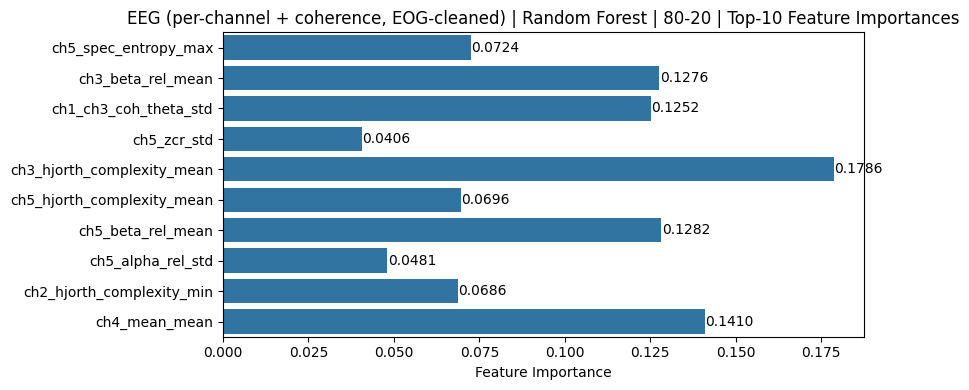

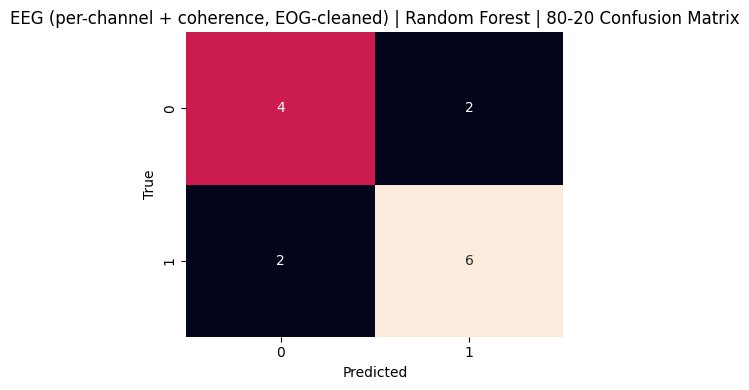


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - 80/20 Split | Random Forest
Model Size:         66.45 KB
Mean Latency:      13.834 ms
95th Percentile:   14.757 ms
Throughput:          72.3 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_hjorth_complexity_min, ch4_mean_mean

EEG (per-channel + coherence, EOG-cleaned) | Random Forest | LOSO | Top-10 Features per fold
Accuracy=0.638  Precision=0.750  Recall=0.585  F1=0.658
              precision    recall  f1-score   support

           0      0.541     0.714     0.615        28
           1      0.750     0.585     0.658        41

    accuracy                          0.638        69
   macro avg      0.645     0.650     0.636        69
weighted avg      0.665     0.638     0.640        69



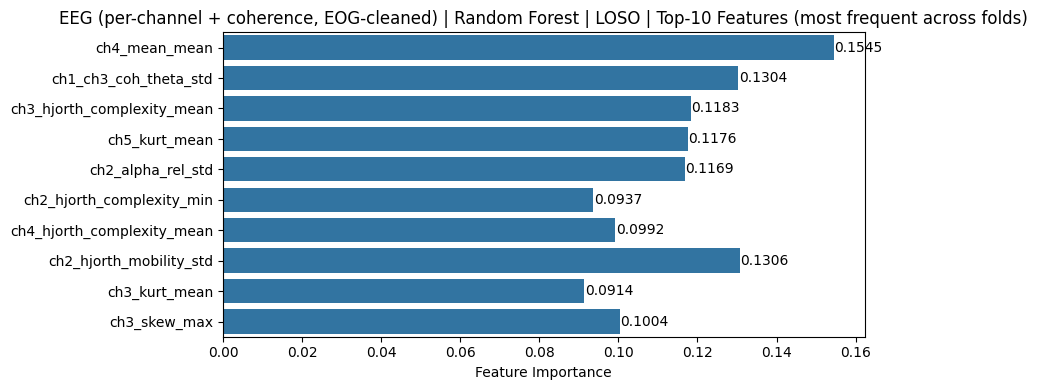

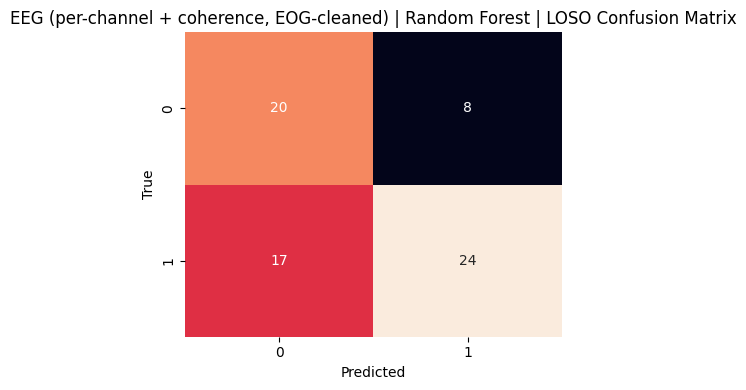


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - LOSO | Random Forest
Model Size:        516.03 KB
Mean Latency:      13.190 ms
95th Percentile:   13.674 ms
Throughput:          75.8 fps
Number of Trees:      500
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch4_mean_mean, ch1_ch3_coh_theta_std, ch3_hjorth_complexity_mean, ch5_kurt_mean, ch2_alpha_rel_std, ch2_hjorth_complexity_min, ch4_hjorth_complexity_mean, ch2_hjorth_mobility_std, ch3_kurt_mean, ch3_skew_max

##########################################################################################
# EEG CLASSIFICATION - SVM
##########################################################################################

EEG (per-channel + coherence, EOG-cleaned) | SVM | 80-20 Split | Top-10 Features
Top-10 features used: ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_h

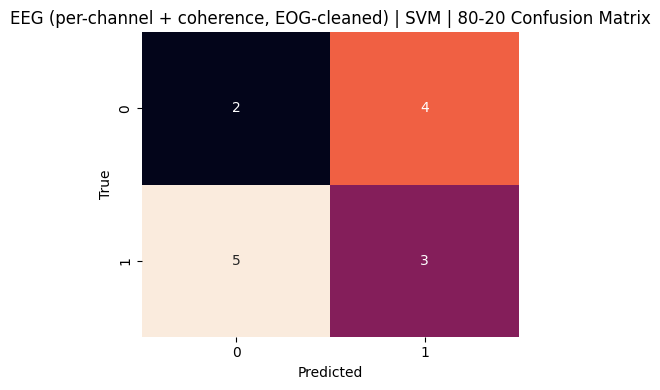


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - 80/20 Split | SVM
Model Size:          5.11 KB
Mean Latency:       0.032 ms
95th Percentile:    0.032 ms
Throughput:       31470.5 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_hjorth_complexity_min, ch4_mean_mean

EEG (per-channel + coherence, EOG-cleaned) | SVM | LOSO | Top-10 Features per fold
Accuracy=0.551  Precision=0.647  Recall=0.537  F1=0.587
              precision    recall  f1-score   support

           0      0.457     0.571     0.508        28
           1      0.647     0.537     0.587        41

    accuracy                          0.551        69
   macro avg      0.552     0.554     0.547        69
weighted avg      0.570     0.551     0.555        69

   (Feature importance

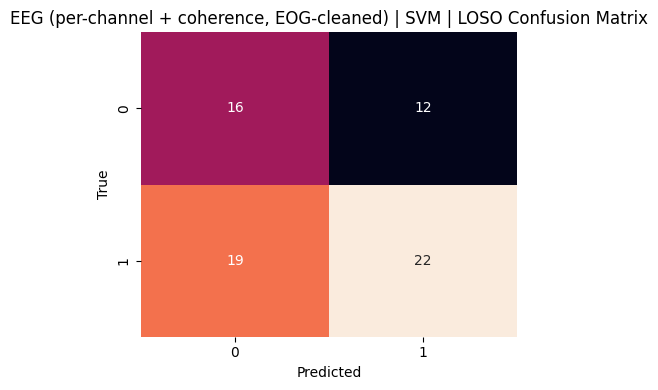


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - LOSO | SVM
Model Size:          5.50 KB
Mean Latency:       0.039 ms
95th Percentile:    0.104 ms
Throughput:       25897.2 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch4_mean_mean, ch3_skew_max, ch2_beta_rel_min, ch2_tbr_mean, ch2_alpha_rel_mean, ch2_hjorth_mobility_std, ch2_spec_entropy_min, ch2_beta_rel_mean, ch1_skew_min, ch2_beta_rel_std

##########################################################################################
# EEG CLASSIFICATION - GRADIENT BOOSTING
##########################################################################################

EEG (per-channel + coherence, EOG-cleaned) | Gradient Boosting | 80-20 Split | Top-10 Features
Top-10 features used: ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_hjorth_comple

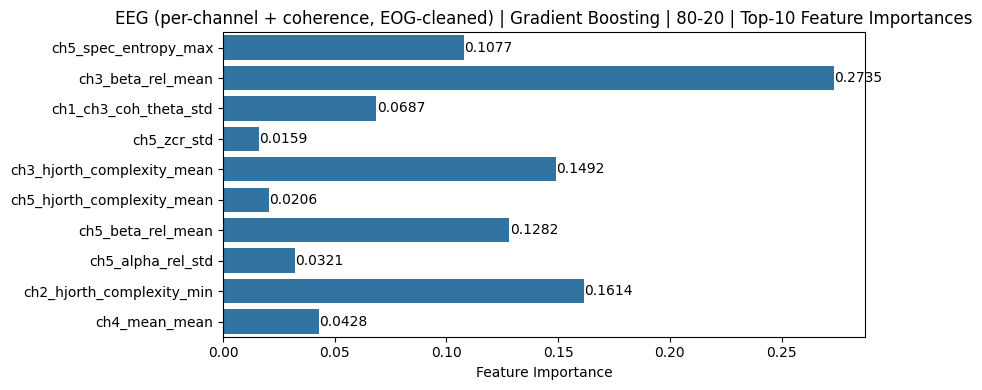

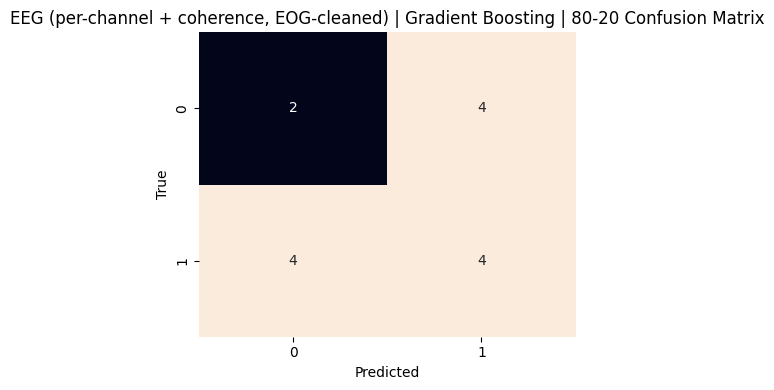


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - 80/20 Split | Gradient Boosting
Model Size:        131.87 KB
Mean Latency:       0.074 ms
95th Percentile:    0.105 ms
Throughput:       13513.4 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch5_spec_entropy_max, ch3_beta_rel_mean, ch1_ch3_coh_theta_std, ch5_zcr_std, ch3_hjorth_complexity_mean, ch5_hjorth_complexity_mean, ch5_beta_rel_mean, ch5_alpha_rel_std, ch2_hjorth_complexity_min, ch4_mean_mean

EEG (per-channel + coherence, EOG-cleaned) | Gradient Boosting | LOSO | Top-10 Features per fold
Accuracy=0.536  Precision=0.655  Recall=0.463  F1=0.543
              precision    recall  f1-score   support

           0      0.450     0.643     0.529        28
           1      0.655     0.463     0.543        41

    accuracy                          0.536        69
   macro avg      0.553     0.553     0.536        69
weighted avg      0.572     0.536     0.537      

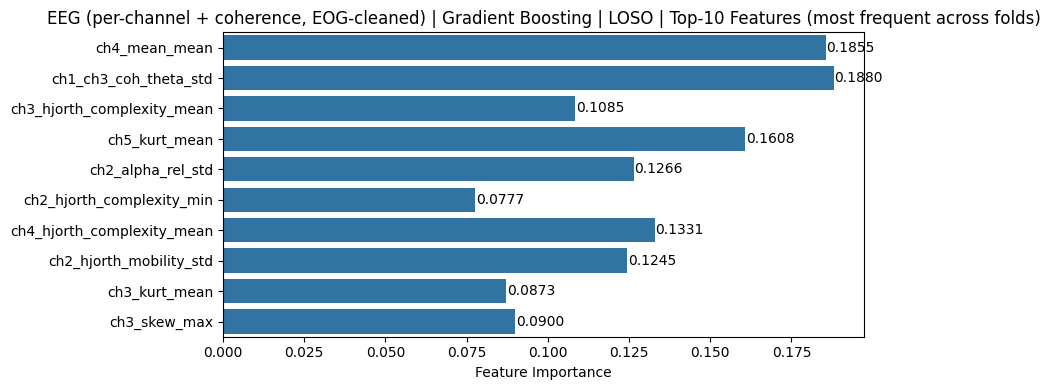

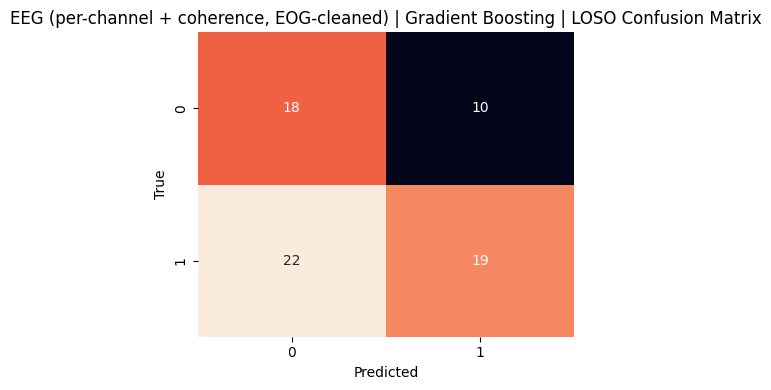


DEPLOYMENT METRICS: EEG (per-channel + coherence, EOG-cleaned) - LOSO | Gradient Boosting
Model Size:        128.50 KB
Mean Latency:       0.076 ms
95th Percentile:    0.097 ms
Throughput:       13167.3 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   ch4_mean_mean, ch1_ch3_coh_theta_std, ch3_hjorth_complexity_mean, ch5_kurt_mean, ch2_alpha_rel_std, ch2_hjorth_complexity_min, ch4_hjorth_complexity_mean, ch2_hjorth_mobility_std, ch3_kurt_mean, ch3_skew_max

IMU: 69 trials | 27 features (with baseline correction)

##########################################################################################
# IMU CLASSIFICATION - RANDOM FOREST
##########################################################################################

IMU (Enhanced Pitch Features) | Random Forest | 80-20 Split | Top-10 Features
Top-10 features used: pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, 

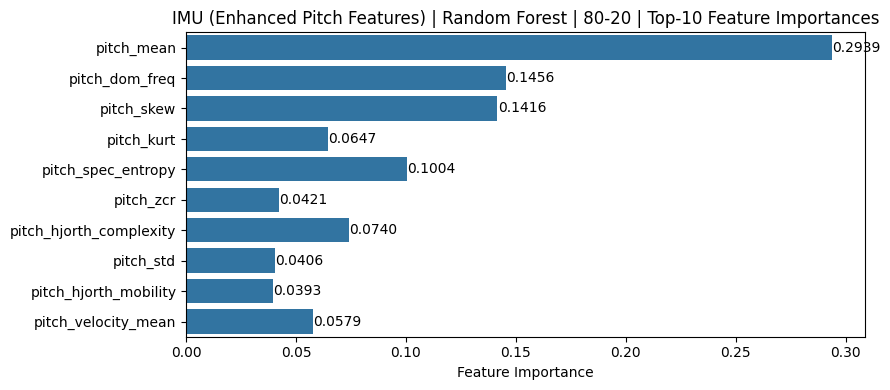

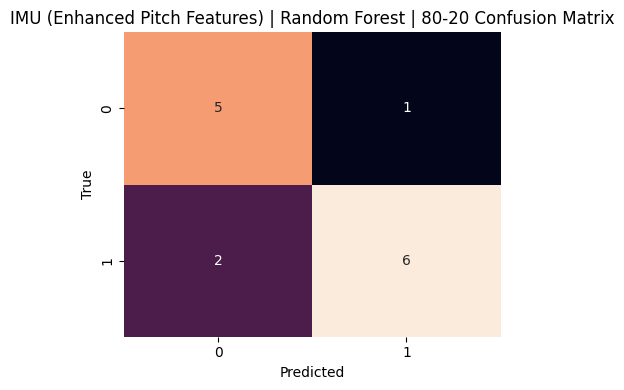


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - 80/20 Split | Random Forest
Model Size:         67.08 KB
Mean Latency:      13.916 ms
95th Percentile:   14.964 ms
Throughput:          71.9 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean

IMU (Enhanced Pitch Features) | Random Forest | LOSO | Top-10 Features per fold
Accuracy=0.652  Precision=0.743  Recall=0.634  F1=0.684
              precision    recall  f1-score   support

           0      0.559     0.679     0.613        28
           1      0.743     0.634     0.684        41

    accuracy                          0.652        69
   macro avg      0.651     0.656     0.649        69
weighted avg      0.668     0.652     0.655        69



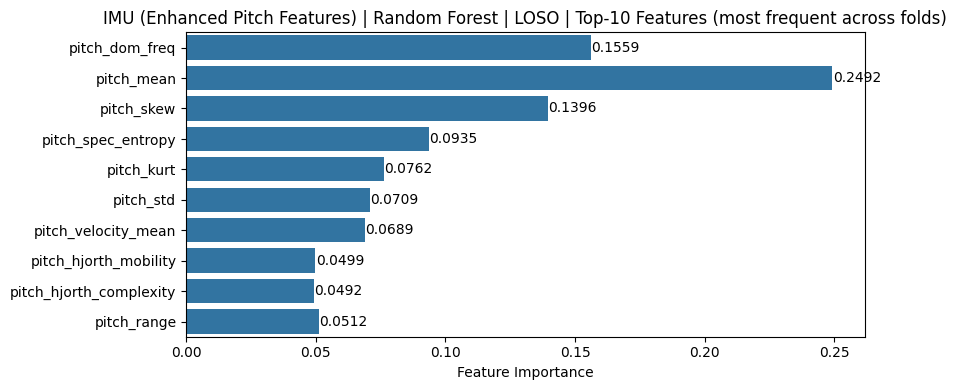

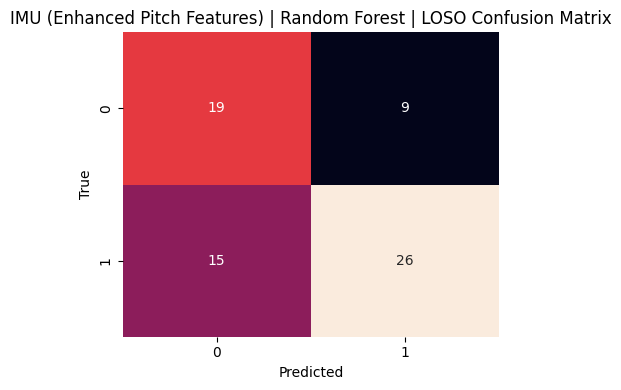


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - LOSO | Random Forest
Model Size:        523.53 KB
Mean Latency:      12.885 ms
95th Percentile:   13.590 ms
Throughput:          77.6 fps
Number of Trees:      500
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_dom_freq, pitch_mean, pitch_skew, pitch_spec_entropy, pitch_kurt, pitch_std, pitch_velocity_mean, pitch_hjorth_mobility, pitch_hjorth_complexity, pitch_range

##########################################################################################
# IMU CLASSIFICATION - SVM
##########################################################################################

IMU (Enhanced Pitch Features) | SVM | 80-20 Split | Top-10 Features
Top-10 features used: pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean
Accuracy=0.571  Precision=0.667  Recall=0.500  F1=0.571
              precision    r

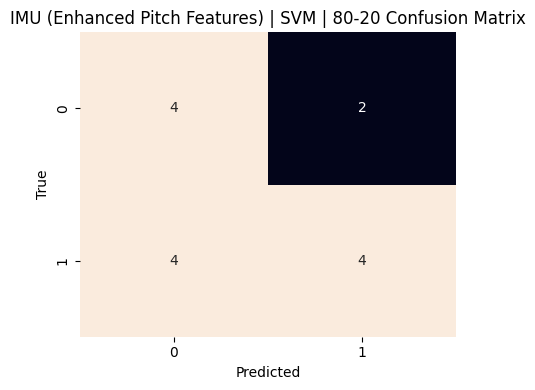


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - 80/20 Split | SVM
Model Size:          5.31 KB
Mean Latency:       0.035 ms
95th Percentile:    0.062 ms
Throughput:       28357.4 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean

IMU (Enhanced Pitch Features) | SVM | LOSO | Top-10 Features per fold
Accuracy=0.551  Precision=0.647  Recall=0.537  F1=0.587
              precision    recall  f1-score   support

           0      0.457     0.571     0.508        28
           1      0.647     0.537     0.587        41

    accuracy                          0.551        69
   macro avg      0.552     0.554     0.547        69
weighted avg      0.570     0.551     0.555        69

   (Feature importances not available for SVM)


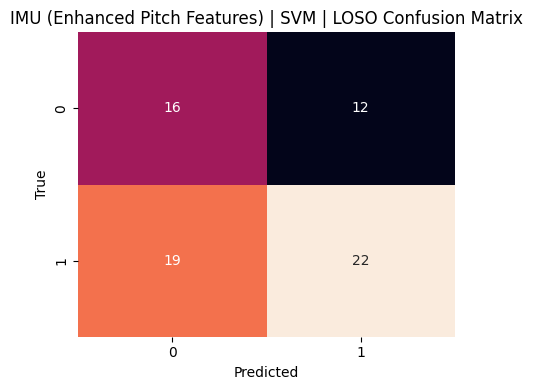


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - LOSO | SVM
Model Size:          5.89 KB
Mean Latency:       0.031 ms
95th Percentile:    0.035 ms
Throughput:       32165.6 fps
Number of Trees:      N/A
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_zcr, pitch_range, pitch_std, pitch_spec_entropy, pitch_iqr, pitch_velocity_max

##########################################################################################
# IMU CLASSIFICATION - GRADIENT BOOSTING
##########################################################################################

IMU (Enhanced Pitch Features) | Gradient Boosting | 80-20 Split | Top-10 Features
Top-10 features used: pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean
Accuracy=0.643  Precision=0.800  Recall=0.500  F1=0.615
              precision    recall  f1

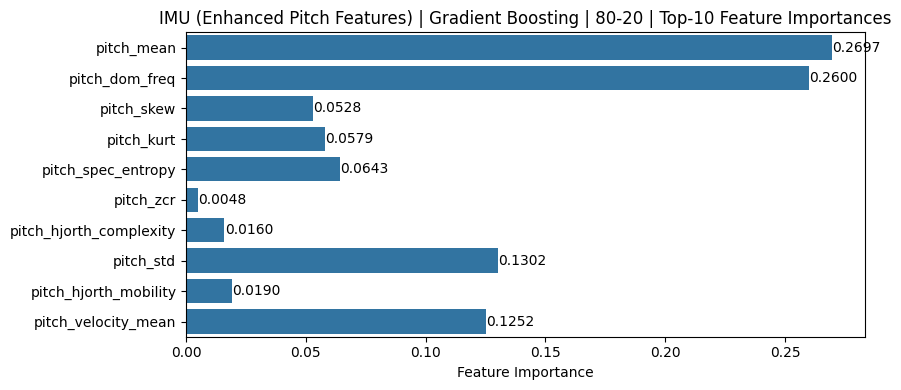

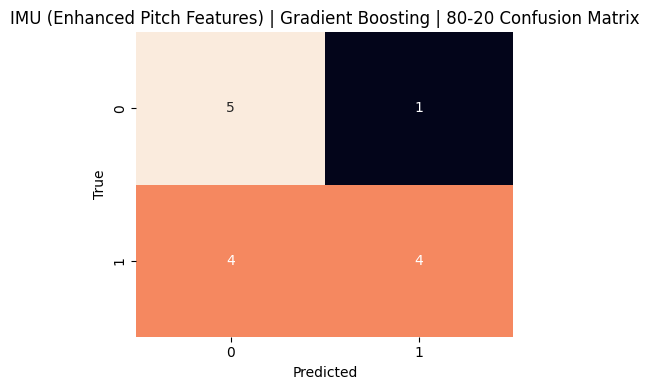


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - 80/20 Split | Gradient Boosting
Model Size:        116.96 KB
Mean Latency:       0.074 ms
95th Percentile:    0.082 ms
Throughput:       13544.0 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_mean, pitch_dom_freq, pitch_skew, pitch_kurt, pitch_spec_entropy, pitch_zcr, pitch_hjorth_complexity, pitch_std, pitch_hjorth_mobility, pitch_velocity_mean

IMU (Enhanced Pitch Features) | Gradient Boosting | LOSO | Top-10 Features per fold
Accuracy=0.652  Precision=0.730  Recall=0.659  F1=0.692
              precision    recall  f1-score   support

           0      0.562     0.643     0.600        28
           1      0.730     0.659     0.692        41

    accuracy                          0.652        69
   macro avg      0.646     0.651     0.646        69
weighted avg      0.662     0.652     0.655        69



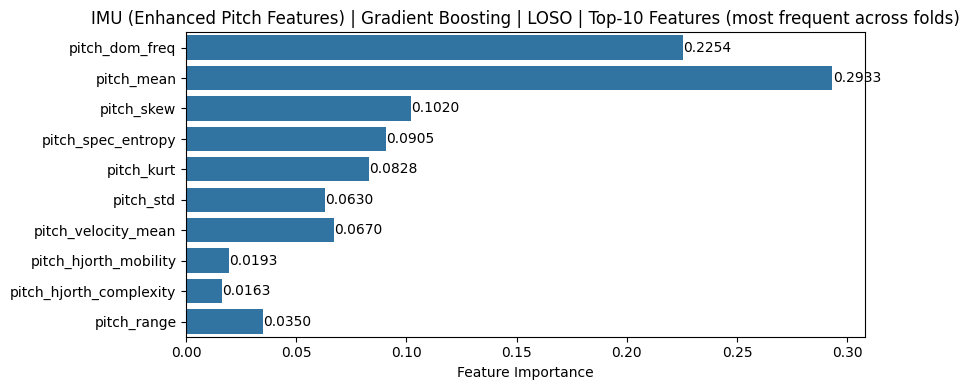

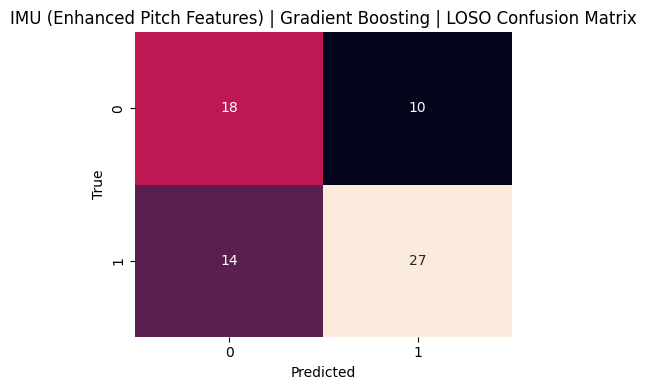


DEPLOYMENT METRICS: IMU (Enhanced Pitch Features) - LOSO | Gradient Boosting
Model Size:        113.44 KB
Mean Latency:       0.074 ms
95th Percentile:    0.093 ms
Throughput:       13438.0 fps
Number of Trees:      100
Features Used:         10
RT Status:       ✓ EXCELLENT
Feature Names:   pitch_dom_freq, pitch_mean, pitch_skew, pitch_spec_entropy, pitch_kurt, pitch_std, pitch_velocity_mean, pitch_hjorth_mobility, pitch_hjorth_complexity, pitch_range


########################################################################################################################
# DEPLOYMENT METRICS SUMMARY (for Raspberry Pi / Edge Device)
########################################################################################################################

Model                                              Classifier         Size (KB)    Latency (ms)    p95 (ms)     Throughput      Trees    Features   RT Status      
------------------------------------------------------------------------

In [3]:


import os, glob, warnings, time, pickle
import numpy as np
import pandas as pd
from difflib import get_close_matches

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Classifier name mappings
CLF_TITLE = {'rf': 'RANDOM FOREST', 'svm': 'SVM', 'gb': 'GRADIENT BOOSTING'}
CLF_PRETTY = {'rf': 'Random Forest', 'svm': 'SVM', 'gb': 'Gradient Boosting'}

# CONFIG
BASE_PATH = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
LABEL_FILE = "processed_data.csv"
FS_EEG, FS_IMU = 125, 50
WIN_LEN_SEC, OVERLAP_FRAC, TRIM_SEC = 5, 0.5, 10
CORR_THRESHOLD, TOP_K, RANDOM_STATE = 0.90, 10, 42
FREQ_RANGE, THETA_BAND, ALPHA_BAND, BETA_BAND = (2, 40), (4, 8), (8, 13), (13, 30)
MAX_EEG_CHANNELS = None

# EEG filtering (for EOG cleaning)
EEG_LOW = 1.0
EEG_HIGH = 30.0

# =============================================================================
# UTILITIES
# =============================================================================

def safe_np(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def bandpower(freqs, psd, band):
    lo, hi = band
    m = (freqs >= lo) & (freqs <= hi)
    return float(simps(psd[m], freqs[m])) if np.sum(m) >= 2 else 0.0

def spectral_entropy(psd):
    psd = safe_np(psd)
    if len(psd) == 0:
        return 0.0
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

def hjorth_params(x):
    x = safe_np(x)
    if len(x) < 5:
        return {
            "hjorth_activity": 0.0,
            "hjorth_mobility": 0.0,
            "hjorth_complexity": 0.0,
        }
    dx, ddx = np.diff(x), np.diff(np.diff(x))
    var_x, var_dx, var_ddx = np.var(x), np.var(dx), np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt((var_ddx / (var_dx + 1e-12)) /
                         (var_dx / (var_x + 1e-12) + 1e-12))
    return {
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }

def zcr(x):
    x = safe_np(x)
    if len(x) < 2:
        return 0.0
    s = np.sign(x - np.mean(x))
    return float(np.mean(np.diff(s) != 0))

def line_length(x):
    x = safe_np(x)
    return float(np.sum(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

def summarize_window_dicts(dicts):
    if not dicts:
        return None
    keys = sorted(dicts[0].keys())
    out = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        out[f"{k}_mean"] = float(np.mean(vals))
        out[f"{k}_std"] = float(np.std(vals))
        out[f"{k}_min"] = float(np.min(vals))
        out[f"{k}_max"] = float(np.max(vals))
        out[f"{k}_range"] = float(np.ptp(vals))
    return out

# =============================================================================
# CLASSIFIER FACTORY
# =============================================================================

def get_classifier(clf_type, balance=True, random_state=RANDOM_STATE):
    """
    Returns a classifier based on type.
    clf_type: 'rf', 'svm', or 'gb'
    """
    if clf_type == 'rf':
        return RandomForestClassifier(
            n_estimators=100,
            max_features="sqrt",
            min_samples_leaf=8,
            class_weight="balanced" if balance else None,
            random_state=random_state,
            n_jobs=-1,
        )
    elif clf_type == 'svm':
        return SVC(
            kernel='rbf',
            class_weight="balanced" if balance else None,
            random_state=random_state
        )
    elif clf_type == 'gb':
        return GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=random_state
        )
    else:
        raise ValueError(f"Unknown classifier type: {clf_type}")

# =============================================================================
# FILE RESOLUTION
# =============================================================================

def resolve_participant_folder(participant):
    participant = str(participant).strip()
    if not os.path.isdir(BASE_PATH):
        return None
    candidates = [
        d for d in os.listdir(BASE_PATH)
        if os.path.isdir(os.path.join(BASE_PATH, d))
    ]
    for d in candidates:
        if d.lower() == participant.lower():
            return os.path.join(BASE_PATH, d)
    match = get_close_matches(participant, candidates, n=1, cutoff=0.60)
    return os.path.join(BASE_PATH, match[0]) if match else None

def find_first_file(participant, session, modality):
    """Find file for participant/session/modality, EXCLUDING rest folders."""
    p_dir = resolve_participant_folder(participant)
    if p_dir is None:
        return None
    session = str(session).lower().strip()
    pattern = os.path.join(p_dir, modality, "**", f"*{session}*.csv")
    files = glob.glob(pattern, recursive=True)
    files = [f for f in files if "rest" not in f.lower()]
    return files[0] if files else None

# =============================================================================
# IMU BASELINE (D1 = NEUTRAL, D3 = POLARITY)
# =============================================================================

def compute_participant_baseline(participant, label_df):
    """Compute P_base from d1, polarity from d3."""
    participant = str(participant).strip()

    # D1 baseline
    d1_mask = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd1'
    )
    d1_rows = label_df[d1_mask]
    if len(d1_rows) == 0:
        return None, None

    d1_pitches = []
    for _, _row in d1_rows.iterrows():
        imu_file = find_first_file(participant, 'd1', 'imu')
        if imu_file:
            try:
                df_imu = pd.read_csv(imu_file)
                if 'Pitch' in df_imu.columns:
                    pitch_data = pd.to_numeric(
                        df_imu['Pitch'], errors='coerce'
                    ).dropna().values
                    if len(pitch_data) > 0:
                        d1_pitches.extend(pitch_data)
            except Exception:
                continue

    if len(d1_pitches) == 0:
        return None, None

    P_base = float(np.median(d1_pitches))

    # D3 polarity
    d3_mask = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd3'
    )
    d3_rows = label_df[d3_mask]
    if len(d3_rows) == 0:
        s = 1.0
    else:
        d3_pitches = []
        for _, _row in d3_rows.iterrows():
            imu_file = find_first_file(participant, 'd3', 'imu')
            if imu_file:
                try:
                    df_imu = pd.read_csv(imu_file)
                    if 'Pitch' in df_imu.columns:
                        pitch_data = pd.to_numeric(
                            df_imu['Pitch'], errors='coerce'
                        ).dropna().values
                        if len(pitch_data) > 0:
                            d3_pitches.extend(pitch_data)
                except Exception:
                    continue
        if len(d3_pitches) == 0:
            s = 1.0
        else:
            d3_median = float(np.median(d3_pitches))
            s = np.sign(d3_median - P_base)
            if s == 0:
                s = 1.0

    return P_base, s

def apply_baseline_correction(pitch_raw, P_base, s):
    """Apply: flex(t) = s × (pitch_raw(t) - P_base)."""
    if P_base is None or s is None:
        return pitch_raw
    return s * (pitch_raw - P_base)

# =============================================================================
# EEG FILTERING + EOG REGRESSION
# =============================================================================

def eeg_bandpass(data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG, order=4):
    """Band-pass filter EEG data (channels in columns)."""
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, data, axis=0)

def eog_bandpass(eog, fs=FS_EEG, low=1.0, high=4.0, order=4):
    """Band-pass EOG to 1–4 Hz to isolate eye-movement components."""
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS_EEG):
    """
    Basic EOG regression: band-pass EOG to 1–4 Hz, then for each EEG
    channel subtract beta * eog_filt (simple linear regression).
    """
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data

    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] = eeg_clean[:, ch] - a * eog_filt
        except Exception:
            continue
    return eeg_clean

# =============================================================================
# EEG FEATURES
# =============================================================================

def eeg_channel_features(sig, fs):
    sig = safe_np(sig)
    if len(sig) < int(WIN_LEN_SEC * fs):
        return None

    win = int(WIN_LEN_SEC * fs)
    noverlap = int(WIN_LEN_SEC * fs * OVERLAP_FRAC)
    freqs, psd = welch(sig, fs=fs, nperseg=win, noverlap=noverlap)

    t = bandpower(freqs, psd, THETA_BAND)
    a = bandpower(freqs, psd, ALPHA_BAND)
    b = bandpower(freqs, psd, BETA_BAND)

    m_total = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
    tot = float(simps(psd[m_total], freqs[m_total])) if np.sum(m_total) >= 2 else (t + a + b)

    denom = tot + 1e-12
    t_rel, a_rel, b_rel = t / denom, a / denom, b / denom

    tbr = t / (b + 1e-12)
    engagement = b / (a + t + 1e-12)

    se = spectral_entropy(psd[m_total]) if np.sum(m_total) >= 4 else spectral_entropy(psd)

    feats_time = {
        "mean": float(np.mean(sig)),
        "std": float(np.std(sig)),
        "rms": float(np.sqrt(np.mean(sig**2))),
        "skew": float(skew(sig)) if len(sig) > 10 else 0.0,
        "kurt": float(kurtosis(sig)) if len(sig) > 10 else 0.0,
        "zcr": zcr(sig),
        "line_length": line_length(sig),
    }
    feats_time.update(hjorth_params(sig))

    return {
        "theta": t,
        "alpha": a,
        "beta": b,
        "total": tot,
        "theta_rel": t_rel,
        "alpha_rel": a_rel,
        "beta_rel": b_rel,
        "tbr": float(tbr),
        "engagement": float(engagement),
        "spec_entropy": float(se),
        **feats_time,
    }

def coherence_band_means(sig_i, sig_j, fs):
    sig_i, sig_j = safe_np(sig_i), safe_np(sig_j)
    win = int(WIN_LEN_SEC * fs)
    if len(sig_i) < win or len(sig_j) < win:
        return None
    f, cxy = coherence(sig_i, sig_j, fs=fs, nperseg=win)
    out = {}
    for name, band in [("theta", THETA_BAND), ("alpha", ALPHA_BAND), ("beta", BETA_BAND)]:
        lo, hi = band
        m = (f >= lo) & (f <= hi)
        out[f"coh_{name}"] = float(np.mean(cxy[m])) if np.sum(m) >= 2 else 0.0
    return out

def extract_eeg_trial_features(data, fs=FS_EEG):
    if data is None or len(data.shape) != 2:
        return None

    trim = int(TRIM_SEC * fs)
    if data.shape[0] <= 2 * trim:
        return None

    seg = data[trim:-trim, :]

    win = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win
    if seg.shape[0] < win:
        return None

    C = seg.shape[1]
    ch_idxs = list(range(C))
    if MAX_EEG_CHANNELS is not None:
        ch_idxs = ch_idxs[:min(MAX_EEG_CHANNELS, C)]

    pairs = [
        (ch_idxs[i], ch_idxs[j])
        for i in range(len(ch_idxs))
        for j in range(i + 1, len(ch_idxs))
    ]

    win_dicts, coh_dicts = [], []

    for start in range(0, seg.shape[0] - win + 1, step):
        wseg = seg[start:start + win, :]

        d = {}
        for ci in ch_idxs:
            feats = eeg_channel_features(wseg[:, ci], fs)
            if feats is None:
                continue
            for k, v in feats.items():
                d[f"ch{ci+1}_{k}"] = v
        if len(d) > 0:
            win_dicts.append(d)

        cd = {}
        for (i, j) in pairs:
            cfeats = coherence_band_means(wseg[:, i], wseg[:, j], fs)
            if cfeats is None:
                continue
            for k, v in cfeats.items():
                cd[f"ch{i+1}_ch{j+1}_{k}"] = v
        if len(cd) > 0:
            coh_dicts.append(cd)

    if not win_dicts:
        return None

    out = summarize_window_dicts(win_dicts)
    out_coh = summarize_window_dicts(coh_dicts) if coh_dicts else {}
    out.update(out_coh)
    return out

# =============================================================================
# ENHANCED IMU FEATURES
# =============================================================================

def extract_enhanced_imu_features(pitch, fs=FS_IMU, P_base=None, s=None):
    pitch = pd.to_numeric(pd.Series(pitch), errors="coerce").dropna().values
    pitch = safe_np(pitch)
    if len(pitch) == 0:
        return None

    trim = int(TRIM_SEC * fs)
    if len(pitch) <= 2 * trim:
        return None

    seg = pitch[trim:-trim]
    seg = safe_np(seg)
    if len(seg) < 10:
        return None

    if P_base is not None and s is not None:
        seg = apply_baseline_correction(seg, P_base, s)
        seg = safe_np(seg)
        if len(seg) < 10:
            return None

    features = {}
    features["pitch_mean"] = float(np.mean(seg))
    features["pitch_std"] = float(np.std(seg))
    features["pitch_rms"] = float(np.sqrt(np.mean(seg**2)))
    features["pitch_range"] = float(np.ptp(seg))
    features["pitch_median"] = float(np.median(seg))
    features["pitch_p25"] = float(np.percentile(seg, 25))
    features["pitch_p75"] = float(np.percentile(seg, 75))
    features["pitch_iqr"] = float(np.percentile(seg, 75) - np.percentile(seg, 25))
    features["pitch_skew"] = float(skew(seg)) if len(seg) > 10 else 0.0
    features["pitch_kurt"] = float(kurtosis(seg)) if len(seg) > 10 else 0.0

    velocity = np.diff(seg) * fs
    acceleration = np.diff(np.diff(seg) * fs) * fs

    features["pitch_velocity_mean"] = float(np.mean(np.abs(velocity)))
    features["pitch_velocity_std"] = float(np.std(velocity))
    features["pitch_velocity_max"] = float(np.max(np.abs(velocity)))

    features["pitch_accel_mean"] = float(np.mean(np.abs(acceleration)))
    features["pitch_accel_std"] = float(np.std(acceleration))
    features["pitch_accel_max"] = float(np.max(np.abs(acceleration)))

    features["pitch_zcr"] = zcr(seg)
    features["pitch_line_length"] = line_length(seg)

    hjorth = hjorth_params(seg)
    features["pitch_hjorth_activity"] = hjorth["hjorth_activity"]
    features["pitch_hjorth_mobility"] = hjorth["hjorth_mobility"]
    features["pitch_hjorth_complexity"] = hjorth["hjorth_complexity"]

    n = len(seg)
    if n >= 64:
        yf = fft(seg - np.mean(seg))
        xf = fftfreq(n, 1 / fs)[: n // 2]
        power = np.abs(yf[: n // 2]) ** 2

        if len(power) > 0 and np.max(power) > 0:
            dom_idx = np.argmax(power)
            features["pitch_dom_freq"] = float(xf[dom_idx])
        else:
            features["pitch_dom_freq"] = 0.0

        features["pitch_spec_entropy"] = spectral_entropy(power)

        low_mask = xf < 1.0
        high_mask = xf >= 1.0
        low_power = np.sum(power[low_mask]) if np.sum(low_mask) > 0 else 0.0
        high_power = np.sum(power[high_mask]) if np.sum(high_mask) > 0 else 0.0
        total_power = low_power + high_power + 1e-12

        features["pitch_low_freq_power"] = float(low_power)
        features["pitch_high_freq_power"] = float(high_power)
        features["pitch_low_freq_ratio"] = float(low_power / total_power)
        features["pitch_high_freq_ratio"] = float(high_power / total_power)
    else:
        for k in [
            "pitch_dom_freq", "pitch_spec_entropy",
            "pitch_low_freq_power", "pitch_high_freq_power",
            "pitch_low_freq_ratio", "pitch_high_freq_ratio",
        ]:
            features[k] = 0.0

    return features

# =============================================================================
# PREPROCESSING
# =============================================================================

def corr_filter_fit(X_train_df, threshold=CORR_THRESHOLD):
    corr = X_train_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in X_train_df.columns if c not in drop_cols]

def corr_filter_apply(X_df, keep_cols):
    keep_cols = [c for c in keep_cols if c in X_df.columns]
    return X_df[keep_cols].copy()

def balance_undersample(X, y, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y = np.asarray(y).astype(int)
    idx0, idx1 = np.where(y == 0)[0], np.where(y == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        return X, y
    n = min(len(idx0), len(idx1))
    idx0_s = rng.choice(idx0, size=n, replace=False)
    idx1_s = rng.choice(idx1, size=n, replace=False)
    keep = np.concatenate([idx0_s, idx1_s])
    rng.shuffle(keep)
    if isinstance(X, pd.DataFrame):
        return X.iloc[keep].reset_index(drop=True), y[keep]
    else:
        return X[keep], y[keep]

def topk_by_rf_importance(X_train_sc, y_train, feature_names, k=TOP_K):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train_sc, y_train)
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:min(k, len(imp))]
    return idx, [feature_names[i] for i in idx], imp

# =============================================================================
# PLOTTING
# =============================================================================

def plot_top_features(names, values, title):
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(x=values, y=names)
    plt.title(title)
    plt.xlabel("Feature Importance")
    plt.ylabel("")
    for p, v in zip(ax.patches, values):
        ax.text(
            p.get_width() + 1e-4,
            p.get_y() + p.get_height() / 2,
            f"{v:.4f}",
            va="center",
        )
    plt.tight_layout()
    plt.show()

def plot_confusion(cm, title):
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# =============================================================================
# BUILD X/y/groups
# =============================================================================

def build_X_y_groups(df):
    y = df["Label"].values.astype(int)
    groups = df["Participant"].astype(str).values
    X = df.drop(columns=["Participant", "Label", "Posture"], errors="ignore")
    X = X.loc[:, ~X.columns.str.contains("posture", case=False, regex=True)]
    return X, y, groups

# =============================================================================
# DEPLOYMENT METRICS
# =============================================================================

def measure_latency(clf, X_sample, n_runs=100):
    latencies = []
    for _ in range(10):
        _ = clf.predict(X_sample)  # Warmup
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return np.mean(latencies), np.percentile(latencies, 95)

def get_deployment_metrics(clf, X_test, top_features, clf_type='rf'):
    model_size_kb = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput = 1000 / mean_lat
    
    if hasattr(clf, 'n_estimators'):
        n_trees = clf.n_estimators
    else:
        n_trees = 'N/A'
    
    rt_status = (
        "✓ EXCELLENT" if mean_lat < 50 else
        "✓ GOOD" if mean_lat < 100 else
        "⚠ ACCEPTABLE" if mean_lat < 200 else
        "✗ SLOW"
    )
    return {
        'model_size_kb': model_size_kb,
        'mean_latency_ms': mean_lat,
        'p95_latency_ms': p95_lat,
        'throughput_fps': throughput,
        'n_features': len(top_features),
        'n_trees': n_trees,
        'features': top_features,
        'rt_status': rt_status,
        'clf_type': clf_type,
    }

def print_deployment_metrics(metrics, model_name):
    clf_name = {'rf': 'Random Forest', 'svm': 'SVM', 'gb': 'Gradient Boosting'}.get(
        metrics['clf_type'], 'Unknown'
    )
    print(f"\n{'='*90}")
    print(f"DEPLOYMENT METRICS: {model_name} | {clf_name}")
    print(f"{'='*90}")
    print(f"Model Size:      {metrics['model_size_kb']:>8.2f} KB")
    print(f"Mean Latency:    {metrics['mean_latency_ms']:>8.3f} ms")
    print(f"95th Percentile: {metrics['p95_latency_ms']:>8.3f} ms")
    print(f"Throughput:      {metrics['throughput_fps']:>8.1f} fps")
    print(f"Number of Trees: {metrics['n_trees']:>8}")
    print(f"Features Used:   {metrics['n_features']:>8}")
    print(f"RT Status:       {metrics['rt_status']}")
    print(f"Feature Names:   {', '.join(metrics['features'])}")
    print(f"{'='*90}")

# =============================================================================
# EVALUATION: 80-20 (row-level, not group-based)
# =============================================================================

def eval_random_80_20(df, title, clf_type='rf'):
    clf_name = {'rf': 'Random Forest', 'svm': 'SVM', 'gb': 'Gradient Boosting'}[clf_type]
    
    print("\n" + "=" * 90)
    print(f"{title} | {clf_name} | 80-20 Split | Top-{TOP_K} Features")
    print("=" * 90)

    X, y, _ = build_X_y_groups(df)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    keep_cols = corr_filter_fit(X_train, threshold=CORR_THRESHOLD)
    X_train = corr_filter_apply(X_train, keep_cols)
    X_test = corr_filter_apply(X_test, keep_cols)

    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()
    X_train_imp, X_test_imp = imputer.fit_transform(X_train), imputer.transform(X_test)
    X_train_sc, X_test_sc = scaler.fit_transform(X_train_imp), scaler.transform(X_test_imp)

    X_train_sc_bal, y_train_bal = balance_undersample(
        X_train_sc, y_train, seed=RANDOM_STATE
    )

    feat_names = list(X_train.columns)
    top_idx, top_names, _ = topk_by_rf_importance(
        X_train_sc_bal, y_train_bal, feat_names, k=TOP_K
    )

    X_train_final, X_test_final = X_train_sc_bal[:, top_idx], X_test_sc[:, top_idx]

    clf = get_classifier(clf_type, balance=True, random_state=RANDOM_STATE)
    clf.fit(X_train_final, y_train_bal)

    pred = clf.predict(X_test_final)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)

    print(f"Top-{TOP_K} features used: {', '.join(top_names)}")
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print(classification_report(y_test, pred, digits=3, zero_division=0))

    # Feature importance only for RF and GB
    if hasattr(clf, 'feature_importances_'):
        plot_top_features(
            top_names, clf.feature_importances_,
            f"{title} | {clf_name} | 80-20 | Top-{TOP_K} Feature Importances"
        )
    else:
        print(f"   (Feature importances not available for {clf_name})")
    
    plot_confusion(cm, f"{title} | {clf_name} | 80-20 Confusion Matrix")

    metrics = get_deployment_metrics(clf, X_test_final, top_names, clf_type=clf_type)
    print_deployment_metrics(metrics, f"{title} - 80/20 Split")

    return {
        "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "cm": cm, "top_features": top_names, "metrics": metrics,
    }

# =============================================================================
# EVALUATION: LOSO
# =============================================================================

def eval_loso(df, title, clf_type='rf'):
    clf_name = {'rf': 'Random Forest', 'svm': 'SVM', 'gb': 'Gradient Boosting'}[clf_type]
    
    print("\n" + "=" * 90)
    print(f"{title} | {clf_name} | LOSO | Top-{TOP_K} Features per fold")
    print("=" * 90)

    X, y, groups = build_X_y_groups(df)
    logo = LeaveOneGroupOut()

    y_true, y_pred = [], []
    feat_freq, feat_imp_sum = {}, {}
    last_clf, last_X_test = None, None
    last_top_names_fold = None

    for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[tr_idx].replace([np.inf, -np.inf], np.nan)
        X_test = X.iloc[te_idx].replace([np.inf, -np.inf], np.nan)
        y_train, y_test = y[tr_idx], y[te_idx]

        # Fit scaler per fold to prevent leakage
        keep_cols = corr_filter_fit(X_train, threshold=CORR_THRESHOLD)
        X_train = corr_filter_apply(X_train, keep_cols)
        X_test = corr_filter_apply(X_test, keep_cols)

        imputer = SimpleImputer(strategy="mean")
        scaler = StandardScaler()
        X_train_imp, X_test_imp = imputer.fit_transform(X_train), imputer.transform(X_test)
        X_train_sc, X_test_sc = scaler.fit_transform(X_train_imp), scaler.transform(X_test_imp)

        X_train_sc_bal, y_train_bal = balance_undersample(
            X_train_sc, y_train, seed=RANDOM_STATE + fold
        )

        feat_names = list(X_train.columns)
        top_idx, top_names_fold, _ = topk_by_rf_importance(
            X_train_sc_bal, y_train_bal, feat_names, k=TOP_K
        )
        
        # Track last fold's feature names for deployment metrics
        last_top_names_fold = top_names_fold

        X_train_final, X_test_final = X_train_sc_bal[:, top_idx], X_test_sc[:, top_idx]

        # Use classifier with more trees for LOSO (RF only)
        if clf_type == 'rf':
            clf = RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        else:
            clf = get_classifier(clf_type, balance=True, random_state=RANDOM_STATE)
        
        clf.fit(X_train_final, y_train_bal)

        pred = clf.predict(X_test_final)
        y_true.extend(y_test.tolist())
        y_pred.extend(pred.tolist())

        # Track feature importance (only for RF and GB)
        if hasattr(clf, 'feature_importances_'):
            fold_imps = clf.feature_importances_
            for n, impv in zip(top_names_fold, fold_imps):
                feat_freq[n] = feat_freq.get(n, 0) + 1
                feat_imp_sum[n] = feat_imp_sum.get(n, 0.0) + float(impv)

        last_clf, last_X_test = clf, X_test_final

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    # Plot feature importance (only for RF and GB)
    if feat_freq:
        freq_items = sorted(feat_freq.items(), key=lambda x: (-x[1], x[0]))
        top_global = freq_items[:TOP_K]
        top_names = [n for n, _ in top_global]
        top_vals = [feat_imp_sum[n] / (feat_freq[n] + 1e-12) for n in top_names]

        plot_top_features(
            top_names, top_vals,
            f"{title} | {clf_name} | LOSO | Top-{TOP_K} Features (most frequent across folds)"
        )
    else:
        top_names = []
        print(f"   (Feature importances not available for {clf_name})")
    
    plot_confusion(cm, f"{title} | {clf_name} | LOSO Confusion Matrix")

    if last_clf is not None and last_X_test is not None:
        # Use actual selected features for deployment metrics
        # For RF/GB: use most frequent features across folds
        # For SVM: use last fold's selected features
        feat_for_metrics = top_names if top_names else (last_top_names_fold if last_top_names_fold else ['N/A'])
        metrics = get_deployment_metrics(last_clf, last_X_test, feat_for_metrics, clf_type=clf_type)
        print_deployment_metrics(metrics, f"{title} - LOSO")
    else:
        metrics = None

    return {
        "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "cm": cm, "top_features_loso": top_names, "metrics": metrics,
    }

# =============================================================================
# MAIN
# =============================================================================

def main():
    if not os.path.exists(LABEL_FILE):
        raise FileNotFoundError(f"Label file not found: {LABEL_FILE}")

    df_labels = pd.read_csv(LABEL_FILE)
    for c in ["Participant", "Posture", "Label"]:
        if c not in df_labels.columns:
            raise ValueError(f"{LABEL_FILE} must contain: {c}")

    # Compute IMU baselines
    print("\n" + "=" * 90)
    print("Computing IMU baseline corrections (d1=baseline, d3=polarity)...")
    print("=" * 90)

    participant_baselines = {}
    unique_participants = df_labels["Participant"].unique()
    for p in unique_participants:
        P_base, s = compute_participant_baseline(p, df_labels)
        participant_baselines[p] = (P_base, s)
        if P_base is not None:
            polarity_str = "POSITIVE (+1)" if s > 0 else "NEGATIVE (-1)"
            print(f"{p:15s} | P_base = {P_base:+7.2f}° | Polarity: {polarity_str}")
        else:
            print(f"{p:15s} | No d1 data found → baseline correction DISABLED")

    eeg_rows, imu_rows = [], []

    print("\n" + "=" * 90)
    print("Extracting features (EXCLUDING rest data)...")
    print("=" * 90)

    total = len(df_labels)
    for i, row in enumerate(df_labels.itertuples(index=False), start=1):
        p = str(getattr(row, "Participant")).strip()
        pos = str(getattr(row, "Posture")).lower().strip()
        lab = int(getattr(row, "Label"))
        print(f"[{i}/{total}] {p} | {pos}")

        # ---------------- EEG ----------------
        eeg_file = find_first_file(p, pos, "eeg")
        if eeg_file is None:
            print("   ✗ EEG missing")
        else:
            try:
                df_eeg = pd.read_csv(eeg_file)

                # Optional EOG column
                eog_sig = df_eeg["EOG"].values if "EOG" in df_eeg.columns else None

                # EEG channels = all columns except EOG
                eeg_cols = [c for c in df_eeg.columns if c != "EOG"]
                if len(eeg_cols) == 0:
                    print("   ✗ No EEG columns found")
                else:
                    eeg_data = df_eeg[eeg_cols].values

                    # 1–30 Hz band-pass
                    eeg_filt = eeg_bandpass(
                        eeg_data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG
                    )

                    # 1–4 Hz EOG regression
                    eeg_clean = regress_eog_basic(eeg_filt, eog_sig, fs=FS_EEG)

                    feats = extract_eeg_trial_features(eeg_clean, fs=FS_EEG)
                    if feats is None:
                        print("   ✗ EEG unreadable/too short")
                    else:
                        eeg_rows.append(
                            {"Participant": p, "Posture": pos, "Label": lab, **feats}
                        )
                        print("   ✓ EEG ok (1–30 Hz + EOG regression)")
            except Exception as e:
                print(f"   ✗ EEG read error: {e}")

        # ---------------- IMU ----------------
        imu_file = find_first_file(p, pos, "imu")
        if imu_file is None:
            print("   ✗ IMU missing")
        else:
            try:
                df_imu = pd.read_csv(imu_file)
                if "Pitch" not in df_imu.columns:
                    print("   ✗ IMU no Pitch column")
                else:
                    P_base, s = participant_baselines.get(p, (None, None))
                    feats = extract_enhanced_imu_features(
                        df_imu["Pitch"].values, fs=FS_IMU, P_base=P_base, s=s
                    )
                    if feats is None:
                        print("   ✗ IMU unreadable/too short")
                    else:
                        imu_rows.append(
                            {"Participant": p, "Posture": pos, "Label": lab, **feats}
                        )
                        baseline_info = (
                            " (baseline corrected)" if P_base is not None else " (no baseline)"
                        )
                        print(f"   ✓ IMU ok{baseline_info}")
            except Exception as e:
                print(f"   ✗ IMU read error: {e}")

    all_metrics = []
    classifiers = ['rf', 'svm', 'gb']

    # ===========================
    # EEG EVALUATION (ALL CLASSIFIERS)
    # ===========================
    if eeg_rows:
        df_eeg = (
            pd.DataFrame(eeg_rows)
            .replace([np.inf, -np.inf], np.nan)
            .dropna(axis=0, how="any")
        )
        print(f"\n{'='*90}")
        print(f"EEG: {len(df_eeg)} trials | {df_eeg.shape[1] - 3} features")
        print(f"{'='*90}")
        
        for clf_type in classifiers:
            print(f"\n{'#'*90}")
            print(f"# EEG CLASSIFICATION - {CLF_TITLE[clf_type]}")
            print(f"{'#'*90}")
            
            r1 = eval_random_80_20(df_eeg, "EEG (per-channel + coherence, EOG-cleaned)", clf_type)
            r2 = eval_loso(df_eeg, "EEG (per-channel + coherence, EOG-cleaned)", clf_type)
            all_metrics.extend([r1["metrics"], r2["metrics"]])
    else:
        print("\nNo EEG trials extracted.")

    # ===========================
    # IMU EVALUATION (ALL CLASSIFIERS)
    # ===========================
    if imu_rows:
        df_imu = (
            pd.DataFrame(imu_rows)
            .replace([np.inf, -np.inf], np.nan)
            .dropna(axis=0, how="any")
        )
        print(f"\n{'='*90}")
        print(f"IMU: {len(df_imu)} trials | {df_imu.shape[1] - 3} features (with baseline correction)")
        print(f"{'='*90}")
        
        for clf_type in classifiers:
            print(f"\n{'#'*90}")
            print(f"# IMU CLASSIFICATION - {CLF_TITLE[clf_type]}")
            print(f"{'#'*90}")
            
            r3 = eval_random_80_20(df_imu, "IMU (Enhanced Pitch Features)", clf_type)
            r4 = eval_loso(df_imu, "IMU (Enhanced Pitch Features)", clf_type)
            all_metrics.extend([r3["metrics"], r4["metrics"]])
    else:
        print("\nNo IMU trials extracted.")

    # ===========================
    # SUMMARY
    # ===========================
    print("\n\n" + "#" * 120)
    print("# DEPLOYMENT METRICS SUMMARY (for Raspberry Pi / Edge Device)")
    print("#" * 120)
    print(
        f"\n{'Model':<50} {'Classifier':<18} {'Size (KB)':<12} {'Latency (ms)':<15} "
        f"{'p95 (ms)':<12} {'Throughput':<15} {'Trees':<8} "
        f"{'Features':<10} {'RT Status':<15}"
    )
    print("-" * 150)

    model_names = []
    for modality in ['EEG', 'IMU']:
        for clf in ['RF', 'SVM', 'GB']:
            model_names.append(f"{modality} 80-20 {clf}")
            model_names.append(f"{modality} LOSO {clf}")

    clf_type_names = CLF_PRETTY
    
    for i, m in enumerate(all_metrics):
        if m is not None:
            clf_name = clf_type_names.get(m['clf_type'], 'Unknown')
            print(
                f"{model_names[i]:<50} {clf_name:<18} {m['model_size_kb']:>10.2f}  "
                f"{m['mean_latency_ms']:>13.3f}  "
                f"{m['p95_latency_ms']:>10.3f}  "
                f"{m['throughput_fps']:>10.1f} fps  "
                f"{m['n_trees']:>6}  {m['n_features']:>8}  "
                f"{m['rt_status']:<15}"
            )

    print("-" * 150)
    print("\nKEY TAKEAWAYS:")
    print("  • 80/20 is optimistic due to subject leakage; LOSO is the true subject-independent check.")
    print("  • EOG regression + IMU baseline correction should stabilize performance across sessions.")
    print("  • RF and GB provide feature importance; SVM does not.")
    print("  • All three classifiers evaluated: Random Forest, SVM, Gradient Boosting")
    print("#" * 120)


if __name__ == "__main__":
    main()

<h1>unimodal linear SVM </h1>

In [6]:
import warnings
import numpy as np
import pandas as pd
import os
import glob
import re
import time
import pickle
from collections import Counter
from difflib import get_close_matches

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings("ignore")

# ================= CONFIG =================
BASE_PATH      = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
LABEL_FILE     = "processed_data.csv"
FS_EEG         = 125
FS_IMU         = 50
WIN_LEN_SEC    = 5
OVERLAP_FRAC   = 0.5
TRIM_SEC       = 10
CORR_THRESHOLD = 0.90
TOP_K          = 10
RANDOM_STATE   = 42
FREQ_RANGE     = (2, 40)
THETA_BAND     = (4, 8)
ALPHA_BAND     = (8, 13)
BETA_BAND      = (13, 30)
EEG_LOW        = 1.0
EEG_HIGH       = 30.0
MAX_EEG_CHANNELS = None

# ================= UTILITIES =================

def safe_np(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def bandpower(freqs, psd, band):
    lo, hi = band
    m = (freqs >= lo) & (freqs <= hi)
    return float(simps(psd[m], freqs[m])) if np.sum(m) >= 2 else 0.0

def spectral_entropy(psd):
    psd = safe_np(psd)
    if len(psd) == 0:
        return 0.0
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

def hjorth_params(x):
    x = safe_np(x)
    if len(x) < 5:
        return {"hjorth_activity": 0.0,
                "hjorth_mobility": 0.0,
                "hjorth_complexity": 0.0}
    dx, ddx     = np.diff(x), np.diff(np.diff(x))
    var_x       = np.var(x)
    var_dx      = np.var(dx)
    var_ddx     = np.var(ddx)
    activity    = var_x
    mobility    = np.sqrt(var_dx / (var_x + 1e-12))
    complexity  = np.sqrt(
        (var_ddx / (var_dx + 1e-12)) /
        (var_dx  / (var_x + 1e-12) + 1e-12)
    )
    return {"hjorth_activity":   float(activity),
            "hjorth_mobility":   float(mobility),
            "hjorth_complexity": float(complexity)}

def zcr(x):
    x = safe_np(x)
    if len(x) < 2:
        return 0.0
    s = np.sign(x - np.mean(x))
    return float(np.mean(np.diff(s) != 0))

def line_length(x):
    x = safe_np(x)
    return float(np.sum(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

def summarize_window_dicts(dicts):
    if not dicts:
        return None
    keys = sorted(dicts[0].keys())
    out  = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        out[f"{k}_mean"]  = float(np.mean(vals))
        out[f"{k}_std"]   = float(np.std(vals))
        out[f"{k}_min"]   = float(np.min(vals))
        out[f"{k}_max"]   = float(np.max(vals))
        out[f"{k}_range"] = float(np.ptp(vals))
    return out

# ================= FILE RESOLUTION =================

def resolve_participant_folder(participant):
    participant = str(participant).strip()
    if not os.path.isdir(BASE_PATH):
        return None
    candidates = [
        d for d in os.listdir(BASE_PATH)
        if os.path.isdir(os.path.join(BASE_PATH, d))
    ]
    for d in candidates:
        if d.lower() == participant.lower():
            return os.path.join(BASE_PATH, d)
    match = get_close_matches(participant, candidates,
                              n=1, cutoff=0.60)
    return os.path.join(BASE_PATH, match[0]) if match else None

def find_first_file(participant, session, modality):
    p_dir = resolve_participant_folder(participant)
    if p_dir is None:
        return None
    session = str(session).lower().strip()
    pattern = os.path.join(p_dir, modality, "**",
                           f"*{session}*.csv")
    files   = glob.glob(pattern, recursive=True)
    files   = [f for f in files if "rest" not in f.lower()]
    return files[0] if files else None

# ================= IMU BASELINE =================

def compute_participant_baseline(participant, label_df):
    participant = str(participant).strip()
    d1_mask     = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd1'
    )
    d1_rows = label_df[d1_mask]
    if len(d1_rows) == 0:
        return None, None

    d1_pitches = []
    for _ in d1_rows.itertuples():
        imu_file = find_first_file(participant, 'd1', 'imu')
        if imu_file:
            try:
                df_imu = pd.read_csv(imu_file)
                if 'Pitch' in df_imu.columns:
                    pitch_data = pd.to_numeric(
                        df_imu['Pitch'], errors='coerce'
                    ).dropna().values
                    if len(pitch_data) > 0:
                        d1_pitches.extend(pitch_data)
            except Exception:
                continue

    if len(d1_pitches) == 0:
        return None, None

    P_base = float(np.median(d1_pitches))

    d3_mask = (
        label_df['Participant'].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df['Posture'].astype(str).str.lower().str.strip() == 'd3'
    )
    d3_rows = label_df[d3_mask]
    if len(d3_rows) == 0:
        s = 1.0
    else:
        d3_pitches = []
        for _ in d3_rows.itertuples():
            imu_file = find_first_file(participant, 'd3', 'imu')
            if imu_file:
                try:
                    df_imu = pd.read_csv(imu_file)
                    if 'Pitch' in df_imu.columns:
                        pitch_data = pd.to_numeric(
                            df_imu['Pitch'], errors='coerce'
                        ).dropna().values
                        if len(pitch_data) > 0:
                            d3_pitches.extend(pitch_data)
                except Exception:
                    continue
        if len(d3_pitches) == 0:
            s = 1.0
        else:
            d3_median = float(np.median(d3_pitches))
            s = np.sign(d3_median - P_base)
            if s == 0:
                s = 1.0

    return P_base, s

def apply_baseline_correction(pitch_raw, P_base, s):
    if P_base is None or s is None:
        return pitch_raw
    return s * (pitch_raw - P_base)

# ================= EEG FILTERING =================

def eeg_bandpass(data, low=EEG_LOW, high=EEG_HIGH,
                 fs=FS_EEG, order=4):
    nyq   = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a  = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, data, axis=0)

def eog_bandpass(eog, fs=FS_EEG, low=1.0, high=4.0, order=4):
    nyq   = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a  = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS_EEG):
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = eog_bandpass(
            eog_signal.reshape(-1, 1), fs=fs
        ).ravel()
    except Exception:
        return eeg_data
    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] = eeg_clean[:, ch] - a * eog_filt
        except Exception:
            continue
    return eeg_clean

# ================= EEG FEATURES =================

def eeg_channel_features(sig, fs):
    sig = safe_np(sig)
    win = int(WIN_LEN_SEC * fs)
    if len(sig) < win:
        return None
    noverlap    = int(win * OVERLAP_FRAC)
    freqs, psd  = welch(sig, fs=fs, nperseg=win, noverlap=noverlap)
    t = bandpower(freqs, psd, THETA_BAND)
    a = bandpower(freqs, psd, ALPHA_BAND)
    b = bandpower(freqs, psd, BETA_BAND)
    m_total     = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
    tot         = float(simps(psd[m_total], freqs[m_total])) \
                  if np.sum(m_total) >= 2 else (t + a + b)
    denom       = tot + 1e-12
    t_rel, a_rel, b_rel = t/denom, a/denom, b/denom
    tbr         = t / (b + 1e-12)
    engagement  = b / (a + t + 1e-12)
    se          = spectral_entropy(psd[m_total]) \
                  if np.sum(m_total) >= 4 else spectral_entropy(psd)
    feats_time  = {
        "mean": float(np.mean(sig)),
        "std":  float(np.std(sig)),
        "rms":  float(np.sqrt(np.mean(sig**2))),
        "skew": float(skew(sig)) if len(sig) > 10 else 0.0,
        "kurt": float(kurtosis(sig)) if len(sig) > 10 else 0.0,
        "zcr":  zcr(sig),
        "line_length": line_length(sig),
    }
    feats_time.update(hjorth_params(sig))
    return {
        "theta": t, "alpha": a, "beta": b, "total": tot,
        "theta_rel": t_rel, "alpha_rel": a_rel, "beta_rel": b_rel,
        "tbr": float(tbr), "engagement": float(engagement),
        "spec_entropy": float(se),
        **feats_time,
    }

def coherence_band_means(sig_i, sig_j, fs):
    sig_i, sig_j = safe_np(sig_i), safe_np(sig_j)
    win = int(WIN_LEN_SEC * fs)
    if len(sig_i) < win or len(sig_j) < win:
        return None
    f, cxy = coherence(sig_i, sig_j, fs=fs, nperseg=win)
    out = {}
    for name, band in [("theta", THETA_BAND),
                       ("alpha", ALPHA_BAND),
                       ("beta",  BETA_BAND)]:
        lo, hi = band
        m = (f >= lo) & (f <= hi)
        out[f"coh_{name}"] = float(np.mean(cxy[m])) \
                             if np.sum(m) >= 2 else 0.0
    return out

def extract_eeg_trial_features(data, fs=FS_EEG):
    if data is None or len(data.shape) != 2:
        return None
    trim = int(TRIM_SEC * fs)
    if data.shape[0] <= 2 * trim:
        return None
    seg  = data[trim:-trim, :]
    win  = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win
    if seg.shape[0] < win:
        return None
    C       = seg.shape[1]
    ch_idxs = list(range(C))
    if MAX_EEG_CHANNELS is not None:
        ch_idxs = ch_idxs[:min(MAX_EEG_CHANNELS, C)]
    pairs = [
        (ch_idxs[i], ch_idxs[j])
        for i in range(len(ch_idxs))
        for j in range(i+1, len(ch_idxs))
    ]
    win_dicts, coh_dicts = [], []
    for start in range(0, seg.shape[0] - win + 1, step):
        wseg = seg[start:start+win, :]
        d = {}
        for ci in ch_idxs:
            feats = eeg_channel_features(wseg[:, ci], fs)
            if feats is None:
                continue
            for k, v in feats.items():
                d[f"ch{ci+1}_{k}"] = v
        if d:
            win_dicts.append(d)
        cd = {}
        for (i, j) in pairs:
            cfeats = coherence_band_means(wseg[:, i], wseg[:, j], fs)
            if cfeats is None:
                continue
            for k, v in cfeats.items():
                cd[f"ch{i+1}_ch{j+1}_{k}"] = v
        if cd:
            coh_dicts.append(cd)
    if not win_dicts:
        return None
    out     = summarize_window_dicts(win_dicts)
    out_coh = summarize_window_dicts(coh_dicts) if coh_dicts else {}
    out.update(out_coh)
    return out

# ================= IMU FEATURES =================

def extract_enhanced_imu_features(pitch, fs=FS_IMU,
                                   P_base=None, s=None):
    pitch = pd.to_numeric(
        pd.Series(pitch), errors="coerce"
    ).dropna().values
    pitch = safe_np(pitch)
    if len(pitch) == 0:
        return None
    trim = int(TRIM_SEC * fs)
    if len(pitch) <= 2 * trim:
        return None
    seg = pitch[trim:-trim]
    seg = safe_np(seg)
    if len(seg) < 10:
        return None
    if P_base is not None and s is not None:
        seg = apply_baseline_correction(seg, P_base, s)
        seg = safe_np(seg)
        if len(seg) < 10:
            return None
    features = {
        "pitch_mean":   float(np.mean(seg)),
        "pitch_std":    float(np.std(seg)),
        "pitch_rms":    float(np.sqrt(np.mean(seg**2))),
        "pitch_range":  float(np.ptp(seg)),
        "pitch_median": float(np.median(seg)),
        "pitch_p25":    float(np.percentile(seg, 25)),
        "pitch_p75":    float(np.percentile(seg, 75)),
        "pitch_iqr":    float(
            np.percentile(seg, 75) - np.percentile(seg, 25)
        ),
        "pitch_skew": float(skew(seg)) if len(seg) > 10 else 0.0,
        "pitch_kurt": float(kurtosis(seg)) if len(seg) > 10 else 0.0,
    }
    velocity     = np.diff(seg) * fs
    acceleration = np.diff(np.diff(seg) * fs) * fs
    features.update({
        "pitch_velocity_mean": float(np.mean(np.abs(velocity))),
        "pitch_velocity_std":  float(np.std(velocity)),
        "pitch_velocity_max":  float(np.max(np.abs(velocity))),
        "pitch_accel_mean":    float(np.mean(np.abs(acceleration))),
        "pitch_accel_std":     float(np.std(acceleration)),
        "pitch_accel_max":     float(np.max(np.abs(acceleration))),
        "pitch_zcr":           zcr(seg),
        "pitch_line_length":   line_length(seg),
    })
    hjorth = hjorth_params(seg)
    features.update({
        "pitch_hjorth_activity":   hjorth["hjorth_activity"],
        "pitch_hjorth_mobility":   hjorth["hjorth_mobility"],
        "pitch_hjorth_complexity": hjorth["hjorth_complexity"],
    })
    n = len(seg)
    if n >= 64:
        yf    = fft(seg - np.mean(seg))
        xf    = fftfreq(n, 1/fs)[:n//2]
        power = np.abs(yf[:n//2])**2
        features["pitch_dom_freq"] = float(
            xf[np.argmax(power)]
        ) if len(power) > 0 and np.max(power) > 0 else 0.0
        features["pitch_spec_entropy"] = spectral_entropy(power)
        low_mask  = xf < 1.0
        high_mask = xf >= 1.0
        low_p     = np.sum(power[low_mask])  if np.sum(low_mask)  > 0 else 0.0
        high_p    = np.sum(power[high_mask]) if np.sum(high_mask) > 0 else 0.0
        total_p   = low_p + high_p + 1e-12
        features.update({
            "pitch_low_freq_power":  float(low_p),
            "pitch_high_freq_power": float(high_p),
            "pitch_low_freq_ratio":  float(low_p / total_p),
            "pitch_high_freq_ratio": float(high_p / total_p),
        })
    else:
        for k in ["pitch_dom_freq", "pitch_spec_entropy",
                  "pitch_low_freq_power", "pitch_high_freq_power",
                  "pitch_low_freq_ratio", "pitch_high_freq_ratio"]:
            features[k] = 0.0
    return features

# ================= PIPELINE HELPERS =================

def build_X_y_groups(df):
    y      = df["Label"].values.astype(int)
    groups = df["Participant"].astype(str).values
    X      = df.drop(
        columns=["Participant", "Label", "Posture"],
        errors="ignore"
    )
    X = X.loc[:, ~X.columns.str.contains(
        "posture", case=False, regex=True
    )]
    return X, y, groups

def corr_filter_fit(X_train_df, threshold=CORR_THRESHOLD):
    corr  = X_train_df.corr().abs()
    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )
    drop_cols = [
        c for c in upper.columns if any(upper[c] > threshold)
    ]
    return [c for c in X_train_df.columns if c not in drop_cols]

def corr_filter_apply(X_df, keep_cols):
    keep_cols = [c for c in keep_cols if c in X_df.columns]
    return X_df[keep_cols].copy()

def balance_undersample(X, y, seed=RANDOM_STATE):
    rng  = np.random.RandomState(seed)
    y    = np.asarray(y).astype(int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        return X, y
    n     = min(len(idx0), len(idx1))
    idx0s = rng.choice(idx0, size=n, replace=False)
    idx1s = rng.choice(idx1, size=n, replace=False)
    keep  = np.concatenate([idx0s, idx1s])
    rng.shuffle(keep)
    if isinstance(X, pd.DataFrame):
        return X.iloc[keep].reset_index(drop=True), y[keep]
    return X[keep], y[keep]

def topk_by_rf_importance(X_train_sc, y_train,
                           feature_names, k=TOP_K):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train_sc, y_train)
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:min(k, len(imp))]
    return idx, [feature_names[i] for i in idx], imp

# ================= LINEAR SVM HELPERS =================

def get_permutation_importance_lsvm(model, X_te, y_te,
                                     n_repeats=10,
                                     random_state=42):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = permutation_importance(
            model, X_te, y_te,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring="balanced_accuracy"
        )
    return np.clip(result.importances_mean, 0, None)

def print_per_class_metrics(all_true, all_pred, title, split):
    print(f"\n{'='*80}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*80}")
    print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*52}")
    prec    = precision_score(all_true, all_pred, average=None,
                              zero_division=0)
    rec     = recall_score(all_true, all_pred, average=None,
                           zero_division=0)
    f1      = f1_score(all_true, all_pred, average=None,
                       zero_division=0)
    support = Counter(all_true)
    for i, lab in enumerate(sorted(set(all_true))):
        print(f"  {str(lab):<10} {prec[i]:>10.3f} {rec[i]:>10.3f} "
              f"{f1[i]:>10.3f} {support[lab]:>10d}")
    print(f"  {'-'*52}")
    macro_p = precision_score(all_true, all_pred, average="macro",
                              zero_division=0)
    macro_r = recall_score(all_true, all_pred, average="macro",
                           zero_division=0)
    macro_f = f1_score(all_true, all_pred, average="macro",
                       zero_division=0)
    acc     = accuracy_score(all_true, all_pred)
    print(f"  {'Macro Avg':<10} {macro_p:>10.3f} {macro_r:>10.3f} "
          f"{macro_f:>10.3f}")
    print(f"  {'Accuracy':<10} {'':>10} {'':>10} {acc:>10.3f}")

def print_all_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    print(f"\n{'='*80}")
    print(f"PERMUTATION IMPORTANCE – {title} – {split}")
    print(f"{'='*80}")
    s = pd.Series(importances,
                  index=feat_cols).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<50s} {v:.6f}")

def print_top5_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    s = pd.Series(importances,
                  index=feat_cols).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<50s} {v:.6f}")

def measure_latency(clf, X_sample, n_runs=100):
    for _ in range(10):
        clf.predict(X_sample)
    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return float(np.mean(latencies)), \
           float(np.percentile(latencies, 95))

def print_deployment_metrics(clf, X_test, top_features,
                              title, split):
    model_size_kb     = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput        = 1000 / mean_lat
    rt_status = (
        "EXCELLENT"  if mean_lat < 50  else
        "GOOD"       if mean_lat < 100 else
        "ACCEPTABLE" if mean_lat < 200 else
        "SLOW"
    )
    print(f"\n{'='*80}")
    print(f"DEPLOYMENT METRICS – {title} – {split}")
    print(f"{'='*80}")
    print(f"  Model Size    : {model_size_kb:.2f} KB")
    print(f"  Mean Latency  : {mean_lat:.3f} ms")
    print(f"  P95 Latency   : {p95_lat:.3f} ms")
    print(f"  Throughput    : {throughput:.1f} fps")
    print(f"  Features Used : {len(top_features)}")
    print(f"  RT Status     : {rt_status}")
    print(f"  Top Features  : {', '.join(top_features[:5])}")

# ================= 80/20 LINEAR SVM =================

def linear_svm_discomfort_8020(df, title,
                                random_state=RANDOM_STATE):
    print(f"\n{'='*80}")
    print(f"LINEAR SVM – {title} – 80/20")
    print(f"{'='*80}")

    X, y, _ = build_X_y_groups(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y,
        random_state=random_state
    )
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)

    keep_cols = corr_filter_fit(X_train)
    X_train   = corr_filter_apply(X_train, keep_cols)
    X_test    = corr_filter_apply(X_test,  keep_cols)

    imputer = SimpleImputer(strategy="mean")
    scaler  = StandardScaler()
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp  = imputer.transform(X_test)
    X_train_sc  = scaler.fit_transform(X_train_imp)
    X_test_sc   = scaler.transform(X_test_imp)

    X_train_bal, y_train_bal = balance_undersample(
        X_train_sc, y_train, seed=random_state
    )

    feat_names = list(X_train.columns)
    top_idx, top_names, _ = topk_by_rf_importance(
        X_train_bal, y_train_bal, feat_names, k=TOP_K
    )
    X_train_final = X_train_bal[:, top_idx]
    X_test_final  = X_test_sc[:,  top_idx]

    model = SVC(kernel="linear", C=1.0,
                class_weight="balanced",
                random_state=random_state)
    model.fit(X_train_final, y_train_bal)
    y_pred = model.predict(X_test_final)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro",
                        zero_division=0)

    print(f"\nTop-{TOP_K} features : {', '.join(top_names)}")
    print(f"\nAccuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(
        list(y_test), list(y_pred), title, "80/20"
    )

    perm_imp = get_permutation_importance_lsvm(
        model, X_test_final, y_test
    )
    print_all_importance(perm_imp, top_names, title, "80/20")
    print_top5_importance(perm_imp, top_names, title, "80/20")
    print_deployment_metrics(
        model, X_test_final, top_names, title, "80/20"
    )

    return acc, macro_f1, perm_imp, top_names

# ================= LOSO LINEAR SVM =================

def linear_svm_discomfort_loso(df, title,
                                random_state=RANDOM_STATE):
    print(f"\n{'='*80}")
    print(f"LINEAR SVM – {title} – LOSO")
    print(f"{'='*80}")

    X, y, groups = build_X_y_groups(df)
    logo = LeaveOneGroupOut()

    all_true, all_pred = [], []
    fold_importances   = []
    feat_freq          = {}
    last_clf           = None
    last_X_test_final  = None
    last_top_names     = None

    for fold, (tr_idx, te_idx) in enumerate(
        logo.split(X, y, groups), start=1
    ):
        X_train = X.iloc[tr_idx].replace([np.inf, -np.inf], np.nan)
        X_test  = X.iloc[te_idx].replace([np.inf, -np.inf], np.nan)
        y_train = y[tr_idx]
        y_test  = y[te_idx]

        keep_cols = corr_filter_fit(X_train)
        X_train   = corr_filter_apply(X_train, keep_cols)
        X_test    = corr_filter_apply(X_test,  keep_cols)

        imputer = SimpleImputer(strategy="mean")
        scaler  = StandardScaler()
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp  = imputer.transform(X_test)
        X_train_sc  = scaler.fit_transform(X_train_imp)
        X_test_sc   = scaler.transform(X_test_imp)

        X_train_bal, y_train_bal = balance_undersample(
            X_train_sc, y_train, seed=random_state + fold
        )

        feat_names = list(X_train.columns)
        top_idx, top_names_fold, _ = topk_by_rf_importance(
            X_train_bal, y_train_bal, feat_names, k=TOP_K
        )
        X_train_final = X_train_bal[:, top_idx]
        X_test_final  = X_test_sc[:,  top_idx]

        model = SVC(kernel="linear", C=1.0,
                    class_weight="balanced",
                    random_state=random_state)
        model.fit(X_train_final, y_train_bal)
        y_hat = model.predict(X_test_final)

        all_true.extend(y_test.tolist())
        all_pred.extend(y_hat.tolist())

        perm_imp = get_permutation_importance_lsvm(
            model, X_test_final, y_test
        )
        fold_importances.append(perm_imp)

        for n in top_names_fold:
            feat_freq[n] = feat_freq.get(n, 0) + 1

        last_clf          = model
        last_X_test_final = X_test_final
        last_top_names    = top_names_fold

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, []

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro",
                        zero_division=0)

    print(f"\nAccuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(
        list(all_true), list(all_pred), title, "LOSO"
    )

    avg_imp = (
        np.mean(np.vstack(fold_importances), axis=0)
        if fold_importances else None
    )
    freq_items       = sorted(feat_freq.items(),
                              key=lambda x: (-x[1], x[0]))
    top_global_names = [n for n, _ in freq_items[:TOP_K]]

    print_all_importance(avg_imp, last_top_names, title, "LOSO")
    print_top5_importance(avg_imp, last_top_names, title, "LOSO")

    if last_clf is not None and last_X_test_final is not None:
        print_deployment_metrics(
            last_clf, last_X_test_final,
            top_global_names, title, "LOSO"
        )

    return acc, macro_f1, avg_imp, top_global_names

# ================= SAVE CSV =================

def save_importance_csv(imp_8020, imp_loso,
                        feat_cols_8020, feat_cols_loso,
                        filename):
    n = max(len(feat_cols_8020), len(feat_cols_loso))
    def pad(lst, length):
        return list(lst) + [np.nan] * (length - len(lst))
    df_out = pd.DataFrame({
        "feature_8020":
            pad(feat_cols_8020, n),
        "perm_importance_8020":
            pad(imp_8020 if imp_8020 is not None else [], n),
        "feature_loso":
            pad(feat_cols_loso, n),
        "perm_importance_loso":
            pad(imp_loso if imp_loso is not None else [], n),
    })
    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")

# ================= BUILD DATA =================

print("="*80)
print("LOADING DATA AND EXTRACTING FEATURES")
print("="*80)

if not os.path.exists(LABEL_FILE):
    raise FileNotFoundError(f"Label file not found: {LABEL_FILE}")

df_labels = pd.read_csv(LABEL_FILE)
for c in ["Participant", "Posture", "Label"]:
    if c not in df_labels.columns:
        raise ValueError(f"{LABEL_FILE} must contain column: {c}")

# compute baselines
print("\nComputing IMU baselines...")
participant_baselines = {}
for p in df_labels["Participant"].unique():
    P_base, s = compute_participant_baseline(p, df_labels)
    participant_baselines[p] = (P_base, s)
    if P_base is not None:
        pol = "POSITIVE" if s > 0 else "NEGATIVE"
        print(f"  {p:15s} | P_base={P_base:+.2f} | {pol}")
    else:
        print(f"  {p:15s} | No d1 data — baseline disabled")

eeg_rows, imu_rows = [], []
total = len(df_labels)

print("\nExtracting features...")
for i, row in enumerate(df_labels.itertuples(index=False), start=1):
    p   = str(getattr(row, "Participant")).strip()
    pos = str(getattr(row, "Posture")).lower().strip()
    lab = int(getattr(row, "Label"))
    print(f"  [{i}/{total}] {p} | {pos}", end="  ")

    # EEG
    eeg_file = find_first_file(p, pos, "eeg")
    if eeg_file:
        try:
            df_csv   = pd.read_csv(eeg_file)
            eog_sig  = df_csv["EOG"].values \
                       if "EOG" in df_csv.columns else None
            eeg_cols = [c for c in df_csv.columns if c != "EOG"]
            if eeg_cols:
                eeg_data  = df_csv[eeg_cols].values
                eeg_filt  = eeg_bandpass(
                    eeg_data, low=EEG_LOW,
                    high=EEG_HIGH, fs=FS_EEG
                )
                eeg_clean = regress_eog_basic(
                    eeg_filt, eog_sig, fs=FS_EEG
                )
                feats = extract_eeg_trial_features(
                    eeg_clean, fs=FS_EEG
                )
                if feats is not None:
                    eeg_rows.append(
                        {"Participant": p, "Posture": pos,
                         "Label": lab, **feats}
                    )
                    print("EEG✓", end="  ")
                else:
                    print("EEG✗", end="  ")
            else:
                print("EEG✗", end="  ")
        except Exception as e:
            print(f"EEG✗({e})", end="  ")
    else:
        print("EEG-missing", end="  ")

    # IMU
    imu_file = find_first_file(p, pos, "imu")
    if imu_file:
        try:
            df_imu_raw = pd.read_csv(imu_file)
            if "Pitch" in df_imu_raw.columns:
                P_base, s = participant_baselines.get(
                    p, (None, None)
                )
                feats = extract_enhanced_imu_features(
                    df_imu_raw["Pitch"].values,
                    fs=FS_IMU, P_base=P_base, s=s
                )
                if feats is not None:
                    imu_rows.append(
                        {"Participant": p, "Posture": pos,
                         "Label": lab, **feats}
                    )
                    print("IMU✓")
                else:
                    print("IMU✗")
            else:
                print("IMU✗")
        except Exception as e:
            print(f"IMU✗({e})")
    else:
        print("IMU-missing")

# build dataframes
df_eeg_disc = (
    pd.DataFrame(eeg_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
) if eeg_rows else pd.DataFrame()

df_imu_disc = (
    pd.DataFrame(imu_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
) if imu_rows else pd.DataFrame()

print(f"\nEEG trials: {len(df_eeg_disc)}")
print(f"IMU trials: {len(df_imu_disc)}")

# ================= RUN LINEAR SVM =================

# EEG
if len(df_eeg_disc) > 0:
    print("\n" + "="*80)
    print("LINEAR SVM — EEG DISCOMFORT CLASSIFICATION")
    print("="*80)

    acc_eeg_8020, f1_eeg_8020, imp_eeg_8020, cols_eeg_8020 = \
        linear_svm_discomfort_8020(
            df_eeg_disc, title="EEG Discomfort"
        )
    acc_eeg_loso, f1_eeg_loso, imp_eeg_loso, cols_eeg_loso = \
        linear_svm_discomfort_loso(
            df_eeg_disc, title="EEG Discomfort"
        )
    save_importance_csv(
        imp_eeg_8020, imp_eeg_loso,
        cols_eeg_8020, cols_eeg_loso,
        "linear_svm_discomfort_eeg_importance.csv"
    )
else:
    print("No EEG trials — skipping EEG linear SVM")
    acc_eeg_8020 = acc_eeg_loso = None

# IMU
if len(df_imu_disc) > 0:
    print("\n" + "="*80)
    print("LINEAR SVM — IMU DISCOMFORT CLASSIFICATION")
    print("="*80)

    acc_imu_8020, f1_imu_8020, imp_imu_8020, cols_imu_8020 = \
        linear_svm_discomfort_8020(
            df_imu_disc, title="IMU Discomfort"
        )
    acc_imu_loso, f1_imu_loso, imp_imu_loso, cols_imu_loso = \
        linear_svm_discomfort_loso(
            df_imu_disc, title="IMU Discomfort"
        )
    save_importance_csv(
        imp_imu_8020, imp_imu_loso,
        cols_imu_8020, cols_imu_loso,
        "linear_svm_discomfort_imu_importance.csv"
    )
else:
    print("No IMU trials — skipping IMU linear SVM")
    acc_imu_8020 = acc_imu_loso = None

# ================= SUMMARY =================
print("\n" + "="*80)
print("SUMMARY FOR PAPER")
print("="*80)

if acc_eeg_8020 is not None:
    print(f"EEG Linear SVM  |  80/20 Acc: {acc_eeg_8020:.3f}  "
          f"Macro F1: {f1_eeg_8020:.3f}")
    print(f"EEG Linear SVM  |  LOSO  Acc: {acc_eeg_loso:.3f}  "
          f"Macro F1: {f1_eeg_loso:.3f}")

if acc_imu_8020 is not None:
    print(f"IMU Linear SVM  |  80/20 Acc: {acc_imu_8020:.3f}  "
          f"Macro F1: {f1_imu_8020:.3f}")
    print(f"IMU Linear SVM  |  LOSO  Acc: {acc_imu_loso:.3f}  "
          f"Macro F1: {f1_imu_loso:.3f}")

LOADING DATA AND EXTRACTING FEATURES

Computing IMU baselines...
  Postdoc         | P_base=-3.41 | NEGATIVE
  Monon           | P_base=+8.95 | NEGATIVE
  Manzz           | P_base=+9.12 | NEGATIVE
  Ario            | P_base=+6.80 | NEGATIVE
  Walid           | P_base=+16.20 | NEGATIVE
  Riddho          | P_base=+21.77 | NEGATIVE
  Prasun          | P_base=-5.79 | NEGATIVE
  Pritam          | P_base=-7.11 | NEGATIVE
  Orchi           | P_base=-6.94 | NEGATIVE
  Saekh           | No d1 data — baseline disabled
  Ishita          | P_base=+60.37 | NEGATIVE
  koushik         | P_base=-66.11 | NEGATIVE
  Aziz            | P_base=-62.25 | POSITIVE
  Abhay           | P_base=+51.45 | NEGATIVE
  Krishna         | P_base=+65.21 | NEGATIVE
  Moly            | P_base=+23.16 | POSITIVE
  Shruti          | P_base=-2.01 | NEGATIVE
  Bhawana         | P_base=+7.78 | NEGATIVE
  Arindam         | P_base=+11.69 | NEGATIVE
  Tammy           | P_base=+34.30 | NEGATIVE
  Arghya          | P_base=-13.04 | NE

In [14]:
import warnings
import numpy as np
import pandas as pd
import os
import glob
import re
import time
import pickle
from collections import Counter
from difflib import get_close_matches

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings("ignore")

# ================= CONFIG =================
BASE_PATH        = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
LABEL_FILE       = "processed_data.csv"
FS_EEG           = 125
FS_IMU           = 50
WIN_LEN_SEC      = 5
OVERLAP_FRAC     = 0.5
TRIM_SEC         = 10
CORR_THRESHOLD   = 0.90
TOP_K            = 10
RANDOM_STATE     = 42
FREQ_RANGE       = (2, 40)
THETA_BAND       = (4, 8)
ALPHA_BAND       = (8, 13)
BETA_BAND        = (13, 30)
EEG_LOW          = 1.0
EEG_HIGH         = 30.0
MAX_EEG_CHANNELS = None

# ================= UTILITIES =================

def safe_np(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def bandpower(freqs, psd, band):
    lo, hi = band
    m = (freqs >= lo) & (freqs <= hi)
    return float(simps(psd[m], freqs[m])) if np.sum(m) >= 2 else 0.0

def spectral_entropy(psd):
    psd = safe_np(psd)
    if len(psd) == 0:
        return 0.0
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

def hjorth_params(x):
    x = safe_np(x)
    if len(x) < 5:
        return {
            "hjorth_activity": 0.0,
            "hjorth_mobility": 0.0,
            "hjorth_complexity": 0.0,
        }
    dx = np.diff(x)
    ddx = np.diff(np.diff(x))
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt(
        (var_ddx / (var_dx + 1e-12)) /
        (var_dx / (var_x + 1e-12) + 1e-12)
    )
    return {
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }

def zcr(x):
    x = safe_np(x)
    if len(x) < 2:
        return 0.0
    s = np.sign(x - np.mean(x))
    return float(np.mean(np.diff(s) != 0))

def line_length(x):
    x = safe_np(x)
    return float(np.sum(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

def summarize_window_dicts(dicts):
    if not dicts:
        return None
    keys = sorted(dicts[0].keys())
    out = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        out[f"{k}_mean"] = float(np.mean(vals))
        out[f"{k}_std"] = float(np.std(vals))
        out[f"{k}_min"] = float(np.min(vals))
        out[f"{k}_max"] = float(np.max(vals))
        out[f"{k}_range"] = float(np.ptp(vals))
    return out

# ================= FILE RESOLUTION =================

def resolve_participant_folder(participant):
    participant = str(participant).strip()
    if not os.path.isdir(BASE_PATH):
        return None
    candidates = [
        d for d in os.listdir(BASE_PATH)
        if os.path.isdir(os.path.join(BASE_PATH, d))
    ]
    for d in candidates:
        if d.lower() == participant.lower():
            return os.path.join(BASE_PATH, d)
    match = get_close_matches(participant, candidates, n=1, cutoff=0.60)
    return os.path.join(BASE_PATH, match[0]) if match else None

def find_first_file(participant, session, modality):
    p_dir = resolve_participant_folder(participant)
    if p_dir is None:
        return None
    session = str(session).lower().strip()
    pattern = os.path.join(p_dir, modality, "**", f"*{session}*.csv")
    files = glob.glob(pattern, recursive=True)
    files = [f for f in files if "rest" not in f.lower()]
    return files[0] if files else None

# ================= IMU BASELINE =================

def compute_participant_baseline(participant, label_df):
    participant = str(participant).strip()
    d1_mask = (
        label_df["Participant"].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df["Posture"].astype(str).str.lower().str.strip() == "d1"
    )
    d1_rows = label_df[d1_mask]
    if len(d1_rows) == 0:
        return None, None

    d1_pitches = []
    for _ in d1_rows.itertuples():
        imu_file = find_first_file(participant, "d1", "imu")
        if imu_file:
            try:
                df_imu = pd.read_csv(imu_file)
                if "Pitch" in df_imu.columns:
                    pitch_data = pd.to_numeric(
                        df_imu["Pitch"], errors="coerce"
                    ).dropna().values
                    if len(pitch_data) > 0:
                        d1_pitches.extend(pitch_data)
            except Exception:
                continue

    if len(d1_pitches) == 0:
        return None, None

    P_base = float(np.median(d1_pitches))

    d3_mask = (
        label_df["Participant"].astype(str).str.strip().str.lower()
        == participant.lower()
    ) & (
        label_df["Posture"].astype(str).str.lower().str.strip() == "d3"
    )
    d3_rows = label_df[d3_mask]
    if len(d3_rows) == 0:
        s = 1.0
    else:
        d3_pitches = []
        for _ in d3_rows.itertuples():
            imu_file = find_first_file(participant, "d3", "imu")
            if imu_file:
                try:
                    df_imu = pd.read_csv(imu_file)
                    if "Pitch" in df_imu.columns:
                        pitch_data = pd.to_numeric(
                            df_imu["Pitch"], errors="coerce"
                        ).dropna().values
                        if len(pitch_data) > 0:
                            d3_pitches.extend(pitch_data)
                except Exception:
                    continue
        if len(d3_pitches) == 0:
            s = 1.0
        else:
            d3_median = float(np.median(d3_pitches))
            s = np.sign(d3_median - P_base)
            if s == 0:
                s = 1.0

    return P_base, s

def apply_baseline_correction(pitch_raw, P_base, s):
    if P_base is None or s is None:
        return pitch_raw
    return s * (pitch_raw - P_base)

# ================= EEG FILTERING =================

def eeg_bandpass(data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG, order=4):
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, data, axis=0)

def eog_bandpass(eog, fs=FS_EEG, low=1.0, high=4.0, order=4):
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS_EEG):
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data
    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] = eeg_clean[:, ch] - a * eog_filt
        except Exception:
            continue
    return eeg_clean

# ================= EEG FEATURES =================

def eeg_channel_features(sig, fs):
    sig = safe_np(sig)
    win = int(WIN_LEN_SEC * fs)
    if len(sig) < win:
        return None
    noverlap = int(win * OVERLAP_FRAC)
    freqs, psd = welch(sig, fs=fs, nperseg=win, noverlap=noverlap)
    t = bandpower(freqs, psd, THETA_BAND)
    a = bandpower(freqs, psd, ALPHA_BAND)
    b = bandpower(freqs, psd, BETA_BAND)
    m_total = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
    tot = float(simps(psd[m_total], freqs[m_total])) if np.sum(m_total) >= 2 else (t + a + b)
    denom = tot + 1e-12
    t_rel, a_rel, b_rel = t / denom, a / denom, b / denom
    tbr = t / (b + 1e-12)
    engagement = b / (a + t + 1e-12)
    se = spectral_entropy(psd[m_total]) if np.sum(m_total) >= 4 else spectral_entropy(psd)
    feats_time = {
        "mean": float(np.mean(sig)),
        "std": float(np.std(sig)),
        "rms": float(np.sqrt(np.mean(sig**2))),
        "skew": float(skew(sig)) if len(sig) > 10 else 0.0,
        "kurt": float(kurtosis(sig)) if len(sig) > 10 else 0.0,
        "zcr": zcr(sig),
        "line_length": line_length(sig),
    }
    feats_time.update(hjorth_params(sig))
    return {
        "theta": t, "alpha": a, "beta": b, "total": tot,
        "theta_rel": t_rel, "alpha_rel": a_rel, "beta_rel": b_rel,
        "tbr": float(tbr), "engagement": float(engagement),
        "spec_entropy": float(se),
        **feats_time,
    }

def coherence_band_means(sig_i, sig_j, fs):
    sig_i, sig_j = safe_np(sig_i), safe_np(sig_j)
    win = int(WIN_LEN_SEC * fs)
    if len(sig_i) < win or len(sig_j) < win:
        return None
    f, cxy = coherence(sig_i, sig_j, fs=fs, nperseg=win)
    out = {}
    for name, band in [("theta", THETA_BAND), ("alpha", ALPHA_BAND), ("beta", BETA_BAND)]:
        lo, hi = band
        m = (f >= lo) & (f <= hi)
        out[f"coh_{name}"] = float(np.mean(cxy[m])) if np.sum(m) >= 2 else 0.0
    return out

def extract_eeg_trial_features(data, fs=FS_EEG):
    if data is None or len(data.shape) != 2:
        return None
    trim = int(TRIM_SEC * fs)
    if data.shape[0] <= 2 * trim:
        return None
    seg = data[trim:-trim, :]
    win = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win
    if seg.shape[0] < win:
        return None
    C = seg.shape[1]
    ch_idxs = list(range(C))
    if MAX_EEG_CHANNELS is not None:
        ch_idxs = ch_idxs[:min(MAX_EEG_CHANNELS, C)]
    pairs = [(ch_idxs[i], ch_idxs[j]) for i in range(len(ch_idxs)) for j in range(i + 1, len(ch_idxs))]
    win_dicts, coh_dicts = [], []
    for start in range(0, seg.shape[0] - win + 1, step):
        wseg = seg[start:start + win, :]
        d = {}
        for ci in ch_idxs:
            feats = eeg_channel_features(wseg[:, ci], fs)
            if feats is None:
                continue
            for k, v in feats.items():
                d[f"ch{ci+1}_{k}"] = v
        if d:
            win_dicts.append(d)
        cd = {}
        for (i, j) in pairs:
            cfeats = coherence_band_means(wseg[:, i], wseg[:, j], fs)
            if cfeats is None:
                continue
            for k, v in cfeats.items():
                cd[f"ch{i+1}_ch{j+1}_{k}"] = v
        if cd:
            coh_dicts.append(cd)
    if not win_dicts:
        return None
    out = summarize_window_dicts(win_dicts)
    out_coh = summarize_window_dicts(coh_dicts) if coh_dicts else {}
    out.update(out_coh)
    return out

# ================= IMU FEATURES =================

def extract_enhanced_imu_features(pitch, fs=FS_IMU, P_base=None, s=None):
    pitch = pd.to_numeric(pd.Series(pitch), errors="coerce").dropna().values
    pitch = safe_np(pitch)
    if len(pitch) == 0:
        return None
    trim = int(TRIM_SEC * fs)
    if len(pitch) <= 2 * trim:
        return None
    seg = pitch[trim:-trim]
    seg = safe_np(seg)
    if len(seg) < 10:
        return None
    if P_base is not None and s is not None:
        seg = apply_baseline_correction(seg, P_base, s)
        seg = safe_np(seg)
        if len(seg) < 10:
            return None
    features = {
        "pitch_mean": float(np.mean(seg)),
        "pitch_std": float(np.std(seg)),
        "pitch_rms": float(np.sqrt(np.mean(seg**2))),
        "pitch_range": float(np.ptp(seg)),
        "pitch_median": float(np.median(seg)),
        "pitch_p25": float(np.percentile(seg, 25)),
        "pitch_p75": float(np.percentile(seg, 75)),
        "pitch_iqr": float(np.percentile(seg, 75) - np.percentile(seg, 25)),
        "pitch_skew": float(skew(seg)) if len(seg) > 10 else 0.0,
        "pitch_kurt": float(kurtosis(seg)) if len(seg) > 10 else 0.0,
    }
    velocity = np.diff(seg) * fs
    acceleration = np.diff(np.diff(seg) * fs) * fs
    features.update({
        "pitch_velocity_mean": float(np.mean(np.abs(velocity))),
        "pitch_velocity_std": float(np.std(velocity)),
        "pitch_velocity_max": float(np.max(np.abs(velocity))),
        "pitch_accel_mean": float(np.mean(np.abs(acceleration))),
        "pitch_accel_std": float(np.std(acceleration)),
        "pitch_accel_max": float(np.max(np.abs(acceleration))),
        "pitch_zcr": zcr(seg),
        "pitch_line_length": line_length(seg),
    })
    hjorth = hjorth_params(seg)
    features.update({
        "pitch_hjorth_activity": hjorth["hjorth_activity"],
        "pitch_hjorth_mobility": hjorth["hjorth_mobility"],
        "pitch_hjorth_complexity": hjorth["hjorth_complexity"],
    })
    n = len(seg)
    if n >= 64:
        yf = fft(seg - np.mean(seg))
        xf = fftfreq(n, 1 / fs)[:n // 2]
        power = np.abs(yf[:n // 2])**2
        features["pitch_dom_freq"] = float(xf[np.argmax(power)]) if len(power) > 0 and np.max(power) > 0 else 0.0
        features["pitch_spec_entropy"] = spectral_entropy(power)
        low_mask = xf < 1.0
        high_mask = xf >= 1.0
        low_p = np.sum(power[low_mask]) if np.sum(low_mask) > 0 else 0.0
        high_p = np.sum(power[high_mask]) if np.sum(high_mask) > 0 else 0.0
        total_p = low_p + high_p + 1e-12
        features.update({
            "pitch_low_freq_power": float(low_p),
            "pitch_high_freq_power": float(high_p),
            "pitch_low_freq_ratio": float(low_p / total_p),
            "pitch_high_freq_ratio": float(high_p / total_p),
        })
    else:
        for k in [
            "pitch_dom_freq", "pitch_spec_entropy",
            "pitch_low_freq_power", "pitch_high_freq_power",
            "pitch_low_freq_ratio", "pitch_high_freq_ratio"
        ]:
            features[k] = 0.0
    return features

# ================= PIPELINE HELPERS =================

def build_X_y_groups(df):
    y = df["Label"].values.astype(int)
    groups = df["Participant"].astype(str).values
    X = df.drop(columns=["Participant", "Label", "Posture"], errors="ignore")
    X = X.loc[:, ~X.columns.str.contains("posture", case=False, regex=True)]
    return X, y, groups

def corr_filter_fit(X_train_df, threshold=CORR_THRESHOLD):
    corr = X_train_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in X_train_df.columns if c not in drop_cols]

def corr_filter_apply(X_df, keep_cols):
    keep_cols = [c for c in keep_cols if c in X_df.columns]
    return X_df[keep_cols].copy()

def balance_undersample(X, y, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y = np.asarray(y).astype(int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        return X, y
    n = min(len(idx0), len(idx1))
    idx0s = rng.choice(idx0, size=n, replace=False)
    idx1s = rng.choice(idx1, size=n, replace=False)
    keep = np.concatenate([idx0s, idx1s])
    rng.shuffle(keep)
    if isinstance(X, pd.DataFrame):
        return X.iloc[keep].reset_index(drop=True), y[keep]
    return X[keep], y[keep]

def topk_by_rf_importance(X_train_sc, y_train, feature_names, k=TOP_K):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train_sc, y_train)
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:min(k, len(imp))]
    return idx, [feature_names[i] for i in idx], imp

# ================= LINEAR SVM COEFFICIENT HELPERS =================

def get_linear_svm_importance(model):
    """
    Binary discomfort classification, so coef_.shape = (1, n_features).
    Return max-normalized absolute coefficients.
    """
    coef = np.abs(model.coef_).ravel()
    if np.max(coef) > 0:
        coef = coef / np.max(coef)
    return coef

def get_signed_binary_weights(model):
    """
    Signed coefficients for binary LinSVM.
    Positive weight pushes toward class 1, negative toward class 0.
    """
    if model.coef_.shape[0] != 1:
        return None
    return model.coef_[0].copy()

def print_per_class_metrics(all_true, all_pred, title, split):
    print(f"\n{'='*80}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*80}")
    print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*52}")
    prec = precision_score(all_true, all_pred, average=None, zero_division=0)
    rec = recall_score(all_true, all_pred, average=None, zero_division=0)
    f1 = f1_score(all_true, all_pred, average=None, zero_division=0)
    support = Counter(all_true)
    for i, lab in enumerate(sorted(set(all_true))):
        print(f"  {str(lab):<10} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1[i]:>10.3f} {support[lab]:>10d}")
    print(f"  {'-'*52}")
    macro_p = precision_score(all_true, all_pred, average='macro', zero_division=0)
    macro_r = recall_score(all_true, all_pred, average='macro', zero_division=0)
    macro_f = f1_score(all_true, all_pred, average='macro', zero_division=0)
    acc = accuracy_score(all_true, all_pred)
    print(f"  {'Macro Avg':<10} {macro_p:>10.3f} {macro_r:>10.3f} {macro_f:>10.3f}")
    print(f"  {'Accuracy':<10} {'':>10} {'':>10} {acc:>10.3f}")

def print_all_importance(importances, feat_cols, title, split, signed=False):
    if importances is None:
        return
    print(f"\n{'='*80}")
    label = "SIGNED COEFFICIENTS" if signed else "NORMALIZED ABS COEFFICIENTS"
    print(f"{label} – {title} – {split}")
    print(f"{'='*80}")
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<50s} {v:.6f}")

def print_top5_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<50s} {v:.6f}")

def measure_latency(clf, X_sample, n_runs=100):
    for _ in range(10):
        clf.predict(X_sample)
    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        clf.predict(X_sample)
        latencies.append((time.perf_counter() - start) * 1000)
    return float(np.mean(latencies)), float(np.percentile(latencies, 95))

def print_deployment_metrics(clf, X_test, top_features, title, split):
    model_size_kb = len(pickle.dumps(clf)) / 1024
    mean_lat, p95_lat = measure_latency(clf, X_test[:1])
    throughput = 1000 / mean_lat
    rt_status = (
        "EXCELLENT" if mean_lat < 50 else
        "GOOD" if mean_lat < 100 else
        "ACCEPTABLE" if mean_lat < 200 else
        "SLOW"
    )
    print(f"\n{'='*80}")
    print(f"DEPLOYMENT METRICS – {title} – {split}")
    print(f"{'='*80}")
    print(f"  Model Size    : {model_size_kb:.2f} KB")
    print(f"  Mean Latency  : {mean_lat:.3f} ms")
    print(f"  P95 Latency   : {p95_lat:.3f} ms")
    print(f"  Throughput    : {throughput:.1f} fps")
    print(f"  Features Used : {len(top_features)}")
    print(f"  RT Status     : {rt_status}")
    print(f"  Top Features  : {', '.join(top_features[:5])}")

# ================= 80/20 LINEAR SVM =================

def linear_svm_discomfort_8020(df, title, random_state=RANDOM_STATE):
    print(f"\n{'='*80}")
    print(f"LINEAR SVM – {title} – 80/20")
    print(f"{'='*80}")

    X, y, _ = build_X_y_groups(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    keep_cols = corr_filter_fit(X_train)
    X_train = corr_filter_apply(X_train, keep_cols)
    X_test = corr_filter_apply(X_test, keep_cols)

    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc = scaler.transform(X_test_imp)

    X_train_bal, y_train_bal = balance_undersample(X_train_sc, y_train, seed=random_state)

    feat_names = list(X_train.columns)
    top_idx, top_names, _ = topk_by_rf_importance(X_train_bal, y_train_bal, feat_names, k=TOP_K)
    X_train_final = X_train_bal[:, top_idx]
    X_test_final = X_test_sc[:, top_idx]

    model = SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=random_state)
    model.fit(X_train_final, y_train_bal)
    y_pred = model.predict(X_test_final)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    coef_imp = get_linear_svm_importance(model)
    signed_imp = get_signed_binary_weights(model)

    print(f"\nTop-{TOP_K} features : {', '.join(top_names)}")
    print(f"\nAccuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(list(y_test), list(y_pred), title, "80/20")
    print_all_importance(coef_imp, top_names, title, "80/20", signed=False)
    print_top5_importance(coef_imp, top_names, title, "80/20")
    print_all_importance(signed_imp, top_names, title, "80/20", signed=True)
    print_deployment_metrics(model, X_test_final, top_names, title, "80/20")

    return acc, macro_f1, coef_imp, signed_imp, top_names

# ================= LOSO LINEAR SVM =================

def linear_svm_discomfort_loso(df, title, random_state=RANDOM_STATE):
    print(f"\n{'='*80}")
    print(f"LINEAR SVM – {title} – LOSO")
    print(f"{'='*80}")

    X, y, groups = build_X_y_groups(df)
    logo = LeaveOneGroupOut()

    all_true, all_pred = [], []
    fold_abs_importances = []
    fold_signed_importances = []
    feat_freq = {}
    last_clf = None
    last_X_test_final = None
    last_top_names = None

    for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[tr_idx].replace([np.inf, -np.inf], np.nan)
        X_test = X.iloc[te_idx].replace([np.inf, -np.inf], np.nan)
        y_train = y[tr_idx]
        y_test = y[te_idx]

        keep_cols = corr_filter_fit(X_train)
        X_train = corr_filter_apply(X_train, keep_cols)
        X_test = corr_filter_apply(X_test, keep_cols)

        imputer = SimpleImputer(strategy="mean")
        scaler = StandardScaler()
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test)
        X_train_sc = scaler.fit_transform(X_train_imp)
        X_test_sc = scaler.transform(X_test_imp)

        X_train_bal, y_train_bal = balance_undersample(
            X_train_sc, y_train, seed=random_state + fold
        )

        feat_names = list(X_train.columns)
        top_idx, top_names_fold, _ = topk_by_rf_importance(
            X_train_bal, y_train_bal, feat_names, k=TOP_K
        )
        X_train_final = X_train_bal[:, top_idx]
        X_test_final = X_test_sc[:, top_idx]

        model = SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=random_state)
        model.fit(X_train_final, y_train_bal)
        y_hat = model.predict(X_test_final)

        all_true.extend(y_test.tolist())
        all_pred.extend(y_hat.tolist())

        coef_imp = get_linear_svm_importance(model)
        signed_imp = get_signed_binary_weights(model)

        fold_abs_importances.append(coef_imp)
        fold_signed_importances.append(signed_imp)

        for n in top_names_fold:
            feat_freq[n] = feat_freq.get(n, 0) + 1

        last_clf = model
        last_X_test_final = X_test_final
        last_top_names = top_names_fold

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, None, []

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    acc = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

    avg_abs_imp = np.mean(np.vstack(fold_abs_importances), axis=0) if fold_abs_importances else None
    avg_signed_imp = np.mean(np.vstack(fold_signed_importances), axis=0) if fold_signed_importances else None

    print(f"\nAccuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(list(all_true), list(all_pred), title, "LOSO")

    freq_items = sorted(feat_freq.items(), key=lambda x: (-x[1], x[0]))
    top_global_names = [n for n, _ in freq_items[:TOP_K]]

    print_all_importance(avg_abs_imp, last_top_names, title, "LOSO", signed=False)
    print_top5_importance(avg_abs_imp, last_top_names, title, "LOSO")
    print_all_importance(avg_signed_imp, last_top_names, title, "LOSO", signed=True)

    if last_clf is not None and last_X_test_final is not None:
        print_deployment_metrics(last_clf, last_X_test_final, top_global_names, title, "LOSO")

    return acc, macro_f1, avg_abs_imp, avg_signed_imp, top_global_names

# ================= SAVE CSV =================

def save_importance_csv(
    imp_8020, imp_loso,
    feat_cols_8020, feat_cols_loso,
    filename,
    signed_8020=None, signed_loso=None
):
    n = max(len(feat_cols_8020), len(feat_cols_loso))

    def pad(lst, length):
        return list(lst) + [np.nan] * (length - len(lst))

    df_out = pd.DataFrame({
        "feature_8020": pad(feat_cols_8020, n),
        "norm_abs_coef_8020": pad(imp_8020 if imp_8020 is not None else [], n),
        "feature_loso": pad(feat_cols_loso, n),
        "norm_abs_coef_loso": pad(imp_loso if imp_loso is not None else [], n),
    })
    if signed_8020 is not None:
        df_out["signed_coef_8020"] = pad(signed_8020, n)
    if signed_loso is not None:
        df_out["signed_coef_loso"] = pad(signed_loso, n)

    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")

# ================= BUILD DATA =================

print("=" * 80)
print("LOADING DATA AND EXTRACTING FEATURES")
print("=" * 80)

if not os.path.exists(LABEL_FILE):
    raise FileNotFoundError(f"Label file not found: {LABEL_FILE}")

df_labels = pd.read_csv(LABEL_FILE)
for c in ["Participant", "Posture", "Label"]:
    if c not in df_labels.columns:
        raise ValueError(f"{LABEL_FILE} must contain column: {c}")

print("\nComputing IMU baselines...")
participant_baselines = {}
for p in df_labels["Participant"].unique():
    P_base, s = compute_participant_baseline(p, df_labels)
    participant_baselines[p] = (P_base, s)
    if P_base is not None:
        pol = "POSITIVE" if s > 0 else "NEGATIVE"
        print(f"  {p:15s} | P_base={P_base:+.2f} | {pol}")
    else:
        print(f"  {p:15s} | No d1 data — baseline disabled")

eeg_rows, imu_rows = [], []
total = len(df_labels)

print("\nExtracting features...")
for i, row in enumerate(df_labels.itertuples(index=False), start=1):
    p = str(getattr(row, "Participant")).strip()
    pos = str(getattr(row, "Posture")).lower().strip()
    lab = int(getattr(row, "Label"))
    print(f"  [{i}/{total}] {p} | {pos}", end="  ")

    eeg_file = find_first_file(p, pos, "eeg")
    if eeg_file:
        try:
            df_csv = pd.read_csv(eeg_file)
            eog_sig = df_csv["EOG"].values if "EOG" in df_csv.columns else None
            eeg_cols = [c for c in df_csv.columns if c != "EOG"]
            if eeg_cols:
                eeg_data = df_csv[eeg_cols].values
                eeg_filt = eeg_bandpass(eeg_data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG)
                eeg_clean = regress_eog_basic(eeg_filt, eog_sig, fs=FS_EEG)
                feats = extract_eeg_trial_features(eeg_clean, fs=FS_EEG)
                if feats is not None:
                    eeg_rows.append({"Participant": p, "Posture": pos, "Label": lab, **feats})
                    print("EEG✓", end="  ")
                else:
                    print("EEG✗", end="  ")
            else:
                print("EEG✗", end="  ")
        except Exception as e:
            print(f"EEG✗({e})", end="  ")
    else:
        print("EEG-missing", end="  ")

    imu_file = find_first_file(p, pos, "imu")
    if imu_file:
        try:
            df_imu_raw = pd.read_csv(imu_file)
            if "Pitch" in df_imu_raw.columns:
                P_base, s = participant_baselines.get(p, (None, None))
                feats = extract_enhanced_imu_features(
                    df_imu_raw["Pitch"].values, fs=FS_IMU, P_base=P_base, s=s
                )
                if feats is not None:
                    imu_rows.append({"Participant": p, "Posture": pos, "Label": lab, **feats})
                    print("IMU✓")
                else:
                    print("IMU✗")
            else:
                print("IMU✗")
        except Exception as e:
            print(f"IMU✗({e})")
    else:
        print("IMU-missing")

df_eeg_disc = (
    pd.DataFrame(eeg_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
) if eeg_rows else pd.DataFrame()

df_imu_disc = (
    pd.DataFrame(imu_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
) if imu_rows else pd.DataFrame()

print(f"\nEEG trials: {len(df_eeg_disc)}")
print(f"IMU trials: {len(df_imu_disc)}")

# ================= RUN LINEAR SVM =================

if len(df_eeg_disc) > 0:
    print("\n" + "=" * 80)
    print("LINEAR SVM — EEG DISCOMFORT CLASSIFICATION")
    print("=" * 80)

    acc_eeg_8020, f1_eeg_8020, imp_eeg_8020, signed_eeg_8020, cols_eeg_8020 = \
        linear_svm_discomfort_8020(df_eeg_disc, title="EEG Discomfort")
    acc_eeg_loso, f1_eeg_loso, imp_eeg_loso, signed_eeg_loso, cols_eeg_loso = \
        linear_svm_discomfort_loso(df_eeg_disc, title="EEG Discomfort")

    save_importance_csv(
        imp_eeg_8020, imp_eeg_loso,
        cols_eeg_8020, cols_eeg_loso,
        "linear_svm_discomfort_eeg_coef_importance.csv",
        signed_8020=signed_eeg_8020,
        signed_loso=signed_eeg_loso
    )
else:
    print("No EEG trials — skipping EEG linear SVM")
    acc_eeg_8020 = acc_eeg_loso = None

if len(df_imu_disc) > 0:
    print("\n" + "=" * 80)
    print("LINEAR SVM — IMU DISCOMFORT CLASSIFICATION")
    print("=" * 80)

    acc_imu_8020, f1_imu_8020, imp_imu_8020, signed_imu_8020, cols_imu_8020 = \
        linear_svm_discomfort_8020(df_imu_disc, title="IMU Discomfort")
    acc_imu_loso, f1_imu_loso, imp_imu_loso, signed_imu_loso, cols_imu_loso = \
        linear_svm_discomfort_loso(df_imu_disc, title="IMU Discomfort")

    save_importance_csv(
        imp_imu_8020, imp_imu_loso,
        cols_imu_8020, cols_imu_loso,
        "linear_svm_discomfort_imu_coef_importance.csv",
        signed_8020=signed_imu_8020,
        signed_loso=signed_imu_loso
    )
else:
    print("No IMU trials — skipping IMU linear SVM")
    acc_imu_8020 = acc_imu_loso = None

# ================= SUMMARY =================
print("\n" + "=" * 80)
print("SUMMARY FOR PAPER")
print("=" * 80)

if acc_eeg_8020 is not None:
    print(f"EEG Linear SVM  |  80/20 Acc: {acc_eeg_8020:.3f}  Macro F1: {f1_eeg_8020:.3f}")
    print(f"EEG Linear SVM  |  LOSO  Acc: {acc_eeg_loso:.3f}  Macro F1: {f1_eeg_loso:.3f}")

if acc_imu_8020 is not None:
    print(f"IMU Linear SVM  |  80/20 Acc: {acc_imu_8020:.3f}  Macro F1: {f1_imu_8020:.3f}")
    print(f"IMU Linear SVM  |  LOSO  Acc: {acc_imu_loso:.3f}  Macro F1: {f1_imu_loso:.3f}")

print("\nFeature importance: normalized absolute linear-SVM coefficients.")
print("Signed coefficients are also saved for binary discomfort interpretation.")

LOADING DATA AND EXTRACTING FEATURES

Computing IMU baselines...
  Postdoc         | P_base=-3.41 | NEGATIVE
  Monon           | P_base=+8.95 | NEGATIVE
  Manzz           | P_base=+9.12 | NEGATIVE
  Ario            | P_base=+6.80 | NEGATIVE
  Walid           | P_base=+16.20 | NEGATIVE
  Riddho          | P_base=+21.77 | NEGATIVE
  Prasun          | P_base=-5.79 | NEGATIVE
  Pritam          | P_base=-7.11 | NEGATIVE
  Orchi           | P_base=-6.94 | NEGATIVE
  Saekh           | No d1 data — baseline disabled
  Ishita          | P_base=+60.37 | NEGATIVE
  koushik         | P_base=-66.11 | NEGATIVE
  Aziz            | P_base=-62.25 | POSITIVE
  Abhay           | P_base=+51.45 | NEGATIVE
  Krishna         | P_base=+65.21 | NEGATIVE
  Moly            | P_base=+23.16 | POSITIVE
  Shruti          | P_base=-2.01 | NEGATIVE
  Bhawana         | P_base=+7.78 | NEGATIVE
  Arindam         | P_base=+11.69 | NEGATIVE
  Tammy           | P_base=+34.30 | NEGATIVE
  Arghya          | P_base=-13.04 | NE

<h1>UNIMODAL ALL ml gridsearch </h1>

In [27]:

import os
import glob
import warnings
from itertools import product
from difflib import get_close_matches

import numpy as np
import pandas as pd

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split, LeaveOneGroupOut, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================

BASE_PATH = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
LABEL_FILE = "processed_data.csv"

FS_EEG = 125
FS_IMU = 50

WIN_LEN_SEC = 5
OVERLAP_FRAC = 0.5
TRIM_SEC = 10

CORR_THRESHOLD = 0.90
TOP_K = 10
RANDOM_STATE = 42

FREQ_RANGE = (2, 40)
THETA_BAND = (4, 8)
ALPHA_BAND = (8, 13)
BETA_BAND = (13, 30)

EEG_LOW = 1.0
EEG_HIGH = 30.0
MAX_EEG_CHANNELS = None

CHANNEL_NAMES = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]

CLASSIFIERS = ["rf", "svm", "gb", "linear_svm"]

CLF_PRETTY = {
    "rf": "Random Forest",
    "svm": "RBF SVM",
    "gb": "Gradient Boosting",
    "linear_svm": "Linear SVM",
}

GRID_PARAMS = {
    "rf": {
        "n_estimators": [100, 300, 500],
        "max_depth": [8, 10, None],
        "min_samples_leaf": [1, 3, 5],
        "max_features": ["sqrt"],
    },
    "gb": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 5],
    },
    "svm": {
        "C": [0.1, 1.0, 10.0],
        "gamma": ["scale", "auto", 0.01],
    },
    "linear_svm": {
        "C": [0.1, 1.0, 10.0],
    },
}

FIXED_PARAMS = {
    "rf": {"class_weight": "balanced", "random_state": RANDOM_STATE, "n_jobs": -1},
    "gb": {"random_state": RANDOM_STATE},
    "svm": {"kernel": "rbf", "class_weight": "balanced", "random_state": RANDOM_STATE},
    "linear_svm": {"class_weight": "balanced", "random_state": RANDOM_STATE},
}

INT_PARAMS = {
    "rf": {"n_estimators", "min_samples_leaf"},
    "gb": {"n_estimators", "max_depth"},
    "svm": set(),
    "linear_svm": set(),
}

INT_OR_NONE_PARAMS = {
    "rf": {"max_depth"},
    "gb": set(),
    "svm": set(),
    "linear_svm": set(),
}

# =============================================================================
# PARAM TYPE FIXES
# =============================================================================

def coerce_params(clf_type, params):
    out = {}
    int_keys = INT_PARAMS.get(clf_type, set())
    int_or_none_keys = INT_OR_NONE_PARAMS.get(clf_type, set())

    for k, v in params.items():
        if k in int_keys:
            out[k] = int(v)
        elif k in int_or_none_keys:
            if v is None or (isinstance(v, float) and np.isnan(v)):
                out[k] = None
            else:
                out[k] = int(v)
        elif isinstance(v, float) and v == int(v) and not np.isnan(v):
            out[k] = int(v)
        else:
            out[k] = v
    return out

# =============================================================================
# BASIC UTILITIES
# =============================================================================

def safe_np(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def bandpower(freqs, psd, band):
    lo, hi = band
    m = (freqs >= lo) & (freqs <= hi)
    return float(simps(psd[m], freqs[m])) if np.sum(m) >= 2 else 0.0

def spectral_entropy(psd):
    psd = safe_np(psd)
    if len(psd) == 0:
        return 0.0
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log2(p + 1e-12)))

def hjorth_params(x):
    x = safe_np(x)
    if len(x) < 5:
        return {
            "hjorth_activity": 0.0,
            "hjorth_mobility": 0.0,
            "hjorth_complexity": 0.0,
        }
    dx = np.diff(x)
    ddx = np.diff(np.diff(x))
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt(
        (var_ddx / (var_dx + 1e-12)) / (var_dx / (var_x + 1e-12) + 1e-12)
    )
    return {
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }

def zcr(x):
    x = safe_np(x)
    if len(x) < 2:
        return 0.0
    s = np.sign(x - np.mean(x))
    return float(np.mean(np.diff(s) != 0))

def line_length(x):
    x = safe_np(x)
    return float(np.sum(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

def summarize_window_dicts(dicts):
    if not dicts:
        return None
    keys = sorted(dicts[0].keys())
    out = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        out[f"{k}_mean"] = float(np.mean(vals))
        out[f"{k}_std"] = float(np.std(vals))
        out[f"{k}_min"] = float(np.min(vals))
        out[f"{k}_max"] = float(np.max(vals))
        out[f"{k}_range"] = float(np.ptp(vals))
    return out

# =============================================================================
# CLASSIFIERS
# =============================================================================

def make_classifier(clf_type, params):
    params = coerce_params(clf_type, params)
    all_params = {**FIXED_PARAMS[clf_type], **params}

    if clf_type == "rf":
        return RandomForestClassifier(**all_params)
    if clf_type == "gb":
        return GradientBoostingClassifier(**all_params)
    if clf_type == "svm":
        return SVC(**all_params)
    if clf_type == "linear_svm":
        return LinearSVC(
            C=all_params["C"],
            class_weight=all_params["class_weight"],
            random_state=all_params["random_state"],
            max_iter=10000,
        )
    raise ValueError(f"Unknown classifier type: {clf_type}")

# =============================================================================
# FILE RESOLUTION
# =============================================================================

def resolve_participant_folder(participant):
    participant = str(participant).strip()
    if not os.path.isdir(BASE_PATH):
        return None
    candidates = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
    for d in candidates:
        if d.lower() == participant.lower():
            return os.path.join(BASE_PATH, d)
    match = get_close_matches(participant, candidates, n=1, cutoff=0.60)
    return os.path.join(BASE_PATH, match[0]) if match else None

def find_first_file(participant, session, modality):
    p_dir = resolve_participant_folder(participant)
    if p_dir is None:
        return None
    session = str(session).lower().strip()
    pattern = os.path.join(p_dir, modality, "**", f"*{session}*.csv")
    files = glob.glob(pattern, recursive=True)
    files = [f for f in files if "rest" not in f.lower()]
    return files[0] if files else None

# =============================================================================
# IMU BASELINE
# =============================================================================

def compute_participant_baseline(participant, label_df):
    participant = str(participant).strip()

    d1_mask = (
        label_df["Participant"].astype(str).str.strip().str.lower() == participant.lower()
    ) & (
        label_df["Posture"].astype(str).str.lower().str.strip() == "d1"
    )
    d1_rows = label_df[d1_mask]
    if len(d1_rows) == 0:
        return None, None

    d1_pitches = []
    for _idx, _row in d1_rows.iterrows():
        imu_file = find_first_file(participant, "d1", "imu")
        if imu_file:
            try:
                df_imu = pd.read_csv(imu_file)
                if "Pitch" in df_imu.columns:
                    d1_pitches.extend(pd.to_numeric(df_imu["Pitch"], errors="coerce").dropna().values)
            except Exception:
                continue

    if len(d1_pitches) == 0:
        return None, None

    p_base = float(np.median(d1_pitches))

    d3_mask = (
        label_df["Participant"].astype(str).str.strip().str.lower() == participant.lower()
    ) & (
        label_df["Posture"].astype(str).str.lower().str.strip() == "d3"
    )
    d3_rows = label_df[d3_mask]

    if len(d3_rows) == 0:
        s = 1.0
    else:
        d3_pitches = []
        for _idx, _row in d3_rows.iterrows():
            imu_file = find_first_file(participant, "d3", "imu")
            if imu_file:
                try:
                    df_imu = pd.read_csv(imu_file)
                    if "Pitch" in df_imu.columns:
                        d3_pitches.extend(pd.to_numeric(df_imu["Pitch"], errors="coerce").dropna().values)
                except Exception:
                    continue

        if len(d3_pitches) == 0:
            s = 1.0
        else:
            d3_median = float(np.median(d3_pitches))
            s = np.sign(d3_median - p_base)
            if s == 0:
                s = 1.0

    return p_base, s

def apply_baseline_correction(pitch_raw, p_base, s):
    if p_base is None or s is None:
        return pitch_raw
    return s * (pitch_raw - p_base)

# =============================================================================
# EEG PREPROCESSING
# =============================================================================

def eeg_bandpass(data, low=EEG_LOW, high=EEG_HIGH, fs=FS_EEG, order=4):
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, data, axis=0)

def eog_bandpass(eog, fs=FS_EEG, low=1.0, high=4.0, order=4):
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS_EEG):
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data

    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] -= a * eog_filt
        except Exception:
            continue
    return eeg_clean

# =============================================================================
# EEG FEATURES
# =============================================================================

def eeg_channel_features(sig, fs):
    sig = safe_np(sig)
    if len(sig) < int(WIN_LEN_SEC * fs):
        return None

    win = int(WIN_LEN_SEC * fs)
    noverlap = int(WIN_LEN_SEC * fs * OVERLAP_FRAC)
    freqs, psd = welch(sig, fs=fs, nperseg=win, noverlap=noverlap)

    t = bandpower(freqs, psd, THETA_BAND)
    a = bandpower(freqs, psd, ALPHA_BAND)
    b = bandpower(freqs, psd, BETA_BAND)

    m_total = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
    tot = float(simps(psd[m_total], freqs[m_total])) if np.sum(m_total) >= 2 else (t + a + b)

    denom = tot + 1e-12
    se = spectral_entropy(psd[m_total]) if np.sum(m_total) >= 4 else spectral_entropy(psd)

    feats = {
        "theta": t,
        "alpha": a,
        "beta": b,
        "total": tot,
        "theta_rel": t / denom,
        "alpha_rel": a / denom,
        "beta_rel": b / denom,
        "tbr": t / (b + 1e-12),
        "engagement": b / (a + t + 1e-12),
        "spec_entropy": float(se),
        "mean": float(np.mean(sig)),
        "std": float(np.std(sig)),
        "rms": float(np.sqrt(np.mean(sig ** 2))),
        "skew": float(skew(sig)) if len(sig) > 10 else 0.0,
        "kurt": float(kurtosis(sig)) if len(sig) > 10 else 0.0,
        "zcr": zcr(sig),
        "line_length": line_length(sig),
    }
    feats.update(hjorth_params(sig))
    return feats

def coherence_band_means(sig_i, sig_j, fs):
    sig_i, sig_j = safe_np(sig_i), safe_np(sig_j)
    win = int(WIN_LEN_SEC * fs)
    if len(sig_i) < win or len(sig_j) < win:
        return None
    f, cxy = coherence(sig_i, sig_j, fs=fs, nperseg=win)
    out = {}
    for name, band in [("theta", THETA_BAND), ("alpha", ALPHA_BAND), ("beta", BETA_BAND)]:
        lo, hi = band
        m = (f >= lo) & (f <= hi)
        out[f"coh_{name}"] = float(np.mean(cxy[m])) if np.sum(m) >= 2 else 0.0
    return out

def extract_eeg_trial_features(data, fs=FS_EEG):
    if data is None or len(data.shape) != 2:
        return None

    trim = int(TRIM_SEC * fs)
    if data.shape[0] <= 2 * trim:
        return None

    seg = data[trim:-trim, :]
    win = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win
    if seg.shape[0] < win:
        return None

    c = seg.shape[1]
    ch_idxs = list(range(c))
    if MAX_EEG_CHANNELS is not None:
        ch_idxs = ch_idxs[:min(MAX_EEG_CHANNELS, c)]

    pairs = [(ch_idxs[i], ch_idxs[j]) for i in range(len(ch_idxs)) for j in range(i + 1, len(ch_idxs))]
    win_dicts = []
    coh_dicts = []

    for start in range(0, seg.shape[0] - win + 1, step):
        wseg = seg[start:start + win, :]
        d = {}

        for ci in ch_idxs:
            feats = eeg_channel_features(wseg[:, ci], fs)
            if feats is None:
                continue
            for k, v in feats.items():
                d[f"ch{ci+1}_{k}"] = v
        if d:
            win_dicts.append(d)

        cd = {}
        for i, j in pairs:
            cfeats = coherence_band_means(wseg[:, i], wseg[:, j], fs)
            if cfeats is None:
                continue
            for k, v in cfeats.items():
                cd[f"ch{i+1}_ch{j+1}_{k}"] = v
        if cd:
            coh_dicts.append(cd)

    if not win_dicts:
        return None

    out = summarize_window_dicts(win_dicts)
    out_coh = summarize_window_dicts(coh_dicts) if coh_dicts else {}
    out.update(out_coh)
    return out

# =============================================================================
# IMU FEATURES
# =============================================================================

def extract_imu_window_features(w, fs=FS_IMU):
    w = pd.to_numeric(pd.Series(w), errors="coerce").dropna().values
    w = safe_np(w)
    if len(w) < 5:
        return None

    mean_w   = float(np.mean(w))
    median_w = float(np.median(w))
    std_w    = float(np.std(w))
    rms_w    = float(np.sqrt(np.mean(w ** 2)))
    range_w  = float(np.ptp(w))
    iqr_w    = float(np.percentile(w, 75) - np.percentile(w, 25))
    skew_w   = float(skew(w)) if len(w) > 10 else 0.0
    kurt_w   = float(kurtosis(w)) if len(w) > 10 else 0.0

    velocity = np.diff(w) * fs
    acceleration = np.diff(np.diff(w) * fs) * fs if len(w) > 2 else np.array([])

    feats = {
        "pitch_mean": mean_w,
        "pitch_median": median_w,
        "pitch_std": std_w,
        "pitch_rms": rms_w,
        "pitch_range": range_w,
        "pitch_iqr": iqr_w,
        "pitch_skew": skew_w,
        "pitch_kurt": kurt_w,
        "pitch_velocity_mean": float(np.mean(np.abs(velocity))) if len(velocity) > 0 else 0.0,
        "pitch_velocity_std": float(np.std(velocity)) if len(velocity) > 0 else 0.0,
        "pitch_velocity_max": float(np.max(np.abs(velocity))) if len(velocity) > 0 else 0.0,
        "pitch_accel_mean": float(np.mean(np.abs(acceleration))) if len(acceleration) > 0 else 0.0,
        "pitch_accel_std": float(np.std(acceleration)) if len(acceleration) > 0 else 0.0,
        "pitch_accel_max": float(np.max(np.abs(acceleration))) if len(acceleration) > 0 else 0.0,
        "pitch_zcr": zcr(w),
        "pitch_line_length": line_length(w),
    }

    hj = hjorth_params(w)
    feats["pitch_hjorth_activity"] = hj["hjorth_activity"]
    feats["pitch_hjorth_mobility"] = hj["hjorth_mobility"]
    feats["pitch_hjorth_complexity"] = hj["hjorth_complexity"]

    n = len(w)
    if n >= 64:
        yf = fft(w - np.mean(w))
        xf = fftfreq(n, 1 / fs)[:n // 2]
        power = np.abs(yf[:n // 2]) ** 2

        low_mask = xf < 1.0
        high_mask = xf >= 1.0
        low_power = np.sum(power[low_mask]) if np.sum(low_mask) > 0 else 0.0
        high_power = np.sum(power[high_mask]) if np.sum(high_mask) > 0 else 0.0
        total_pow = low_power + high_power + 1e-12

        feats["pitch_dom_freq"] = float(xf[np.argmax(power)]) if len(power) > 0 and np.max(power) > 0 else 0.0
        feats["pitch_spec_entropy"] = spectral_entropy(power)
        feats["pitch_low_freq_power"] = float(low_power)
        feats["pitch_high_freq_power"] = float(high_power)
        feats["pitch_low_freq_ratio"] = float(low_power / total_pow)
        feats["pitch_high_freq_ratio"] = float(high_power / total_pow)
    else:
        feats["pitch_dom_freq"] = 0.0
        feats["pitch_spec_entropy"] = 0.0
        feats["pitch_low_freq_power"] = 0.0
        feats["pitch_high_freq_power"] = 0.0
        feats["pitch_low_freq_ratio"] = 0.0
        feats["pitch_high_freq_ratio"] = 0.0

    return feats

def extract_imu_trial_features(pitch, fs=FS_IMU, p_base=None, s=None):
    pitch = pd.to_numeric(pd.Series(pitch), errors="coerce").dropna().values
    pitch = safe_np(pitch)
    if len(pitch) == 0:
        return None

    trim = int(TRIM_SEC * fs)
    if len(pitch) <= 2 * trim:
        return None

    seg = pitch[trim:-trim]
    seg = safe_np(seg)
    if len(seg) < 10:
        return None

    if p_base is not None and s is not None:
        seg = apply_baseline_correction(seg, p_base, s)
        seg = safe_np(seg)
        if len(seg) < 10:
            return None

    win = int(WIN_LEN_SEC * fs)
    step = int(win * (1 - OVERLAP_FRAC))
    if step <= 0:
        step = win

    if len(seg) < win:
        return None

    starts = np.arange(0, len(seg) - win + 1, step)
    if len(starts) == 0:
        return None

    win_dicts = []
    for start in starts:
        w = seg[start:start + win]
        feats = extract_imu_window_features(w, fs=fs)
        if feats is not None:
            win_dicts.append(feats)

    if not win_dicts:
        return None

    return summarize_window_dicts(win_dicts)

# =============================================================================
# PREPROCESSING
# =============================================================================

def corr_filter_fit(x_train_df, threshold=CORR_THRESHOLD):
    corr = x_train_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in x_train_df.columns if c not in drop_cols]

def corr_filter_apply(x_df, keep_cols):
    keep_cols = [c for c in keep_cols if c in x_df.columns]
    return x_df[keep_cols].copy()

def balance_undersample(x, y, groups=None, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y = np.asarray(y).astype(int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    if len(idx0) == 0 or len(idx1) == 0:
        if groups is None:
            return x, y
        return x, y, np.asarray(groups)

    n = min(len(idx0), len(idx1))
    idx0_s = rng.choice(idx0, size=n, replace=False)
    idx1_s = rng.choice(idx1, size=n, replace=False)
    keep = np.concatenate([idx0_s, idx1_s])
    rng.shuffle(keep)

    x_bal = x[keep]
    y_bal = y[keep]

    if groups is None:
        return x_bal, y_bal

    g_bal = np.asarray(groups)[keep]
    return x_bal, y_bal, g_bal

def topk_by_rf_importance(x_train_sc, y_train, feature_names, k=TOP_K):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features="sqrt",
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(x_train_sc, y_train)
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:min(k, len(imp))]
    return idx, [feature_names[i] for i in idx]

def preprocess_split(x_train_df, x_test_df, y_train, groups_train=None, seed=RANDOM_STATE):
    x_train_df = x_train_df.replace([np.inf, -np.inf], np.nan)
    x_test_df = x_test_df.replace([np.inf, -np.inf], np.nan)

    keep_cols = corr_filter_fit(x_train_df)
    x_train_df = corr_filter_apply(x_train_df, keep_cols)
    x_test_df = corr_filter_apply(x_test_df, keep_cols)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    x_train_imp = imputer.fit_transform(x_train_df)
    x_test_imp = imputer.transform(x_test_df)

    x_train_sc = scaler.fit_transform(x_train_imp)
    x_test_sc = scaler.transform(x_test_imp)

    if groups_train is None:
        x_train_bal, y_train_bal = balance_undersample(x_train_sc, y_train, seed=seed)
        groups_train_bal = None
    else:
        x_train_bal, y_train_bal, groups_train_bal = balance_undersample(
            x_train_sc, y_train, groups=groups_train, seed=seed
        )

    top_idx, top_names = topk_by_rf_importance(
        x_train_bal, y_train_bal, list(x_train_df.columns), k=TOP_K
    )

    x_train_final = x_train_bal[:, top_idx]
    x_test_final = x_test_sc[:, top_idx]

    return x_train_final, x_test_final, y_train_bal, groups_train_bal, top_names

# =============================================================================
# METRICS
# =============================================================================

def metric_dict(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

# =============================================================================
# INNER SEARCH
# =============================================================================

def stratified_kfold_grid_search(x_train_final, y_train_bal, clf_type, n_splits=3):
    param_grid = GRID_PARAMS[clf_type]
    keys = list(param_grid.keys())
    combos = list(product(*param_grid.values()))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    best_params = None
    best_metrics = None
    best_f1 = -np.inf

    print(f"  Inner 80/20 search for {CLF_PRETTY[clf_type]}: {len(combos)} combinations", flush=True)

    for i, combo in enumerate(combos, start=1):
        if i == 1 or i % 5 == 0 or i == len(combos):
            print(f"    80/20 grid progress: {i}/{len(combos)}", flush=True)

        tunable = dict(zip(keys, combo))
        y_true_all = []
        y_pred_all = []

        for tr_idx, te_idx in skf.split(x_train_final, y_train_bal):
            x_tr, x_te = x_train_final[tr_idx], x_train_final[te_idx]
            y_tr, y_te = y_train_bal[tr_idx], y_train_bal[te_idx]

            if len(np.unique(y_tr)) < 2:
                continue

            clf = make_classifier(clf_type, tunable)
            clf.fit(x_tr, y_tr)
            y_pred = clf.predict(x_te)

            y_true_all.extend(y_te)
            y_pred_all.extend(y_pred)

        if len(y_true_all) == 0:
            continue

        metrics = metric_dict(np.array(y_true_all), np.array(y_pred_all))
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_params = coerce_params(clf_type, tunable)
            best_metrics = metrics
            print(f"      new best F1 = {best_f1:.3f} with {best_params}", flush=True)

    return best_params, best_metrics

def loso_grid_search(x_train_final, y_train_bal, groups_train, clf_type):
    param_grid = GRID_PARAMS[clf_type]
    keys = list(param_grid.keys())
    combos = list(product(*param_grid.values()))
    logo = LeaveOneGroupOut()
    n_classes = len(np.unique(y_train_bal))

    if len(np.unique(groups_train)) < 2:
        default_params = {k: v[0] for k, v in param_grid.items()}
        return coerce_params(clf_type, default_params), None

    best_params = None
    best_metrics = None
    best_f1 = -np.inf

    print(f"  Inner LOSO search for {CLF_PRETTY[clf_type]}: {len(combos)} combinations", flush=True)

    for i, combo in enumerate(combos, start=1):
        if i == 1 or i % 5 == 0 or i == len(combos):
            print(f"    LOSO grid progress: {i}/{len(combos)}", flush=True)

        tunable = dict(zip(keys, combo))
        y_true_all = []
        y_pred_all = []

        for tr_idx, te_idx in logo.split(x_train_final, y_train_bal, groups_train):
            x_tr, x_te = x_train_final[tr_idx], x_train_final[te_idx]
            y_tr, y_te = y_train_bal[tr_idx], y_train_bal[te_idx]

            if len(np.unique(y_tr)) < n_classes:
                continue

            clf = make_classifier(clf_type, tunable)
            clf.fit(x_tr, y_tr)
            y_pred = clf.predict(x_te)

            y_true_all.extend(y_te)
            y_pred_all.extend(y_pred)

        if len(y_true_all) == 0:
            continue

        metrics = metric_dict(np.array(y_true_all), np.array(y_pred_all))
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_params = coerce_params(clf_type, tunable)
            best_metrics = metrics
            print(f"      new best F1 = {best_f1:.3f} with {best_params}", flush=True)

    return best_params, best_metrics

# =============================================================================
# OUTER EVALUATION
# =============================================================================

def eval_random_80_20(df, modality_title, clf_type):
    x, y, _groups = build_x_y_groups(df)
    x_train_df, x_test_df, y_train, y_test = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    x_train_final, x_test_final, y_train_bal, _g_bal, _top_names = preprocess_split(
        x_train_df, x_test_df, y_train, groups_train=None, seed=RANDOM_STATE
    )

    best_params, _inner_metrics = stratified_kfold_grid_search(
        x_train_final, y_train_bal, clf_type, n_splits=3
    )

    clf = make_classifier(clf_type, best_params)
    clf.fit(x_train_final, y_train_bal)
    y_pred = clf.predict(x_test_final)

    return best_params, metric_dict(y_test, y_pred)

def eval_loso(df, modality_title, clf_type):
    x, y, groups = build_x_y_groups(df)
    logo = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    selected_params = []

    for fold, (tr_idx, te_idx) in enumerate(logo.split(x, y, groups), start=1):
        print(f"    LOSO outer fold {fold}/{len(np.unique(groups))} for {CLF_PRETTY[clf_type]}", flush=True)

        x_train_df = x.iloc[tr_idx]
        x_test_df = x.iloc[te_idx]
        y_train = y[tr_idx]
        y_test = y[te_idx]
        g_train = groups[tr_idx]

        x_train_final, x_test_final, y_train_bal, g_train_bal, _top_names = preprocess_split(
            x_train_df, x_test_df, y_train, groups_train=g_train, seed=RANDOM_STATE + fold
        )

        best_params, _inner_metrics = loso_grid_search(
            x_train_final, y_train_bal, g_train_bal, clf_type
        )
        selected_params.append(best_params)

        clf = make_classifier(clf_type, best_params)
        clf.fit(x_train_final, y_train_bal)
        y_pred = clf.predict(x_test_final)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    final_metrics = metric_dict(np.array(y_true_all), np.array(y_pred_all))

    param_counter = {}
    for p in selected_params:
        key = tuple(sorted(p.items()))
        param_counter[key] = param_counter.get(key, 0) + 1
    best_key = max(param_counter, key=param_counter.get)
    representative_params = dict(best_key)

    return representative_params, final_metrics

# =============================================================================
# DATA BUILD
# =============================================================================

def build_x_y_groups(df):
    y = df["Label"].values.astype(int)
    groups = df["Participant"].astype(str).values
    x = df.drop(columns=["Participant", "Label", "Posture"], errors="ignore")
    x = x.loc[:, ~x.columns.str.contains("posture", case=False, regex=True)]
    return x, y, groups

# =============================================================================
# MAIN EXPERIMENT DRIVER
# =============================================================================

def print_result_block(modality, clf_type, protocol, params, metrics):
    print(f"{modality} | {CLF_PRETTY[clf_type]} | {protocol}")
    print(f"  Best Params : {params}")
    print(f"  Accuracy    : {metrics['accuracy']:.3f}")
    print(f"  Precision   : {metrics['precision']:.3f}")
    print(f"  Recall      : {metrics['recall']:.3f}")
    print(f"  F1          : {metrics['f1']:.3f}")
    print()

def run_all_classifiers(df, modality_title):
    for clf_type in CLASSIFIERS:
        print(f"\nStarting {modality_title} | {CLF_PRETTY[clf_type]} | 80/20 ...", flush=True)
        params_8020, metrics_8020 = eval_random_80_20(df, modality_title, clf_type)
        print_result_block(modality_title, clf_type, "80/20", params_8020, metrics_8020)

        print(f"Starting {modality_title} | {CLF_PRETTY[clf_type]} | LOSO ...", flush=True)
        params_loso, metrics_loso = eval_loso(df, modality_title, clf_type)
        print_result_block(modality_title, clf_type, "LOSO", params_loso, metrics_loso)

# =============================================================================
# MAIN
# =============================================================================

def main():
    if not os.path.exists(LABEL_FILE):
        raise FileNotFoundError(f"Label file not found: {LABEL_FILE}")

    print("Loading labels...", flush=True)
    df_labels = pd.read_csv(LABEL_FILE)
    for c in ["Participant", "Posture", "Label"]:
        if c not in df_labels.columns:
            raise ValueError(f"{LABEL_FILE} must contain column: {c}")

    print("Computing participant baselines...", flush=True)
    participant_baselines = {}
    for p in df_labels["Participant"].unique():
        p_base, s = compute_participant_baseline(p, df_labels)
        participant_baselines[p] = (p_base, s)

    eeg_rows = []
    imu_rows = []

    n_rows = len(df_labels)
    for i, row in enumerate(df_labels.itertuples(index=False), start=1):
        if i == 1 or i % 5 == 0 or i == n_rows:
            print(f"Processing trial {i}/{n_rows} ...", flush=True)

        p = str(getattr(row, "Participant")).strip()
        pos = str(getattr(row, "Posture")).lower().strip()
        lab = int(getattr(row, "Label"))

        eeg_file = find_first_file(p, pos, "eeg")
        if eeg_file is not None:
            try:
                df_eeg = pd.read_csv(eeg_file)

                if "time_sec" in df_eeg.columns:
                    df_eeg = df_eeg.drop(columns=["time_sec"])

                eog_sig = df_eeg["EOG"].values if "EOG" in df_eeg.columns else None
                if "EOG" in df_eeg.columns:
                    df_eeg = df_eeg.drop(columns=["EOG"])

                if set(df_eeg.columns) != set(CHANNEL_NAMES):
                    if df_eeg.shape[1] >= 4:
                        df_eeg = df_eeg.iloc[:, -4:]
                        df_eeg.columns = CHANNEL_NAMES
                    else:
                        df_eeg = None

                if df_eeg is not None:
                    eeg_data = df_eeg[CHANNEL_NAMES].values.astype(float)
                    eeg_filt = eeg_bandpass(eeg_data)
                    eeg_clean = regress_eog_basic(eeg_filt, eog_sig)
                    feats = extract_eeg_trial_features(eeg_clean)
                    if feats is not None:
                        eeg_rows.append({"Participant": p, "Posture": pos, "Label": lab, **feats})
            except Exception:
                pass

        imu_file = find_first_file(p, pos, "imu")
        if imu_file is not None:
            try:
                df_imu = pd.read_csv(imu_file)
                if "Pitch" in df_imu.columns:
                    p_base, s = participant_baselines.get(p, (None, None))
                    feats = extract_imu_trial_features(
                        df_imu["Pitch"].values, fs=FS_IMU, p_base=p_base, s=s
                    )
                    if feats is not None:
                        imu_rows.append({"Participant": p, "Posture": pos, "Label": lab, **feats})
            except Exception:
                pass

    print(f"Collected EEG rows: {len(eeg_rows)}", flush=True)
    print(f"Collected IMU rows: {len(imu_rows)}", flush=True)

    if eeg_rows:
        df_eeg_feat = pd.DataFrame(eeg_rows).replace([np.inf, -np.inf], np.nan)
        df_eeg_feat = df_eeg_feat.dropna(axis=1, how="all").dropna(axis=0, how="any")
        print(f"\nEEG trials: {len(df_eeg_feat)} | features: {df_eeg_feat.shape[1] - 3}\n", flush=True)
        run_all_classifiers(df_eeg_feat, "EEG")
    else:
        print("No EEG trials extracted.\n", flush=True)

    if imu_rows:
        df_imu_feat = pd.DataFrame(imu_rows).replace([np.inf, -np.inf], np.nan)
        df_imu_feat = df_imu_feat.dropna(axis=1, how="all").dropna(axis=0, how="any")
        print(f"\nIMU trials: {len(df_imu_feat)} | features: {df_imu_feat.shape[1] - 3}\n", flush=True)
        run_all_classifiers(df_imu_feat, "IMU")
    else:
        print("No IMU trials extracted.\n", flush=True)

if __name__ == "__main__":
    main()

Loading labels...
Computing participant baselines...
Processing trial 1/72 ...
Processing trial 5/72 ...
Processing trial 10/72 ...
Processing trial 15/72 ...
Processing trial 20/72 ...
Processing trial 25/72 ...
Processing trial 30/72 ...
Processing trial 35/72 ...
Processing trial 40/72 ...
Processing trial 45/72 ...
Processing trial 50/72 ...
Processing trial 55/72 ...
Processing trial 60/72 ...
Processing trial 65/72 ...
Processing trial 70/72 ...
Processing trial 72/72 ...
Collected EEG rows: 69
Collected IMU rows: 69

EEG trials: 69 | features: 490


Starting EEG | Random Forest | 80/20 ...
  Inner 80/20 search for Random Forest: 27 combinations
    80/20 grid progress: 1/27
      new best F1 = 0.727 with {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
      new best F1 = 0.750 with {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
    80/20 grid progress: 5/27
    80/20 grid progress: 10/27
    80/20 grid pr